# 01 EDA: Climate Forecasting as Support for Planting Calendar (Bogor)

## Sumber Data

Dataset diperoleh dari **Open-Meteo Historical Weather API**, layanan data cuaca historis gratis berbasis ERA5 reanalysis (ECMWF).

- **URL API**: https://open-meteo.com/en/docs/historical-weather-api
- **Lokasi**: Bogor (Lat: -6.5944, Long: 106.7892)
- **Periode**: 1 Januari 1940 — 31 Desember 2025
- **Granularitas**: Harian (daily)
- **Format**: CSV

---

## Metadata & Deskripsi Atribut

| # | Atribut | Satuan | Deskripsi |
|---|---------|--------|-----------|
| 1 | `time` | date | Tanggal observasi (YYYY-MM-DD) |
| 2 | `weather_code` | WMO | Kode kondisi cuaca standar WMO |
| 3 | `temperature_2m_mean` | °C | Suhu udara rata-rata harian pada ketinggian 2m |
| 4 | `temperature_2m_max` | °C | Suhu udara maksimum harian pada ketinggian 2m |
| 5 | `temperature_2m_min` | °C | Suhu udara minimum harian pada ketinggian 2m |
| 6 | `apparent_temperature_mean` | °C | Suhu terasa rata-rata (feels-like) |
| 7 | `apparent_temperature_max` | °C | Suhu terasa maksimum |
| 8 | `apparent_temperature_min` | °C | Suhu terasa minimum |
| 9 | `sunrise` | ISO8601 | Waktu matahari terbit |
| 10 | `sunset` | ISO8601 | Waktu matahari terbenam |
| 11 | `daylight_duration` | s | Durasi siang hari (detik) |
| 12 | `sunshine_duration` | s | Durasi sinar matahari efektif (detik) |
| 13 | `precipitation_sum` | mm | Total curah hujan harian |
| 14 | `rain_sum` | mm | Total curah hujan cair harian |
| 15 | `snowfall_sum` | cm | Total salju (= 0 untuk tropis) |
| 16 | `precipitation_hours` | h | Jumlah jam hujan dalam sehari |
| 17 | `cloud_cover_mean` | % | Tutupan awan rata-rata |
| 18 | `cloud_cover_max` | % | Tutupan awan maksimum |
| 19 | `cloud_cover_min` | % | Tutupan awan minimum |
| 20 | `soil_moisture_0_to_7cm_mean` | m³/m³ | Kelembaban tanah lapisan permukaan (0-7 cm) |
| 21 | `soil_moisture_7_to_28cm_mean` | m³/m³ | Kelembaban tanah lapisan tengah atas (7-28 cm) |
| 22 | `soil_moisture_28_to_100cm_mean` | m³/m³ | Kelembaban tanah lapisan tengah bawah (28-100 cm) |
| 23 | `soil_moisture_0_to_100cm_mean` | m³/m³ | Kelembaban tanah rata-rata keseluruhan (0-100 cm) |
| 24 | `soil_temperature_0_to_7cm_mean` | °C | Suhu tanah lapisan permukaan |
| 25 | `soil_temperature_7_to_28cm_mean` | °C | Suhu tanah lapisan tengah atas |
| 26 | `soil_temperature_28_to_100cm_mean` | °C | Suhu tanah lapisan tengah bawah |
| 27 | `soil_temperature_0_to_100cm_mean` | °C | Suhu tanah rata-rata keseluruhan |
| 28 | `relative_humidity_2m_mean` | % | Kelembaban udara relatif rata-rata pada 2m |
| 29 | `relative_humidity_2m_max` | % | Kelembaban udara relatif maksimum |
| 30 | `relative_humidity_2m_min` | % | Kelembaban udara relatif minimum |
| 31 | `surface_pressure_mean` | hPa | Tekanan udara permukaan rata-rata |
| 32 | `pressure_msl_mean` | hPa | Tekanan udara setara permukaan laut rata-rata |
| 33 | `dew_point_2m_mean` | °C | Titik embun rata-rata pada ketinggian 2m |

**Target Variabel untuk SARIMAX**:
- `temperature_2m_mean` — suhu rata-rata harian
- `precipitation_sum` — curah hujan harian


---
##  Setup & Import Library

In [1]:
%pip install pandas numpy matplotlib seaborn missingno statsmodels scipy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import missingno as msno

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')
PALETTE = sns.color_palette('Set2')

---
## Pengambilan Data dari Open-Meteo API

Data diambil langsung dari Open-Meteo Historical Weather API. 

Karena terkendala rate-limit, data diakusisi secara bertahap per 20 tahun, lalu digabungkan menjadi satu dataset lengkap untuk periode 1940-2025.

In [3]:
DATASET_PATH = 'dataset/merged_dataset-1940-2025-bogor.csv'
df = pd.read_csv(DATASET_PATH, parse_dates=['time'])

# normalisasi nama kolom,, hapus satuan dalam kurung & ubah '_to_' jadi '_'
df.columns = (df.columns
              .str.replace(r'\s*\(.*\)', '', regex=True)
              .str.replace('_to_', '_'))

# ambil kolom yang diperlukan
COL_TIME = 'time' # waktu (tanggal) 0
COL_WEATHER_CODE = 'weather_code' # kode cuaca (0-99)  1
COL_TEMP_2M_MAX = 'temperature_2m_max' # suhu maksimum 2 meter (°C) 2
COL_TEMP_2M_MEAN = 'temperature_2m_mean' # suhu rata-rata 2 meter (°C) 2
COL_TEMP_2M_MIN = 'temperature_2m_min' # suhu minimum 2 meter (°C) 3
COL_APPARENT_TEMP_MEAN = 'apparent_temperature_mean' # suhu terasa rata-rata (°C) 3
COL_SUNSHINE_DURATION = 'sunshine_duration' # durasi sinar matahari (s) 4
COL_CLOUD_COVER_MEAN = 'cloud_cover_mean' # tutupan awan rata-rata (%) 5
COL_PRECIPITATION_SUM = 'precipitation_sum' # jumlah presipitasi (mm) 5
COL_PRECIPITATION_HOURS_SUM = 'precipitation_hours' # jumlah jam presipitasi (jam) 6
COL_RAIN_SUM = 'rain_sum' # jumlah hujan (mm) 7
COL_SOIL_MOIST_0_7CM_MEAN = 'soil_moisture_0_7cm_mean' # kelembaban tanah 0-7 cm rata-rata (m³/m³) 8
COL_SOIL_TEMP_0_7CM_MEAN = 'soil_temperature_0_7cm_mean' # suhu tanah 0-7 cm rata-rata (°C) 9 
COL_RELATIVE_HUMIDITY_2M_MEAN = 'relative_humidity_2m_mean' # kelembaban relatif 2 meter rata-rata (%) 10

FULL_COL = [COL_TIME,COL_WEATHER_CODE, COL_TEMP_2M_MAX, COL_TEMP_2M_MEAN, COL_TEMP_2M_MIN, COL_APPARENT_TEMP_MEAN,
         COL_SUNSHINE_DURATION, COL_CLOUD_COVER_MEAN, COL_PRECIPITATION_SUM, COL_PRECIPITATION_HOURS_SUM, COL_RAIN_SUM,
         COL_SOIL_MOIST_0_7CM_MEAN, COL_SOIL_TEMP_0_7CM_MEAN, COL_RELATIVE_HUMIDITY_2M_MEAN]

df = df[FULL_COL]
df = df.set_index('time')
df.index.freq = 'D'  # set daily frequency
print(f'   Dataset dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'   Rentang waktu : {df.index.min().date()} → {df.index.max().date()}')


# get all distint value  for weather code
print(f'   Kode cuaca unik: {df[COL_WEATHER_CODE].unique()}')

# Map WMO weather codes to descriptions
desc = pd.DataFrame(
    [
        {"Code": "0", "Description": "Cloud development not observed (Clear)"},
        {"Code": "1-3", "Description": "Clouds dissolving or changing"},
        {"Code": "10", "Description": "Mist"},
        {"Code": "45", "Description": "Fog, sky not visible"},
        {"Code": "51", "Description": "Light drizzle"},
        {"Code": "53", "Description": "Moderate drizzle"},
        {"Code": "55", "Description": "Dense drizzle"},
        {"Code": "61", "Description": "Slight rain"},
        {"Code": "63", "Description": "Moderate rain"},
        {"Code": "65", "Description": "Heavy rain"},
        {"Code": "71", "Description": "Slight snow"},
        {"Code": "73", "Description": "Moderate snow"},
        {"Code": "75", "Description": "Heavy snow"},
        {"Code": "80", "Description": "Light rain shower"},
        {"Code": "95", "Description": "Thunderstorm"},
    ]
)


def map_wmo_code(code):
    if pd.isna(code):
        return np.nan

    code = int(code)
    if code == 0:
        return "Cloud development not observed (Clear)"
    if 1 <= code <= 3:
        return "Clouds dissolving or changing"
    if code == 10:
        return "Mist"
    if code == 45:
        return "Fog, sky not visible"
    if code == 51:
        return "Light drizzle"
    if code == 53:
        return "Moderate drizzle"
    if code == 55:
        return "Dense drizzle"
    if code == 61:
        return "Slight rain"
    if code == 63:
        return "Moderate rain"
    if code == 65:
        return "Heavy rain"
    if code == 71:
        return "Slight snow"
    if code == 73:
        return "Moderate snow"
    if code == 75:
        return "Heavy snow"
    if code == 80:
        return "Light rain shower"
    if code == 95:
        return "Thunderstorm"
    return "Other"


df[COL_WEATHER_CODE] = df[COL_WEATHER_CODE].apply(map_wmo_code)
df[COL_WEATHER_CODE] = pd.Categorical(
    df[COL_WEATHER_CODE],
    categories=desc['Description'].tolist() + ['Other']
)

df.head()

   Dataset dimuat: 31,411 baris × 13 kolom
   Rentang waktu : 1940-01-02 → 2025-12-31
   Kode cuaca unik: [63 55 61 53 51 65  3  2  1  0]


,weather_code,temperature_2m_max,temperature_2m_mean,temperature_2m_min,apparent_temperature_mean,sunshine_duration,cloud_cover_mean,precipitation_sum,precipitation_hours,rain_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean
time,,,,,,,,,,,,,
1940-01-02,Moderate rain,27.5,23.6,21.2,28.4,22699.39,100.0,16.0,17.0,16.0,0.501,25.2,94.0
1940-01-03,Moderate rain,27.9,23.5,21.4,27.5,24942.02,100.0,13.6,17.0,13.6,0.501,25.1,89.0
1940-01-04,Dense drizzle,25.6,23.0,21.2,26.4,2253.88,100.0,8.2,19.0,8.2,0.506,24.1,90.0
1940-01-05,Moderate rain,29.1,23.8,20.4,27.4,32400.00,93.0,5.5,7.0,5.5,0.492,24.8,85.0
1940-01-06,Moderate rain,28.6,23.6,20.5,27.9,39454.50,80.0,24.4,14.0,24.4,0.496,25.2,89.0


---
## Analisis Data Awal

In [4]:
print('=' * 55)
print(f'  Jumlah Baris  : {df.shape[0]:,}')
print(f'  Jumlah Kolom  : {df.shape[1]}')
print('=' * 55)
df.info()

  Jumlah Baris  : 31,411
  Jumlah Kolom  : 13
<class 'pandas.DataFrame'>
DatetimeIndex: 31411 entries, 1940-01-02 to 2025-12-31
Freq: D
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   weather_code                 31411 non-null  category
 1   temperature_2m_max           31411 non-null  float64 
 2   temperature_2m_mean          31411 non-null  float64 
 3   temperature_2m_min           31411 non-null  float64 
 4   apparent_temperature_mean    31411 non-null  float64 
 5   sunshine_duration            31411 non-null  float64 
 6   cloud_cover_mean             31411 non-null  float64 
 7   precipitation_sum            31411 non-null  float64 
 8   precipitation_hours          31411 non-null  float64 
 9   rain_sum                     31411 non-null  float64 
 10  soil_moisture_0_7cm_mean     31411 non-null  float64 
 11  soil_temperature_0_7cm_mean  31411 non-null  float64 
 12  

In [5]:
print('--- HEAD ---')
display(df.head())
print('--- TAIL ---')
display(df.tail())

--- HEAD ---


,weather_code,temperature_2m_max,temperature_2m_mean,temperature_2m_min,apparent_temperature_mean,sunshine_duration,cloud_cover_mean,precipitation_sum,precipitation_hours,rain_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean
time,,,,,,,,,,,,,
1940-01-02,Moderate rain,27.5,23.6,21.2,28.4,22699.39,100.0,16.0,17.0,16.0,0.501,25.2,94.0
1940-01-03,Moderate rain,27.9,23.5,21.4,27.5,24942.02,100.0,13.6,17.0,13.6,0.501,25.1,89.0
1940-01-04,Dense drizzle,25.6,23.0,21.2,26.4,2253.88,100.0,8.2,19.0,8.2,0.506,24.1,90.0
1940-01-05,Moderate rain,29.1,23.8,20.4,27.4,32400.00,93.0,5.5,7.0,5.5,0.492,24.8,85.0
1940-01-06,Moderate rain,28.6,23.6,20.5,27.9,39454.50,80.0,24.4,14.0,24.4,0.496,25.2,89.0


--- TAIL ---


,weather_code,temperature_2m_max,temperature_2m_mean,temperature_2m_min,apparent_temperature_mean,sunshine_duration,cloud_cover_mean,precipitation_sum,precipitation_hours,rain_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean
time,,,,,,,,,,,,,
2025-12-27,Moderate rain,29.7,26.3,23.9,30.9,24362.45,100.0,7.7,7.0,7.7,0.437,27.1,81.0
2025-12-28,Moderate rain,30.4,26.0,23.5,30.7,34084.94,97.0,13.5,8.0,13.5,0.463,27.1,83.0
2025-12-29,Heavy rain,30.2,25.8,23.6,30.4,29290.18,100.0,17.5,8.0,17.5,0.479,26.7,84.0
2025-12-30,Heavy rain,28.6,25.4,22.6,30.2,22620.87,99.0,21.4,13.0,21.4,0.482,26.4,86.0
2025-12-31,Heavy rain,26.1,24.0,22.5,28.6,2360.78,100.0,33.8,22.0,33.8,0.510,25.0,92.0


In [6]:
desc = df.describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(2)  # koefisien variasi
desc['range'] = desc['max'] - desc['min']
display(desc.style
        .format(precision=3))

,count,mean,std,min,25%,50%,75%,max,cv%,range
temperature_2m_max,31411.000,29.137,1.533,23.200,28.300,29.100,29.900,37.500,5.260,14.300
temperature_2m_mean,31411.000,24.780,0.922,21.600,24.200,24.700,25.300,29.700,3.720,8.100
temperature_2m_min,31411.000,21.400,1.015,15.100,20.800,21.500,22.100,25.000,4.740,9.900
apparent_temperature_mean,31411.000,29.155,1.051,23.300,28.500,29.200,29.900,33.400,3.600,10.100
sunshine_duration,31411.000,35163.084,8839.249,0.000,31926.995,38552.410,41431.825,44086.180,25.140,44086.180
cloud_cover_mean,31411.000,77.958,21.036,1.000,64.000,85.000,96.000,100.000,26.980,99.000
precipitation_sum,31411.000,7.141,7.940,0.000,1.300,4.800,10.600,127.400,111.180,127.400
precipitation_hours,31411.000,8.938,5.610,0.000,5.000,9.000,13.000,24.000,62.760,24.000
rain_sum,31411.000,7.141,7.940,0.000,1.300,4.800,10.600,127.400,111.180,127.400
soil_moisture_0_7cm_mean,31411.000,0.446,0.056,0.106,0.436,0.468,0.480,0.513,12.460,0.407


**Statistik Deskriptif:**
- `temperature_2m_mean` memiliki **CV coefficient of variation rendah** 3,7 % → suhu Bogor sangat stabil sepanjang tahun
- `sunshine duration` rata rata adalah 35000 detik (≈ 9,7 jam) dengan variasi yang cukup beragam (25%)
- `precipitation_sum` memiliki **CV coefficient of variation tinggi** (111 %) → curah hujan sangat bervariasi
- `rain_sum` sama dengan `precipitation_sum` (sumber air dari hujan, tidak ada dari salju dll)
- `precipitation_hours` rata-rata 9 jam dengan variasi tinggi (CV 62 %) → hujan bisa sangat singkat atau berlangsung lama
- `soil temperature`, `soil moisture`, dan `relative humidity` menunjukkan variasi yang lebih rendah

---
## Analisis Missing Value

In [7]:
# Analisis Missing Value dan duplikasi

mv = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persen (%)': (df.isnull().mean() * 100).round(2)
}).sort_values('Persen (%)', ascending=False)

mv_nonzero = mv[mv['Jumlah Missing'] > 0]
print(f'Kolom dengan missing value: {len(mv_nonzero)} dari {df.shape[1]}')
display(mv_nonzero.style.background_gradient(subset=['Persen (%)'], cmap='Reds').format({'Persen (%)': '{:.2f}%'}))

dup_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')

Kolom dengan missing value: 0 dari 13


,Jumlah Missing,Persen (%)


Jumlah baris duplikat: 0


---
## Eksplorasi 

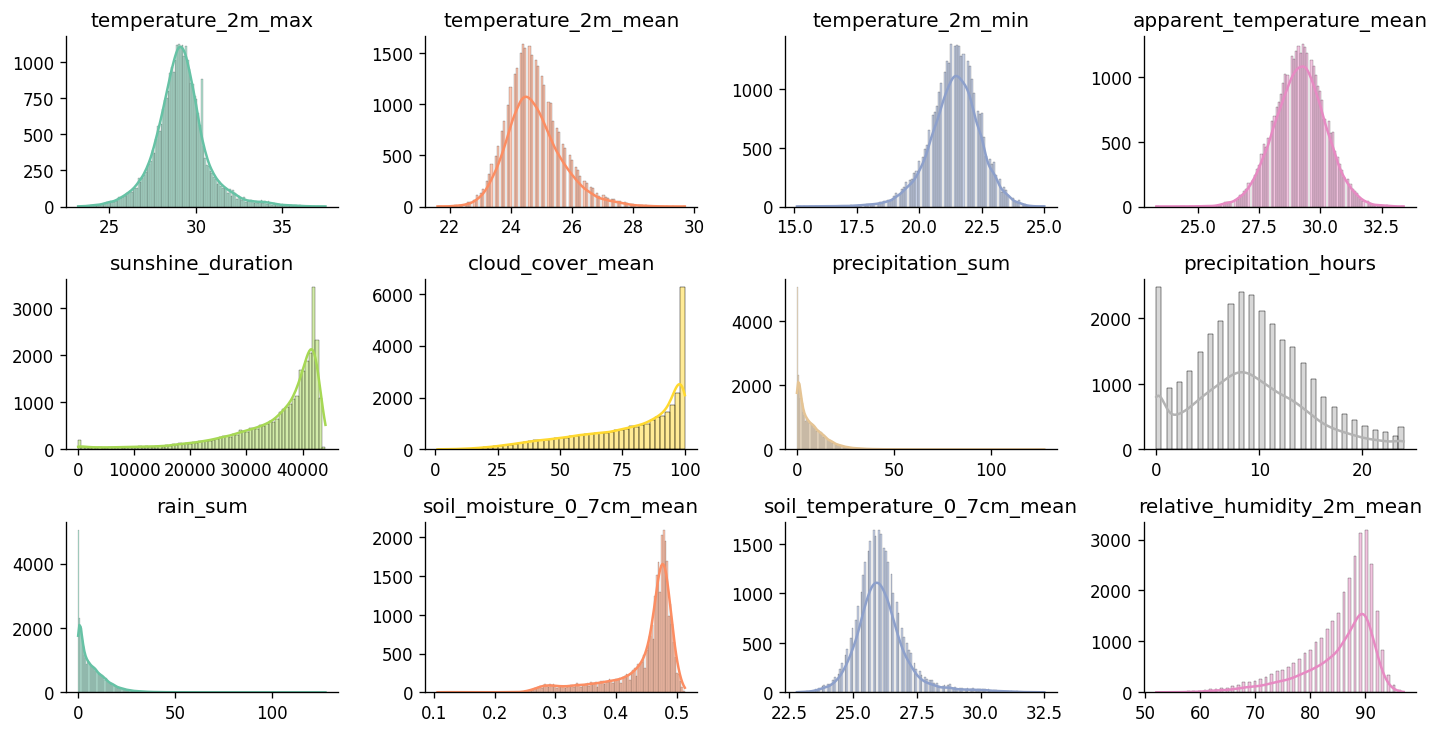

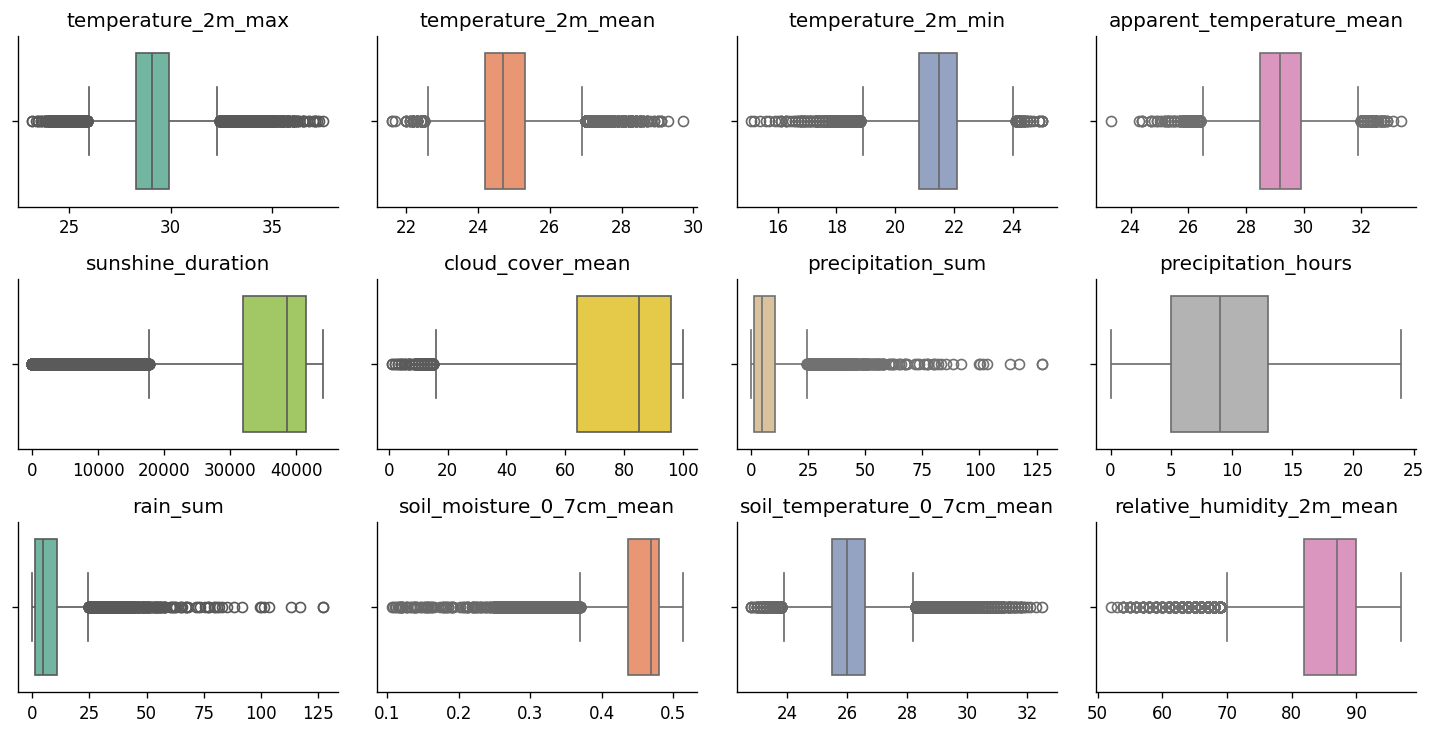

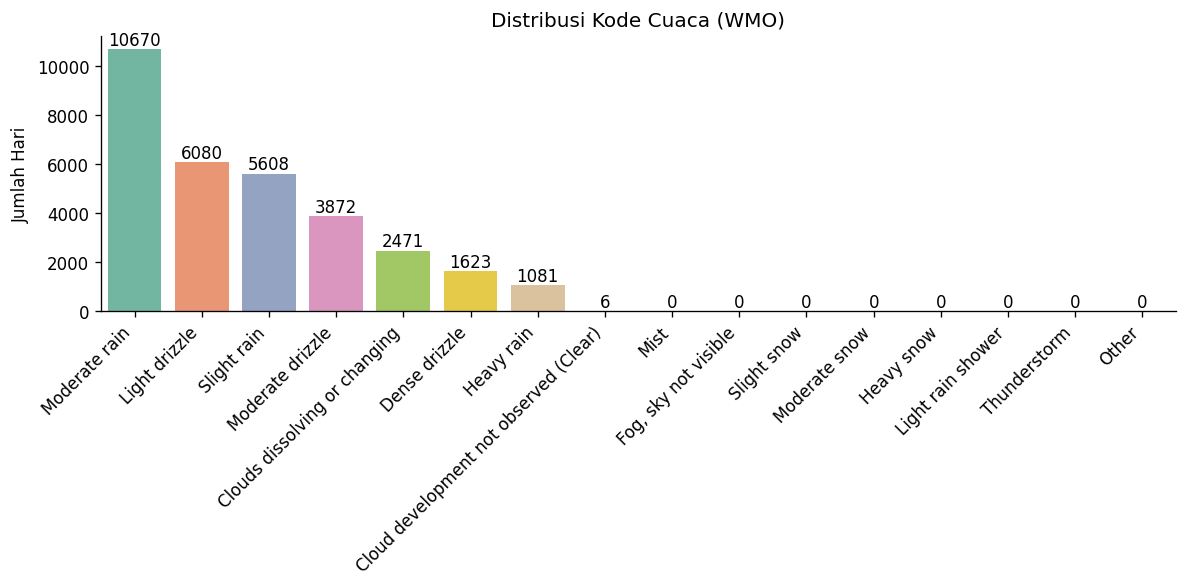

In [8]:
# Distribusi semua variable numerik
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col].dropna(), kde=True, color=PALETTE[i % len(PALETTE)])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Box plot untuk deteksi outlier
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col], color=PALETTE[i % len(PALETTE)])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Distribusi weather code (add count label)
plt.figure(figsize=(10, 5))
sns.countplot(x=COL_WEATHER_CODE, data=df, order=df[COL_WEATHER_CODE].value_counts().index, palette=PALETTE)
for i, v in enumerate(df[COL_WEATHER_CODE].value_counts().values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')
plt.xticks(rotation=45, ha='right')
plt.title('Distribusi Kode Cuaca (WMO)')
plt.xlabel('')
plt.ylabel('Jumlah Hari')
plt.tight_layout()
plt.show()


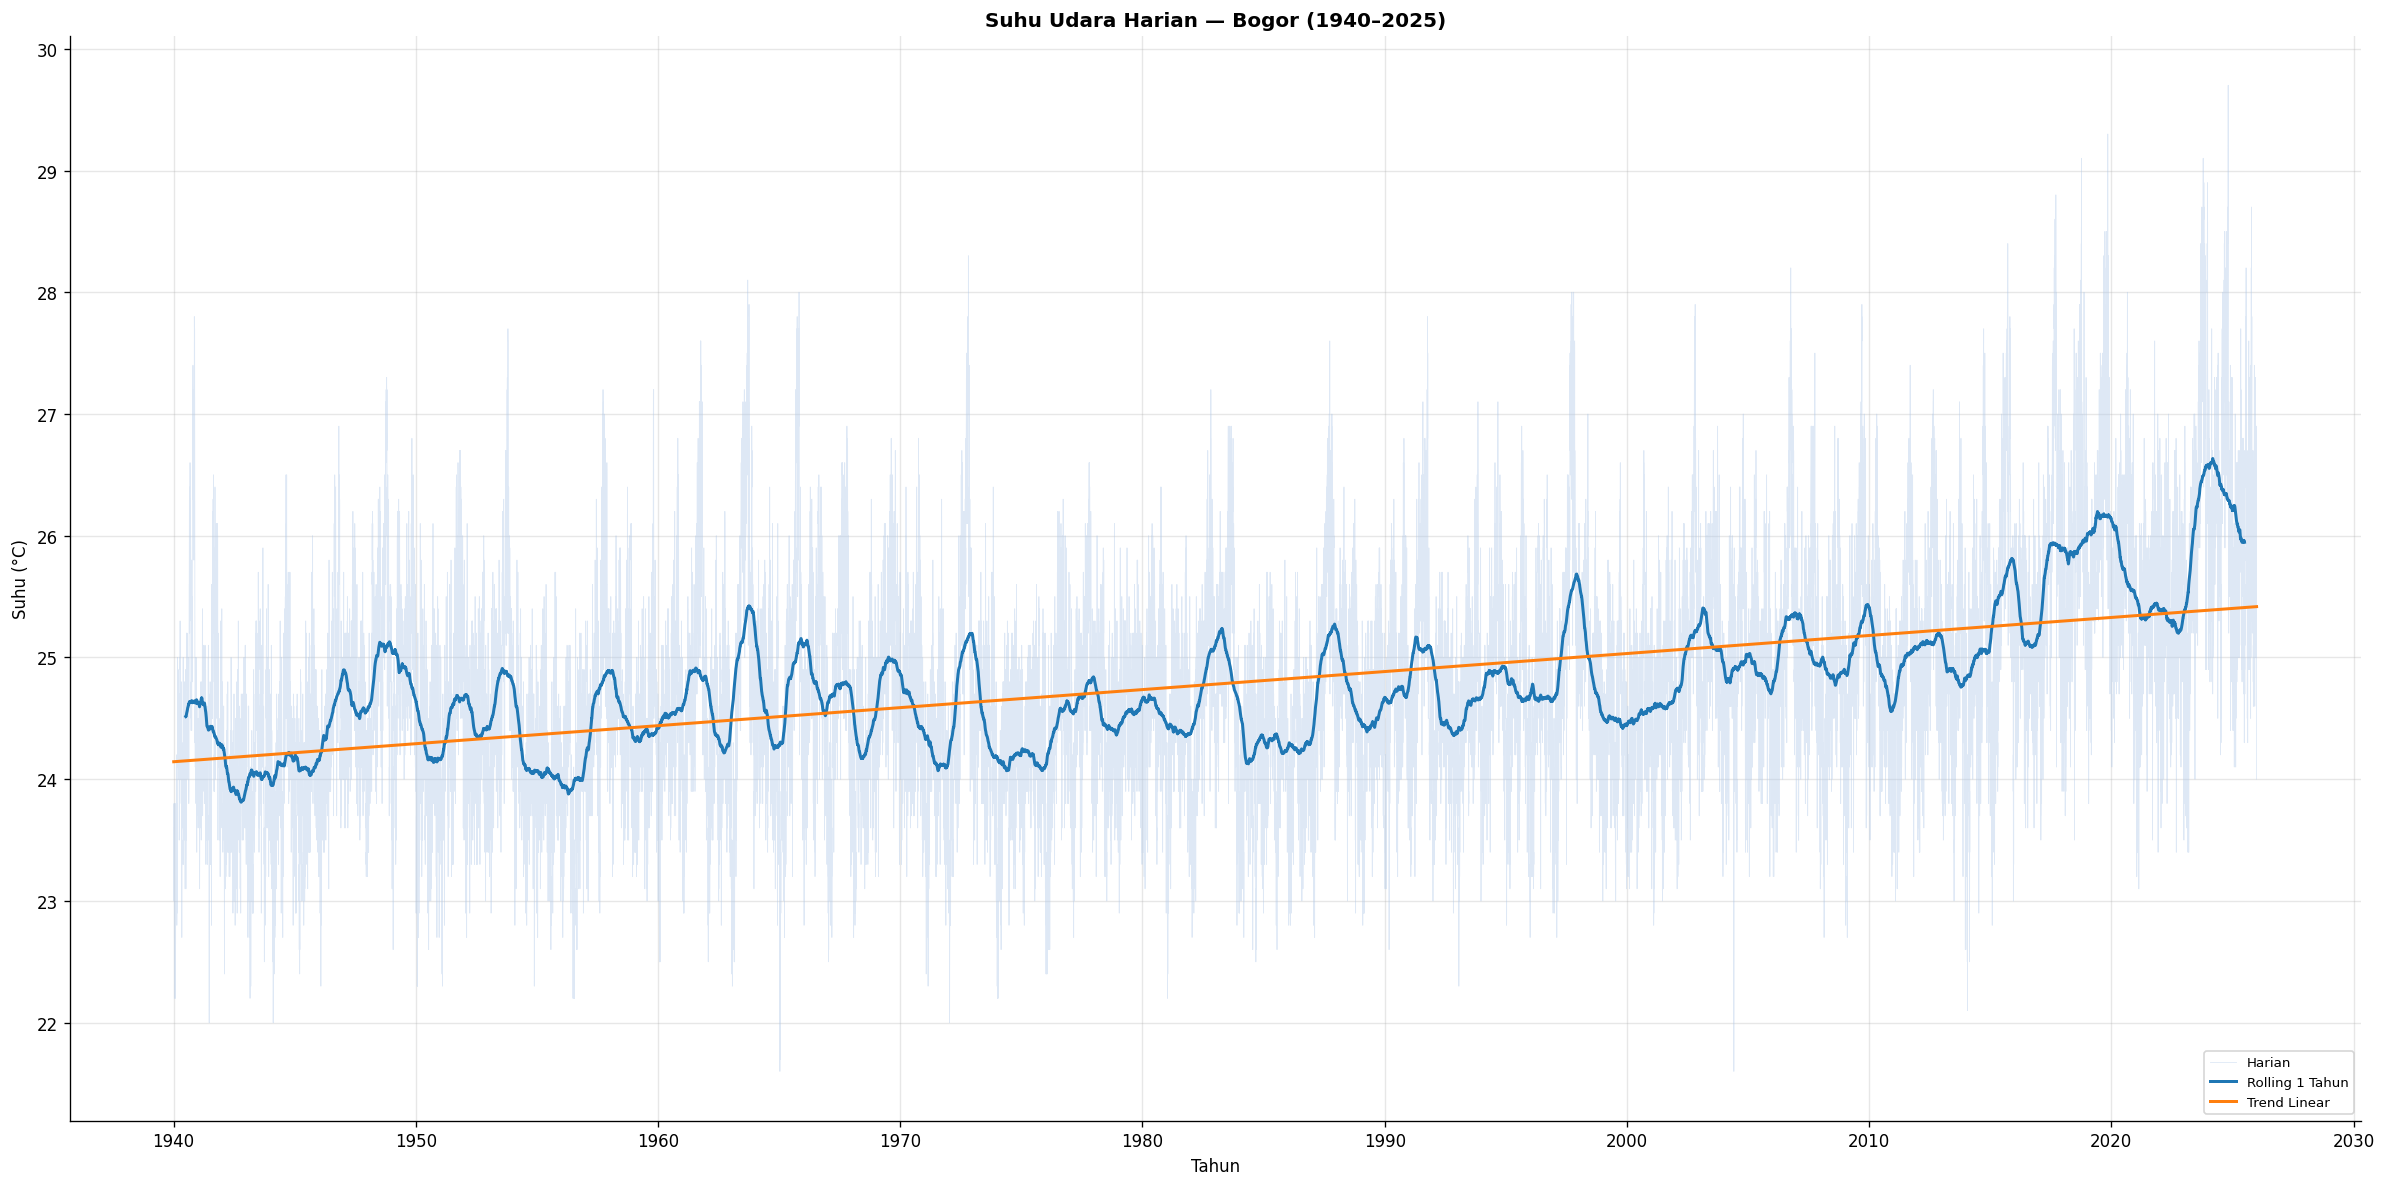

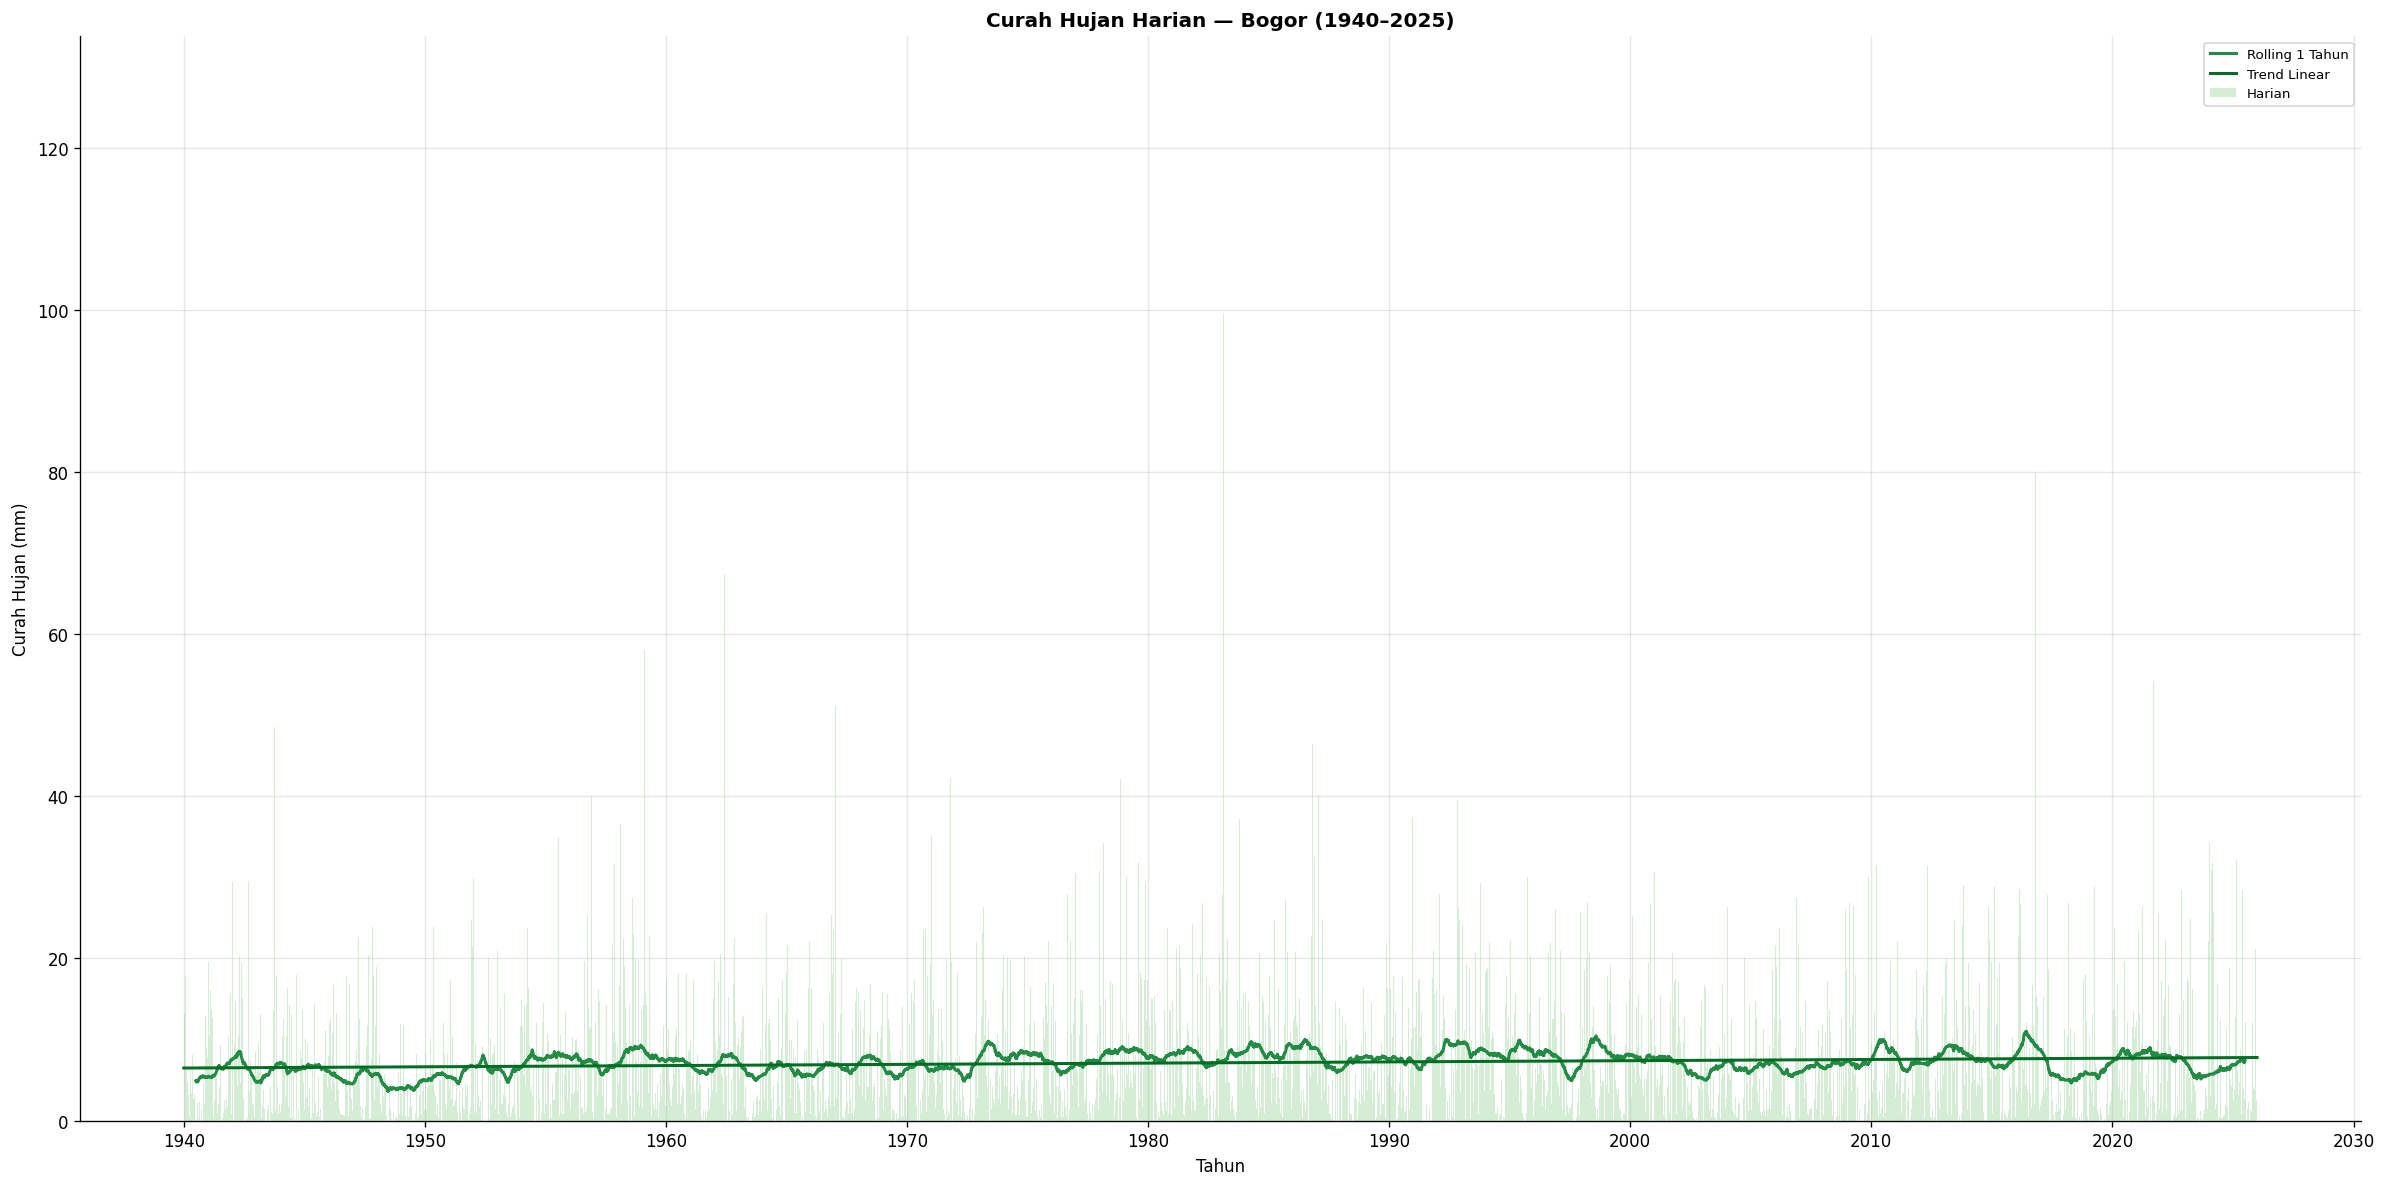

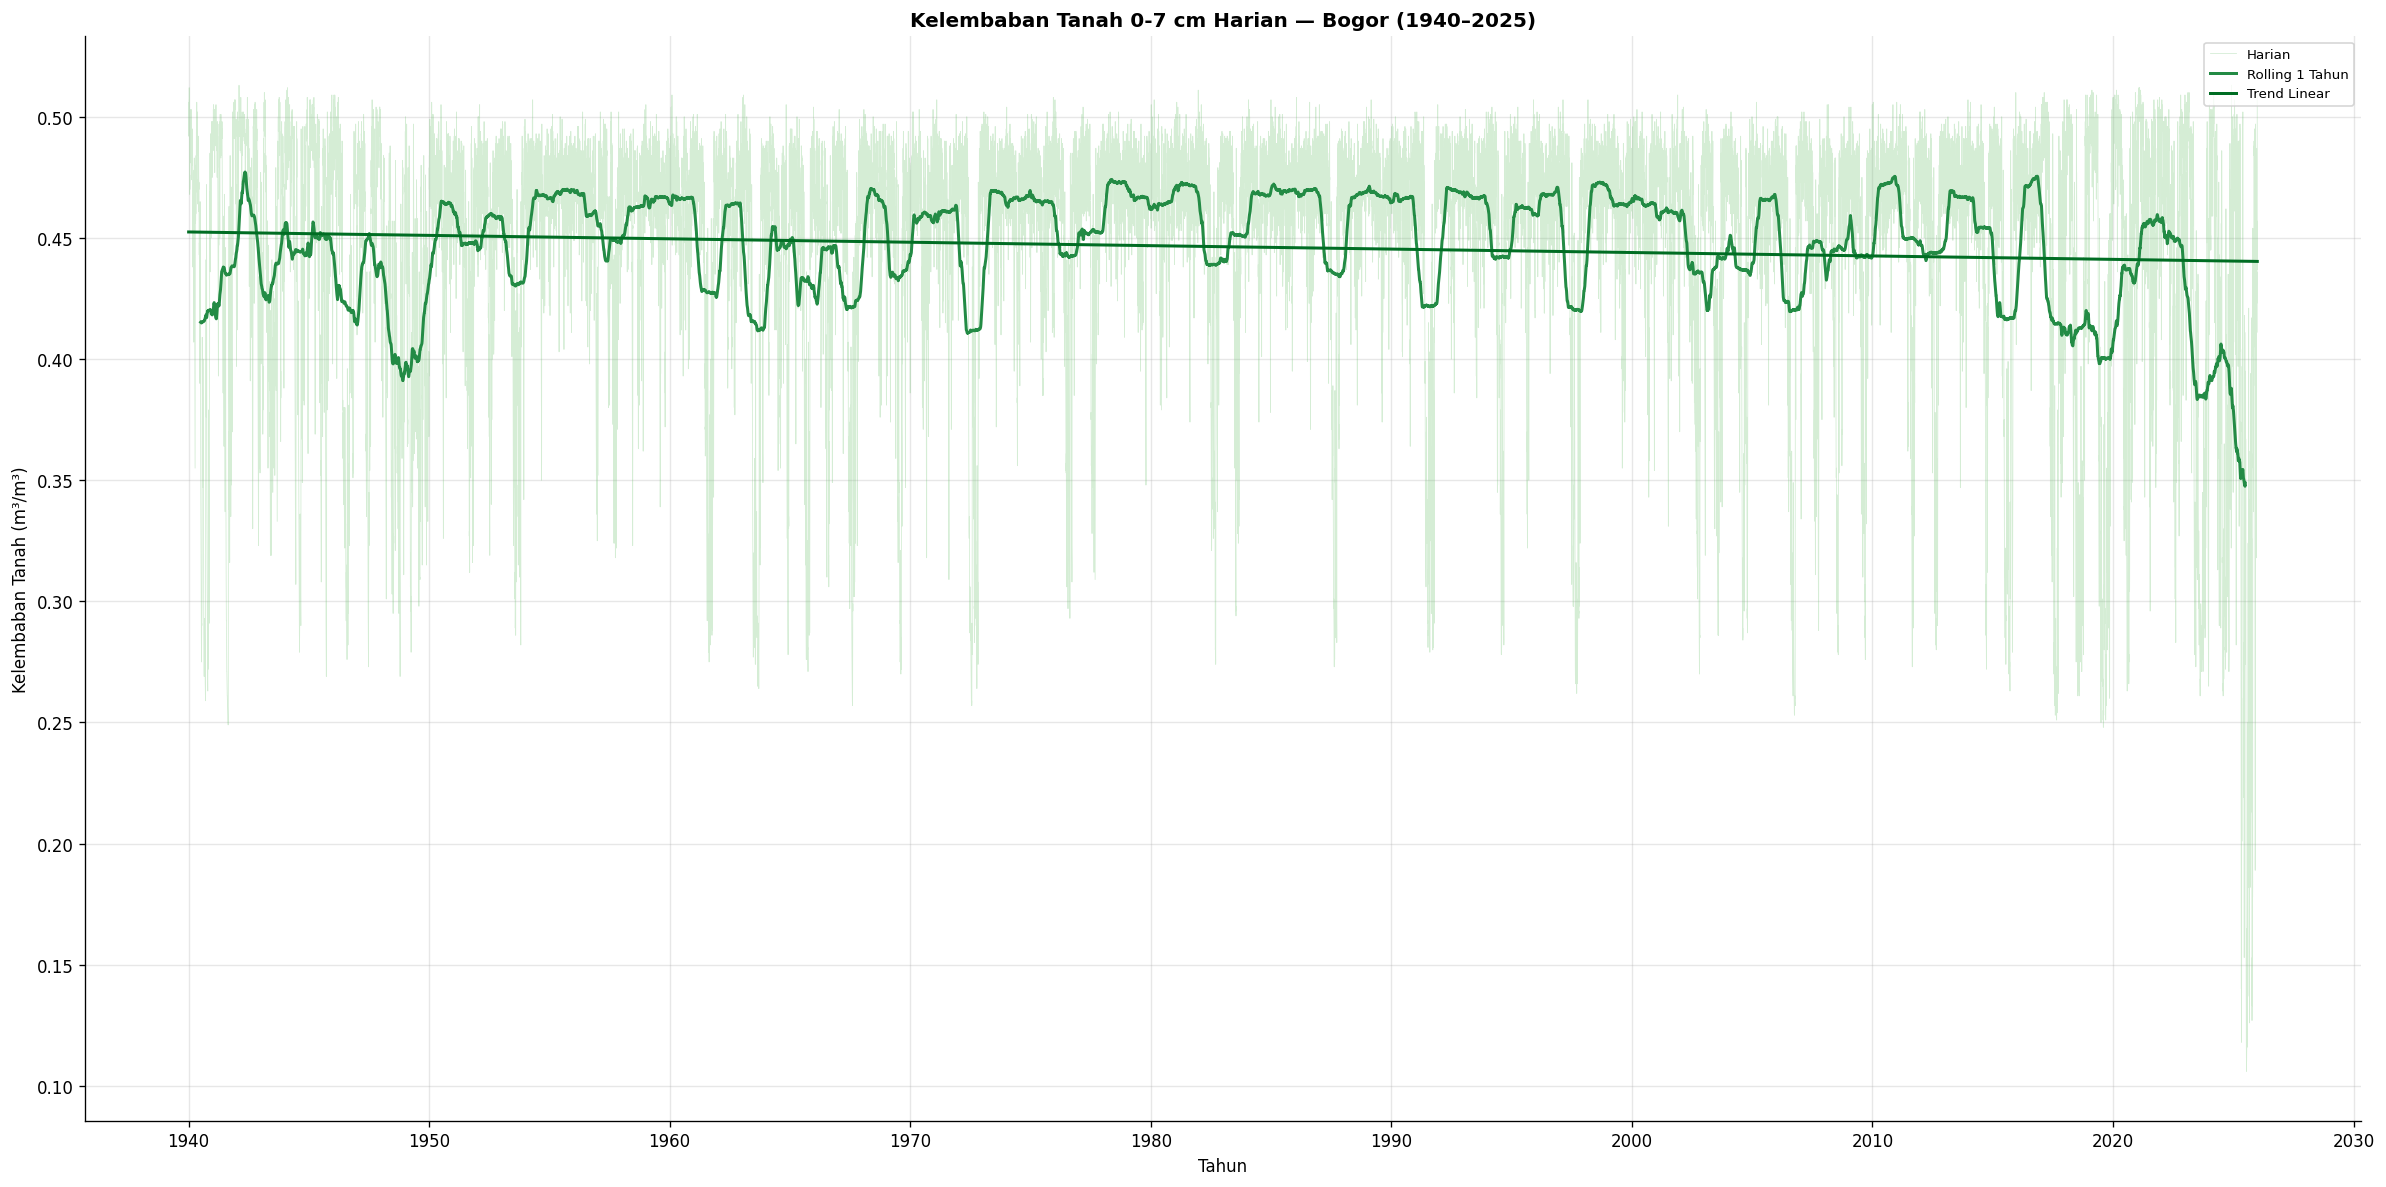

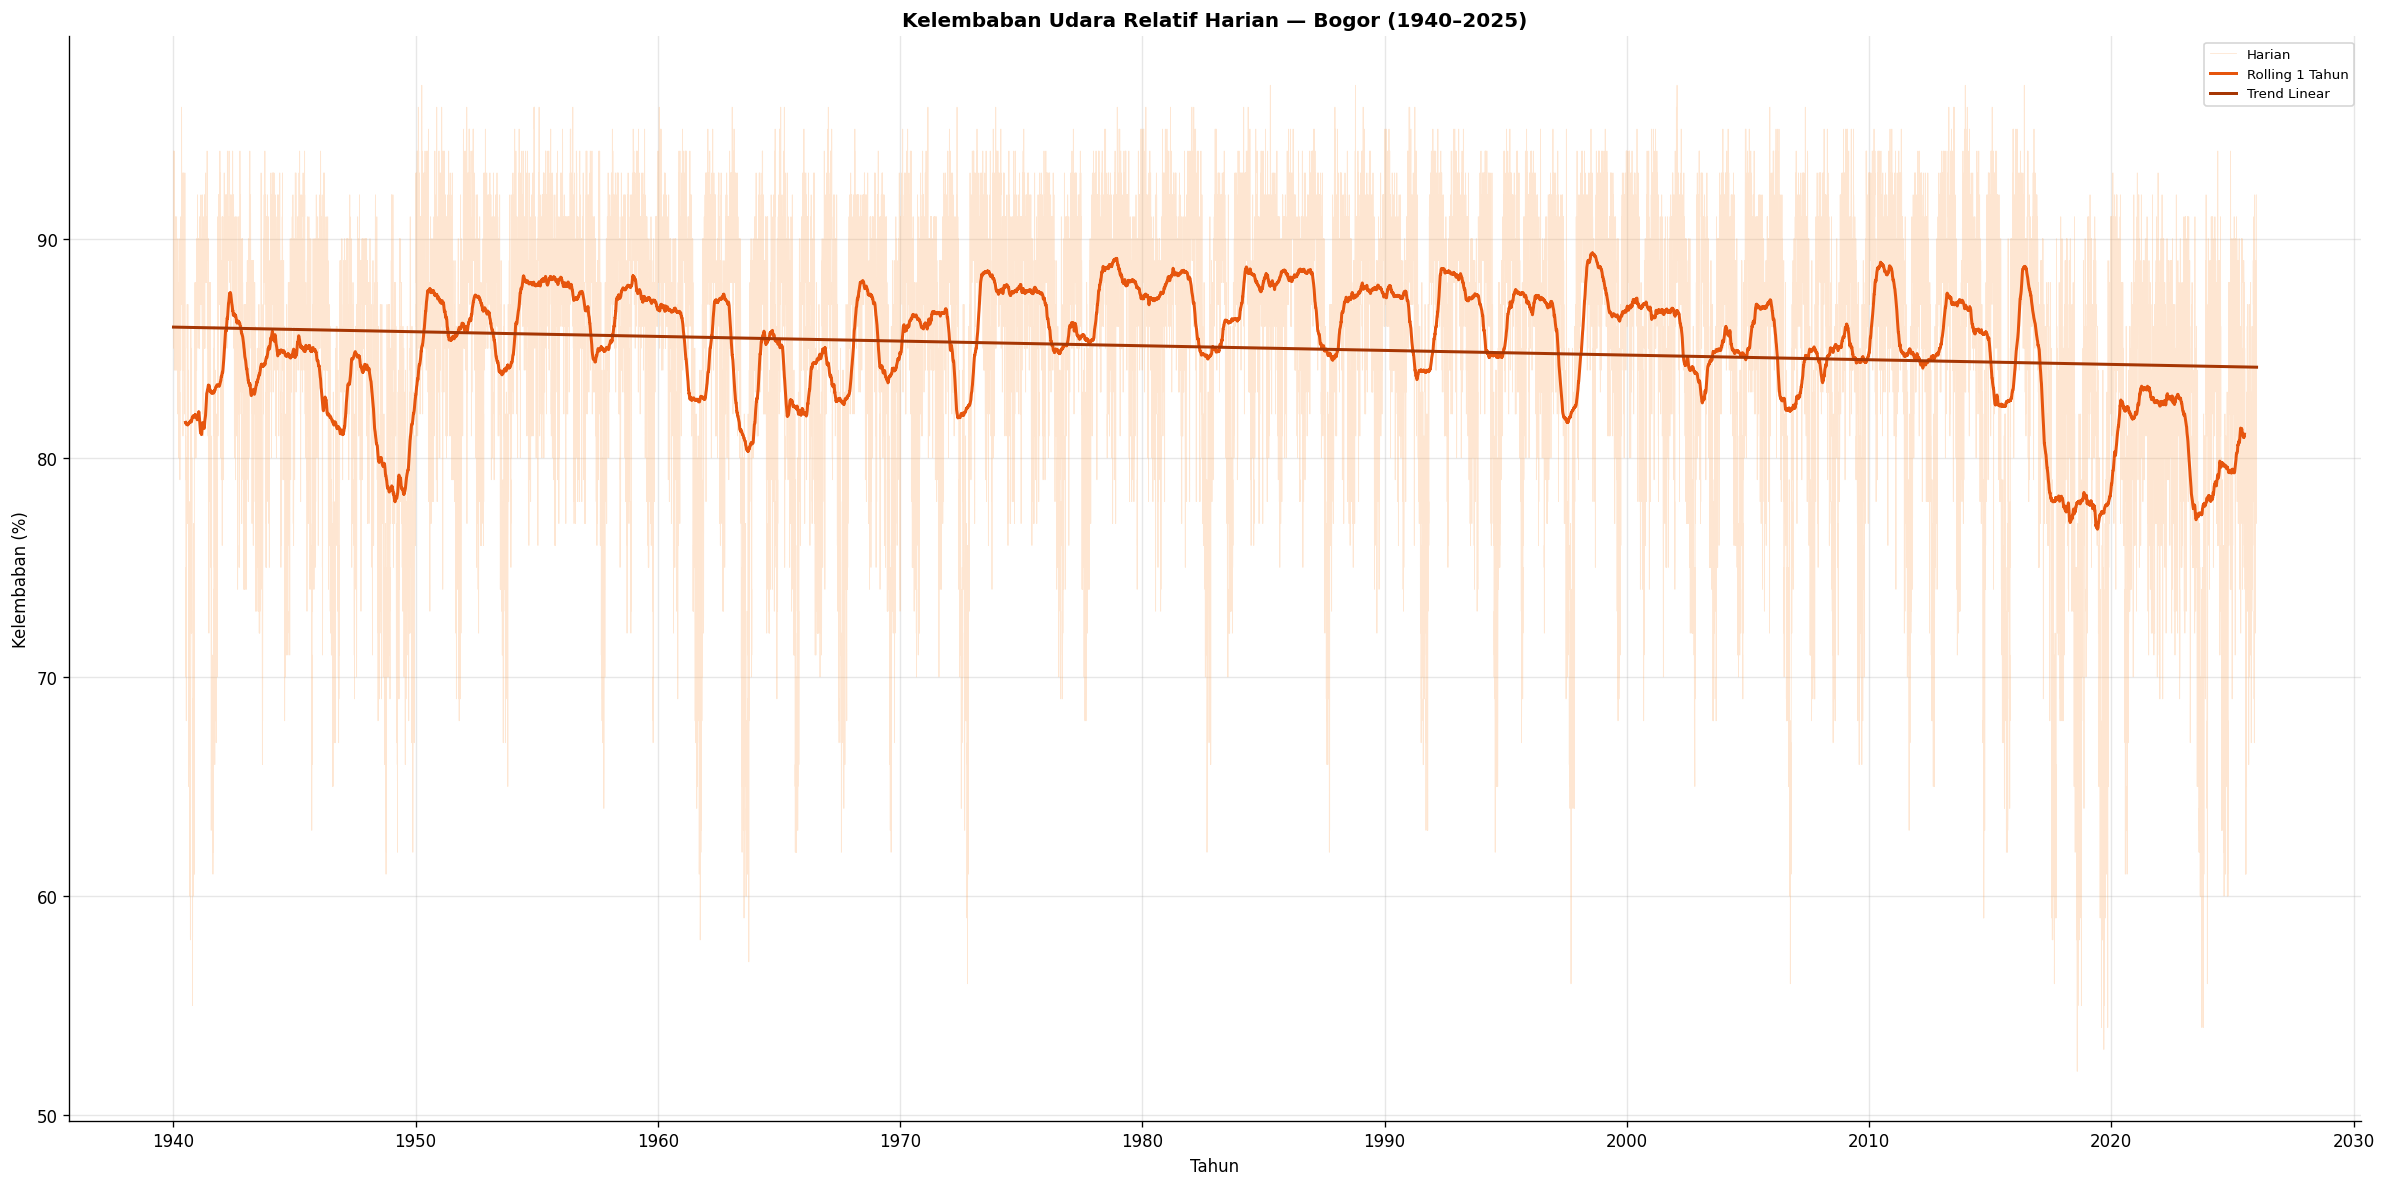

In [9]:
# Suhu harian + rolling 365 hari + line trend
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(df.index, df[COL_TEMP_2M_MEAN], color='#aec7e8', alpha=0.4, lw=0.5, label='Harian')
ax.plot(df[COL_TEMP_2M_MEAN].rolling(365, center=True).mean(),
        color='#1f77b4', lw=1.8, label='Rolling 1 Tahun')
z = np.polyfit(mdates.date2num(df.index), df[COL_TEMP_2M_MEAN], 1)
p = np.poly1d(z)
ax.plot(df.index, p(mdates.date2num(df.index)), color='#ff7f0e', lw=1.8, label='Trend Linear')
ax.set_ylabel('Suhu (°C)', fontsize=10)
ax.set_xlabel('Tahun', fontsize=10)
ax.set_title('Suhu Udara Harian — Bogor (1940–2025)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Curah hujan harian + rolling 365 hari
fig, ax = plt.subplots(figsize=(20, 10))
ax.bar(df.index, df[COL_PRECIPITATION_SUM], color='#74c476', alpha=0.3, width=1, label='Harian')
ax.plot(df[COL_PRECIPITATION_SUM].rolling(365, center=True).mean(),
        color='#238b45', lw=1.8, label='Rolling 1 Tahun')
z = np.polyfit(mdates.date2num(df.index), df[COL_PRECIPITATION_SUM], 1)
p = np.poly1d(z)
ax.plot(df.index, p(mdates.date2num(df.index)), color='#006d23', lw=1.8, label='Trend Linear')
ax.set_ylabel('Curah Hujan (mm)', fontsize=10)
ax.set_xlabel('Tahun', fontsize=10)
ax.set_title('Curah Hujan Harian — Bogor (1940–2025)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Kelembaban tanah 0-7 cm harian + rolling 365 hari
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(df.index, df[COL_SOIL_MOIST_0_7CM_MEAN], color='#74c476', alpha=0.3, lw=0.5, label='Harian')
ax.plot(df[COL_SOIL_MOIST_0_7CM_MEAN].rolling(365, center=True).mean(),
        color='#238b45', lw=1.8, label='Rolling 1 Tahun')
z = np.polyfit(mdates.date2num(df.index), df[COL_SOIL_MOIST_0_7CM_MEAN], 1)
p = np.poly1d(z)
ax.plot(df.index, p(mdates.date2num(df.index)), color='#006d23', lw=1.8, label='Trend Linear')
ax.set_ylabel('Kelembaban Tanah (m³/m³)', fontsize=10)
ax.set_xlabel('Tahun', fontsize=10)
ax.set_title('Kelembaban Tanah 0-7 cm Harian — Bogor (1940–2025)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Kelembaban udara
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(df.index, df[COL_RELATIVE_HUMIDITY_2M_MEAN], color='#fdae6b', alpha=0.3, lw=0.5, label='Harian')
ax.plot(df[COL_RELATIVE_HUMIDITY_2M_MEAN].rolling(365, center=True).mean(),
        color='#e6550d', lw=1.8, label='Rolling 1 Tahun')
z = np.polyfit(mdates.date2num(df.index), df[COL_RELATIVE_HUMIDITY_2M_MEAN], 1)
p = np.poly1d(z)
ax.plot(df.index, p(mdates.date2num(df.index)), color='#a63603', lw=1.8, label='Trend Linear')
ax.set_ylabel('Kelembaban (%)', fontsize=10)
ax.set_xlabel('Tahun', fontsize=10)
ax.set_title('Kelembaban Udara Relatif Harian — Bogor (1940–2025)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Decomposisi Time Series (Trend, Seasonal, Residual)

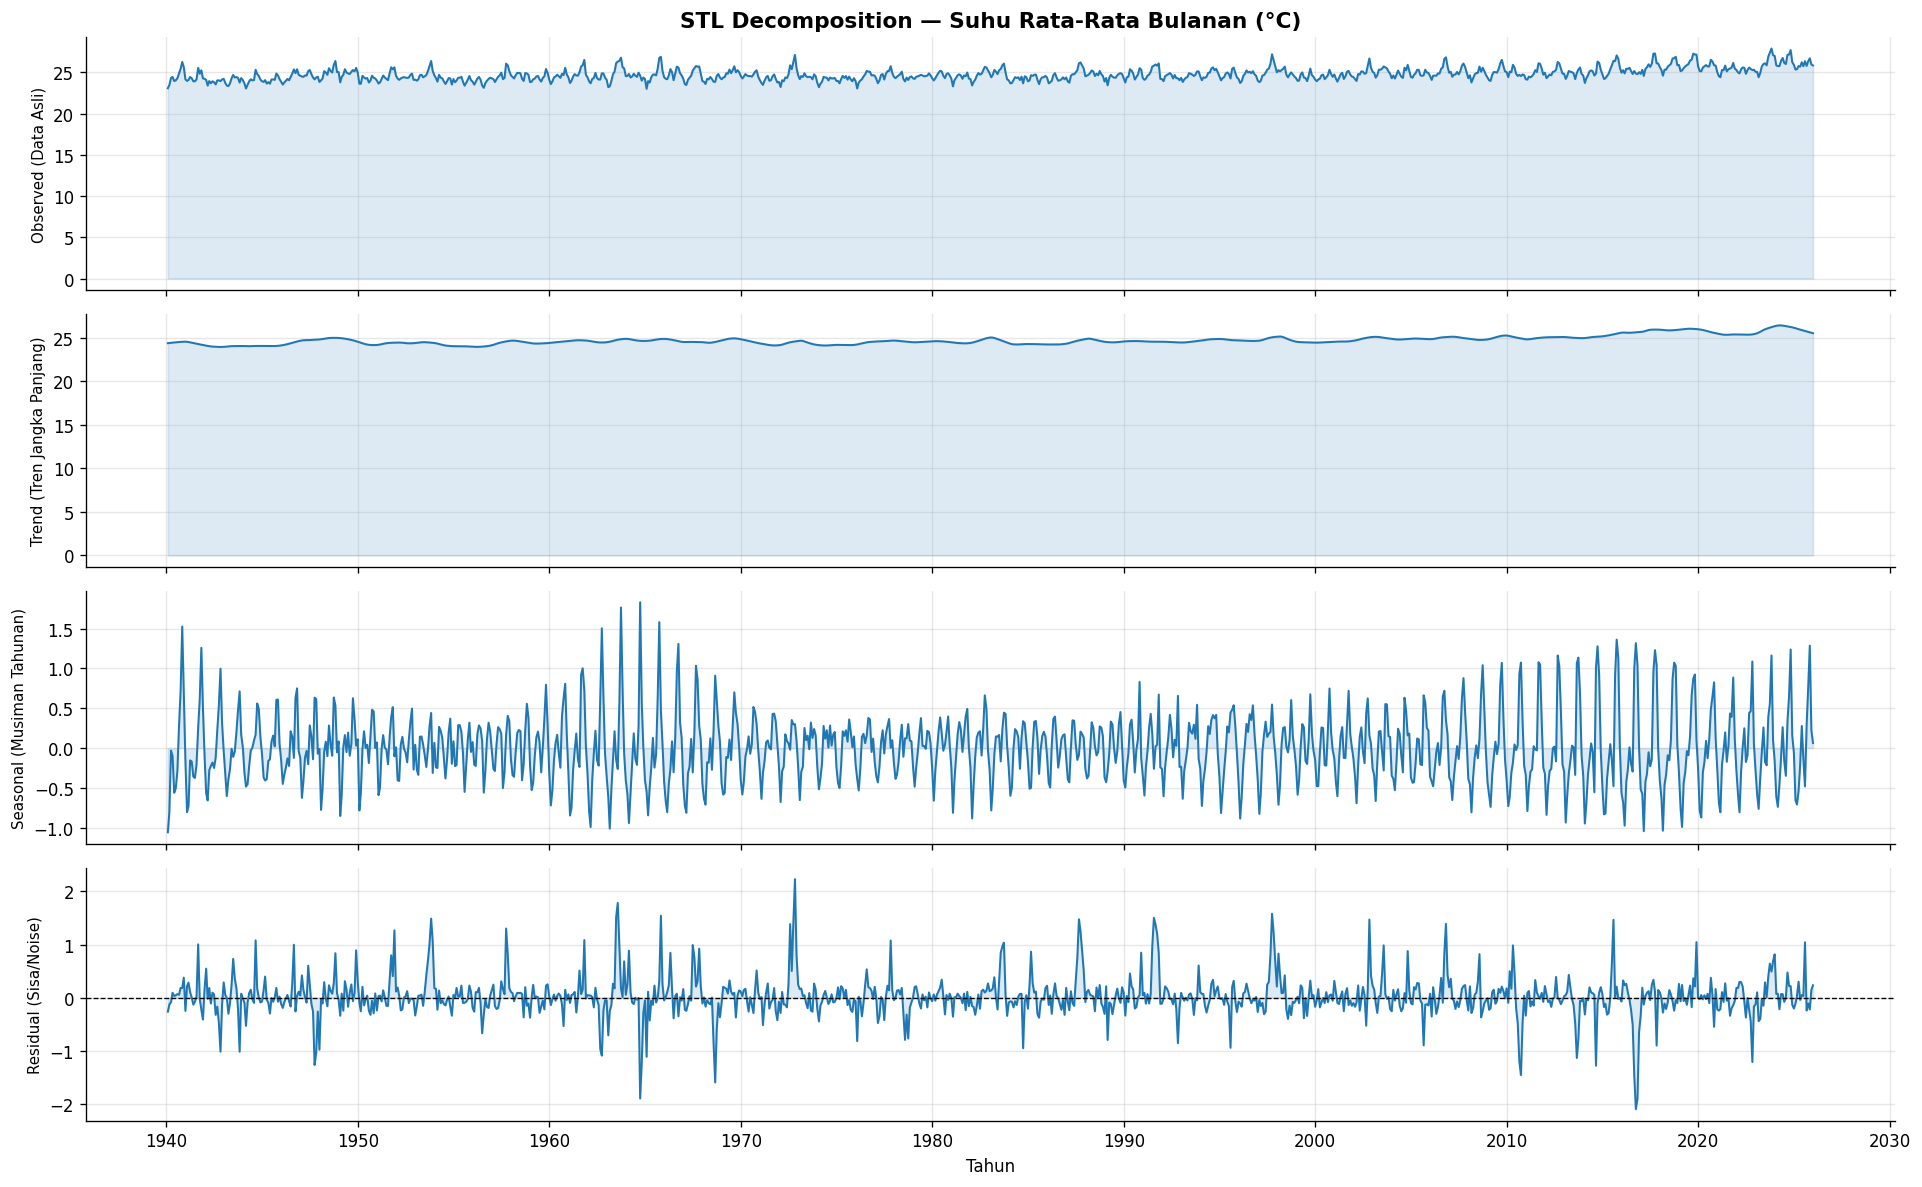

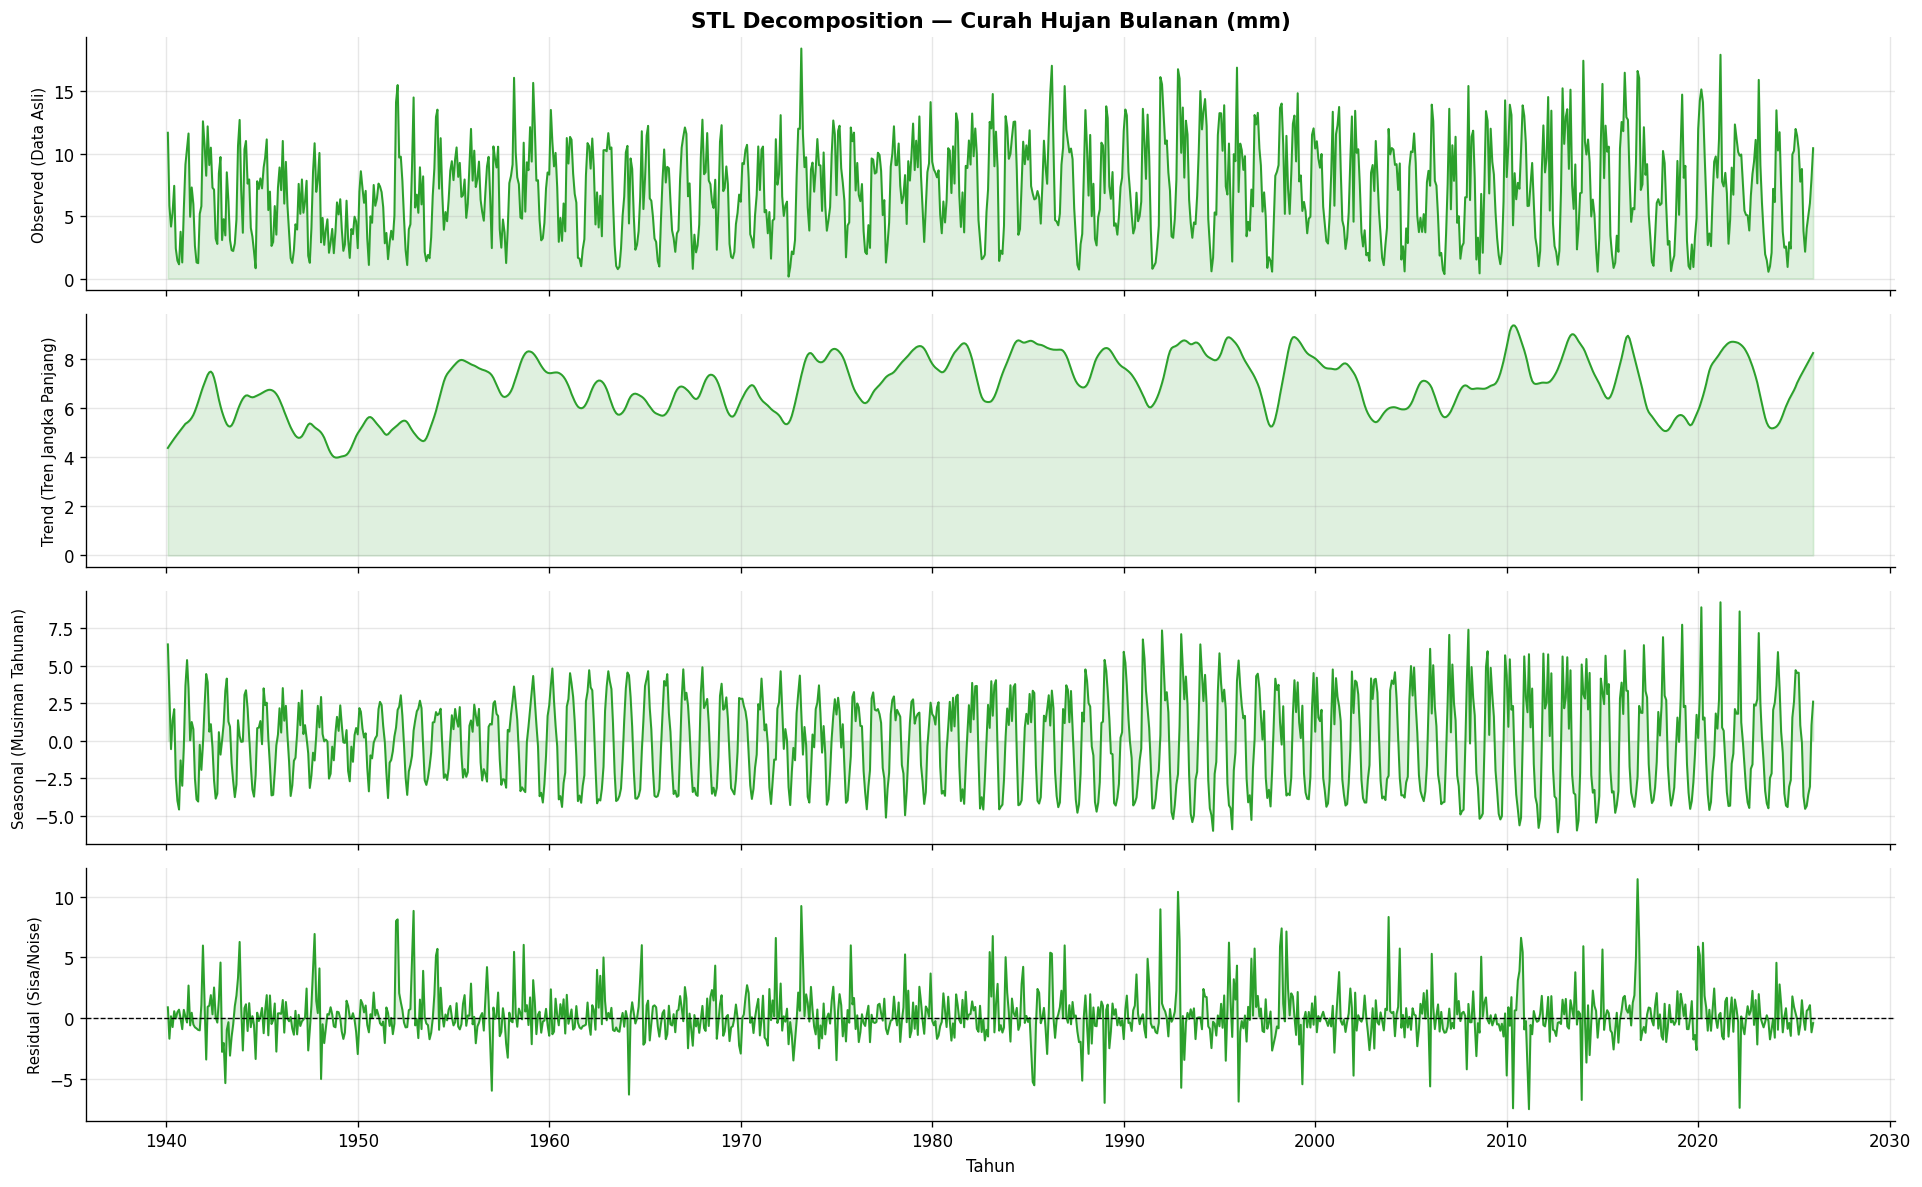

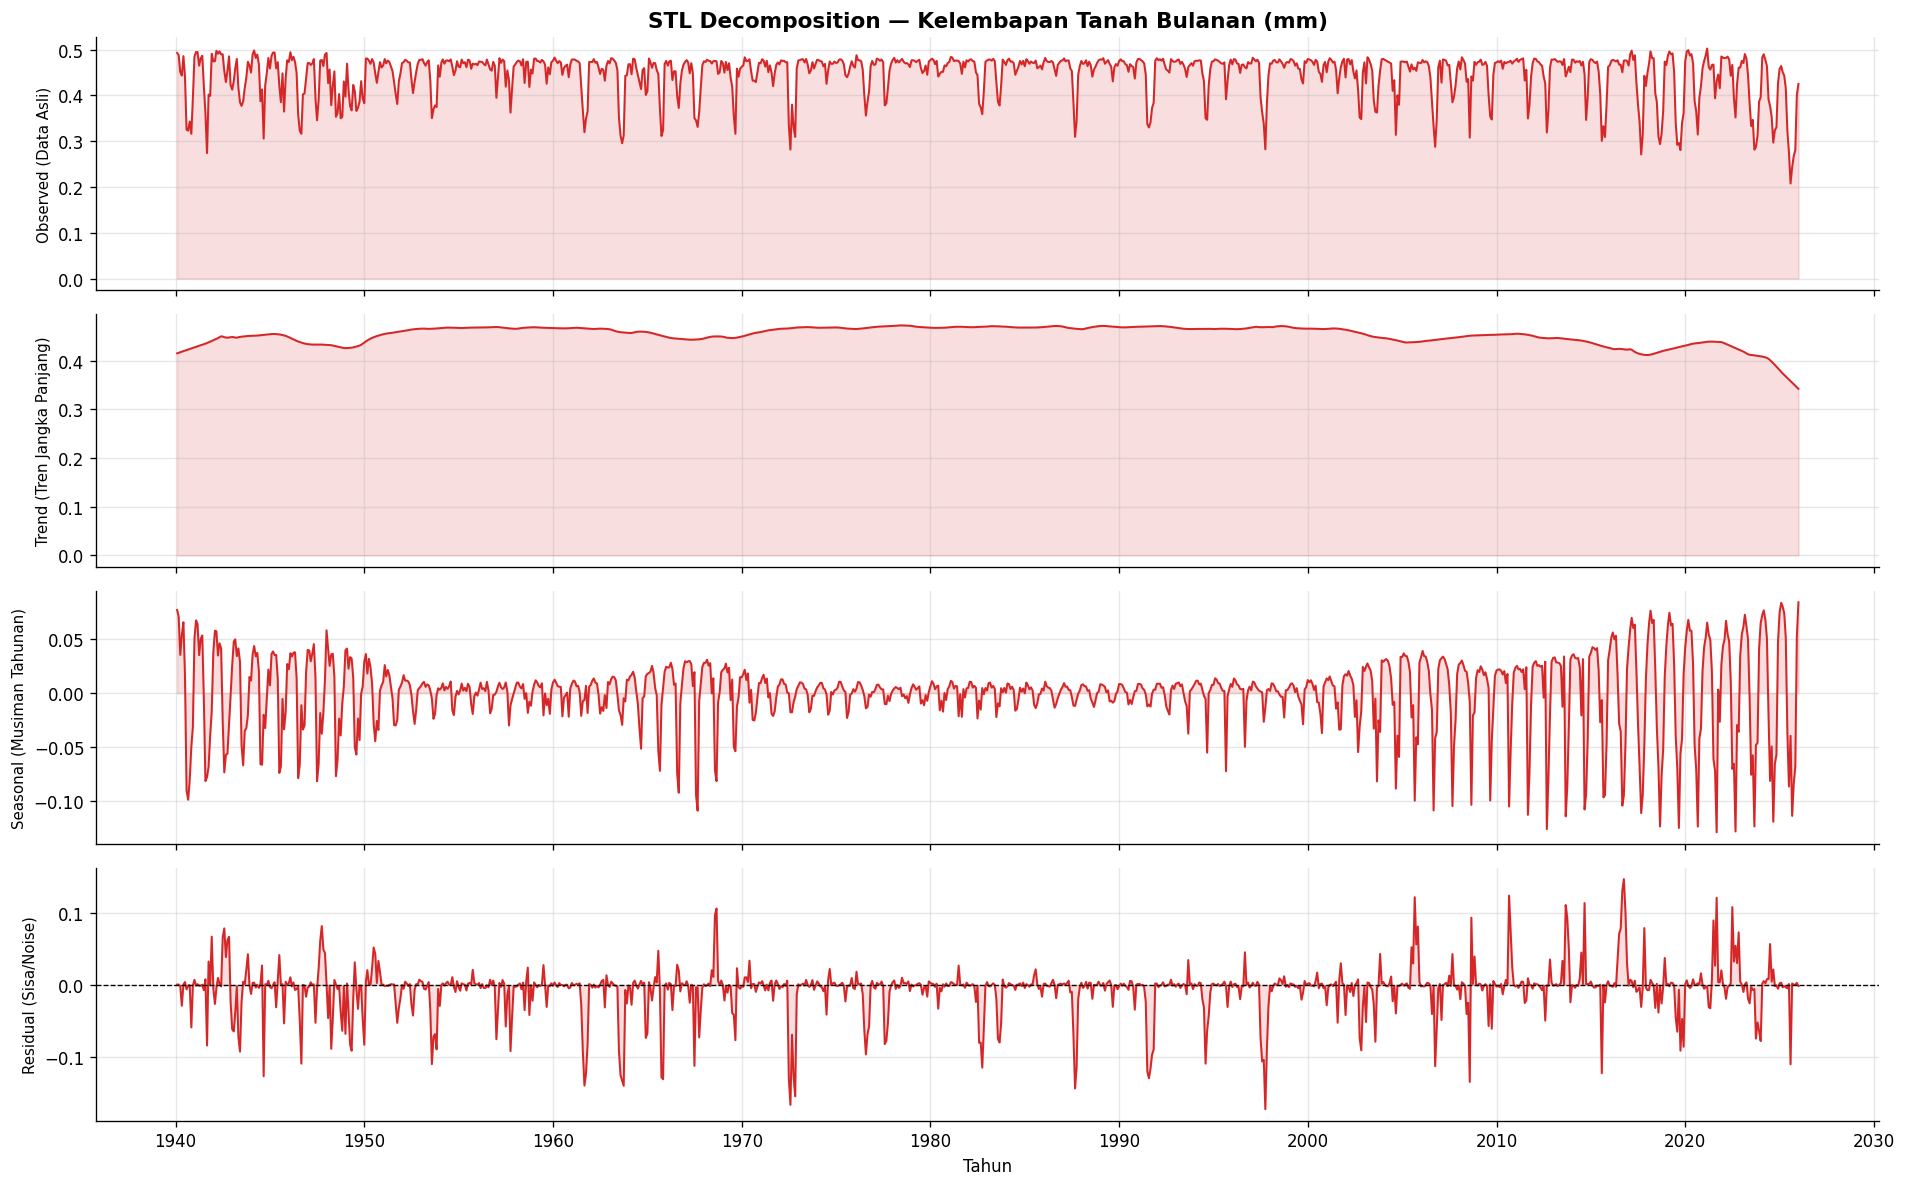

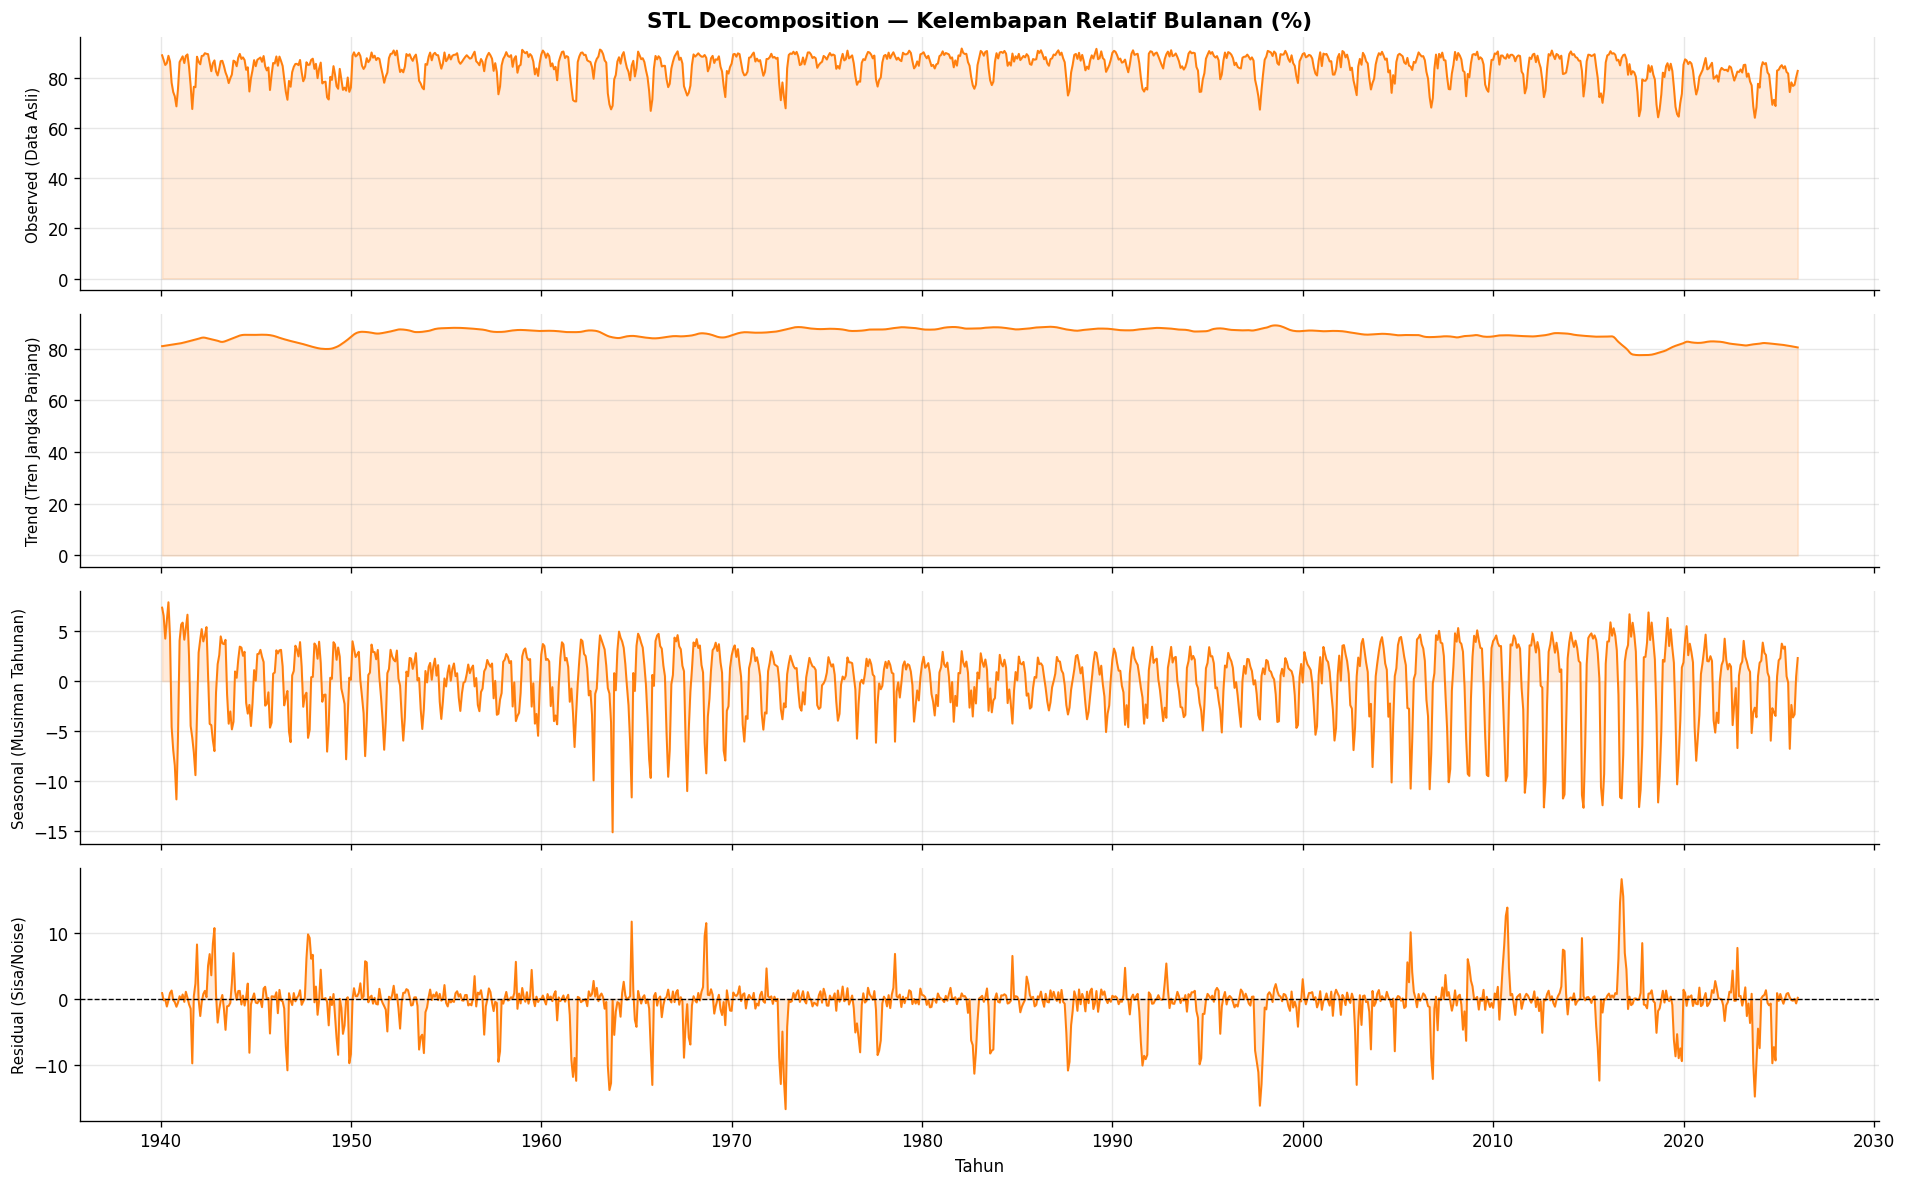

In [10]:
# Monthly data
df_monthly = df[[COL_TEMP_2M_MEAN, COL_PRECIPITATION_SUM, COL_SOIL_MOIST_0_7CM_MEAN,
                 COL_RELATIVE_HUMIDITY_2M_MEAN]].resample('ME').mean()

temp_series = df_monthly[COL_TEMP_2M_MEAN]
rain_series = df_monthly[COL_PRECIPITATION_SUM]
soil_series = df_monthly[COL_SOIL_MOIST_0_7CM_MEAN]
humidity_series = df_monthly[COL_RELATIVE_HUMIDITY_2M_MEAN]

# STL Decomposition
stl_temp = STL(temp_series, period=12, robust=True).fit()
stl_rain = STL(rain_series, period=12, robust=True).fit()
stl_soil = STL(soil_series, period=12, robust=True).fit()
stl_humidity = STL(humidity_series, period=12, robust=True).fit()

def plot_stl(stl_result, title, color, ylabel):
    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    components = [
        ('Observed (Data Asli)', stl_result.observed),
        ('Trend (Tren Jangka Panjang)', stl_result.trend),
        ('Seasonal (Musiman Tahunan)', stl_result.seasonal),
        ('Residual (Sisa/Noise)', stl_result.resid),
    ]
    for ax, (label, series) in zip(axes, components):
        ax.plot(series, color=color, lw=1.2)
        ax.fill_between(series.index, series, alpha=0.15, color=color)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(alpha=0.3)
        if 'Residual' in label:
            ax.axhline(0, color='black', lw=0.8, linestyle='--')
    axes[0].set_title(f'STL Decomposition — {title}', fontsize=13, fontweight='bold')
    axes[-1].set_xlabel('Tahun', fontsize=10)
    plt.tight_layout()
    return fig

fig_temp = plot_stl(stl_temp, 'Suhu Rata-Rata Bulanan (°C)', '#1f77b4', 'Suhu (°C)')
plt.show()

fig_rain = plot_stl(stl_rain, 'Curah Hujan Bulanan (mm)', '#2ca02c', 'Curah Hujan (mm)')
plt.show()

fig_soil = plot_stl(stl_soil, 'Kelembapan Tanah Bulanan (mm)', '#d62728', 'Kelembapan Tanah (mm)')
plt.show()

fig_humidity = plot_stl(stl_humidity, 'Kelembapan Relatif Bulanan (%)', '#ff7f0e', 'Kelembapan Relatif (%)')
plt.show()

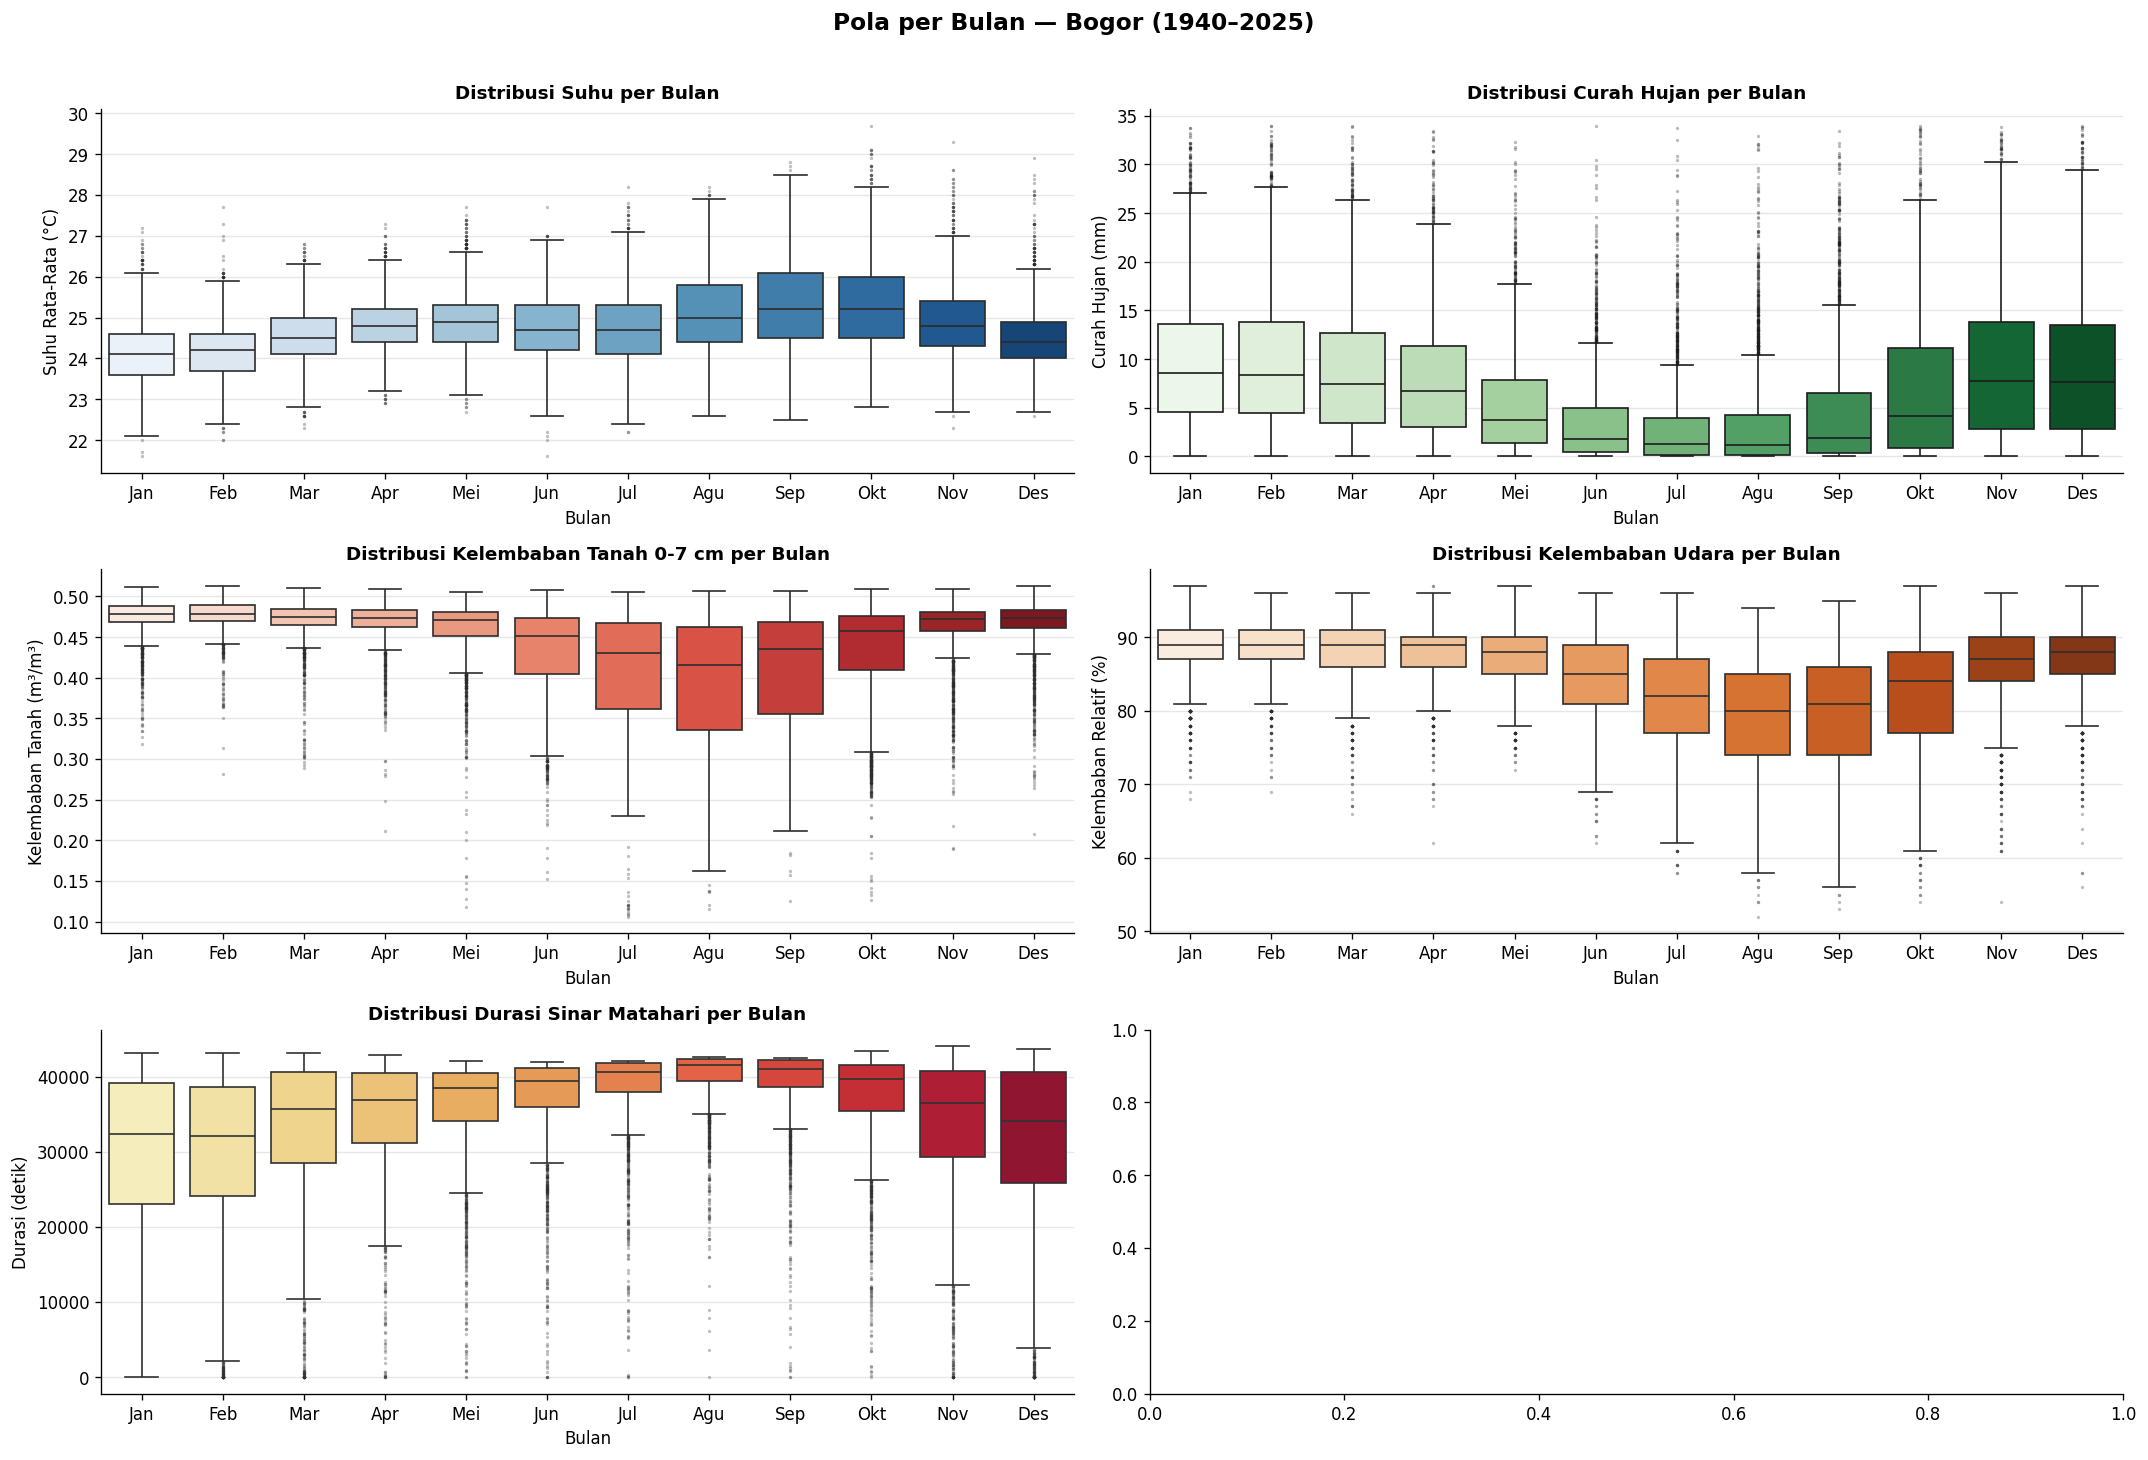

In [11]:
# Boxplot bulanan untuk melihat pola musiman
MONTH_LABELS = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

df['month'] = df.index.month
df['year']  = df.index.year
df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'

fig, axes = plt.subplots(3, 2, figsize=(18, 12))

# Suhu
ax = axes[0, 0]
sns.boxplot(data=df, x='month', y=COL_TEMP_2M_MEAN, ax=ax,
            palette='Blues', flierprops={'markersize': 1, 'alpha': 0.3})
ax.set_xticklabels(MONTH_LABELS)
ax.set_title('Distribusi Suhu per Bulan', fontsize=11, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Suhu Rata-Rata (°C)')
ax.grid(alpha=0.3, axis='y')

# Curah Hujan and remove outlier
df_no_outliers = df[df[COL_PRECIPITATION_SUM] < df[COL_PRECIPITATION_SUM].quantile(0.99)]
ax = axes[0, 1]
sns.boxplot(data=df_no_outliers, x='month', y=COL_PRECIPITATION_SUM, ax=ax,
            palette='Greens', flierprops={'markersize': 1, 'alpha': 0.3})
ax.set_xticklabels(MONTH_LABELS)
ax.set_title('Distribusi Curah Hujan per Bulan', fontsize=11, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Curah Hujan (mm)')
ax.grid(alpha=0.3, axis='y')

# Kelembaban tanah
ax = axes[1, 0]
sns.boxplot(data=df, x='month', y=COL_SOIL_MOIST_0_7CM_MEAN, ax=ax,
            palette='Reds', flierprops={'markersize': 1, 'alpha': 0.3})
ax.set_xticklabels(MONTH_LABELS)
ax.set_title('Distribusi Kelembaban Tanah 0-7 cm per Bulan', fontsize=11, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Kelembaban Tanah (m³/m³)')
ax.grid(alpha=0.3, axis='y')

# Kelembaban udara
ax = axes[1, 1]
sns.boxplot(data=df, x='month', y=COL_RELATIVE_HUMIDITY_2M_MEAN, ax=ax,
            palette='Oranges', flierprops={'markersize': 1, 'alpha': 0.3})
ax.set_xticklabels(MONTH_LABELS)
ax.set_title('Distribusi Kelembaban Udara per Bulan', fontsize=11, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Kelembaban Relatif (%)')
ax.grid(alpha=0.3, axis='y')

# Sunshine Duration
ax = axes[2, 0]
sns.boxplot(data=df, x='month', y=COL_SUNSHINE_DURATION, ax=ax,
            palette='YlOrRd', flierprops={'markersize': 1, 'alpha': 0.3})
ax.set_xticklabels(MONTH_LABELS)
ax.set_title('Distribusi Durasi Sinar Matahari per Bulan', fontsize=11, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Durasi (detik)')
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Pola per Bulan — Bogor (1940–2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Pola Musiman:**
- **Musim Hujan (Okt–Apr)**: Curah hujan harian rata-rata >10 mm, kelembaban >85%, suhu sedikit lebih rendah.
- **Musim Kemarau (Mei–Okt)**: Curah hujan <5 mm/hari, sunshine duration lebih panjang. Periode ini hanya cocok untuk padi jika tersedia irigasi atau penanganan air yang baik.

---
## Korelasi Antar Fitur

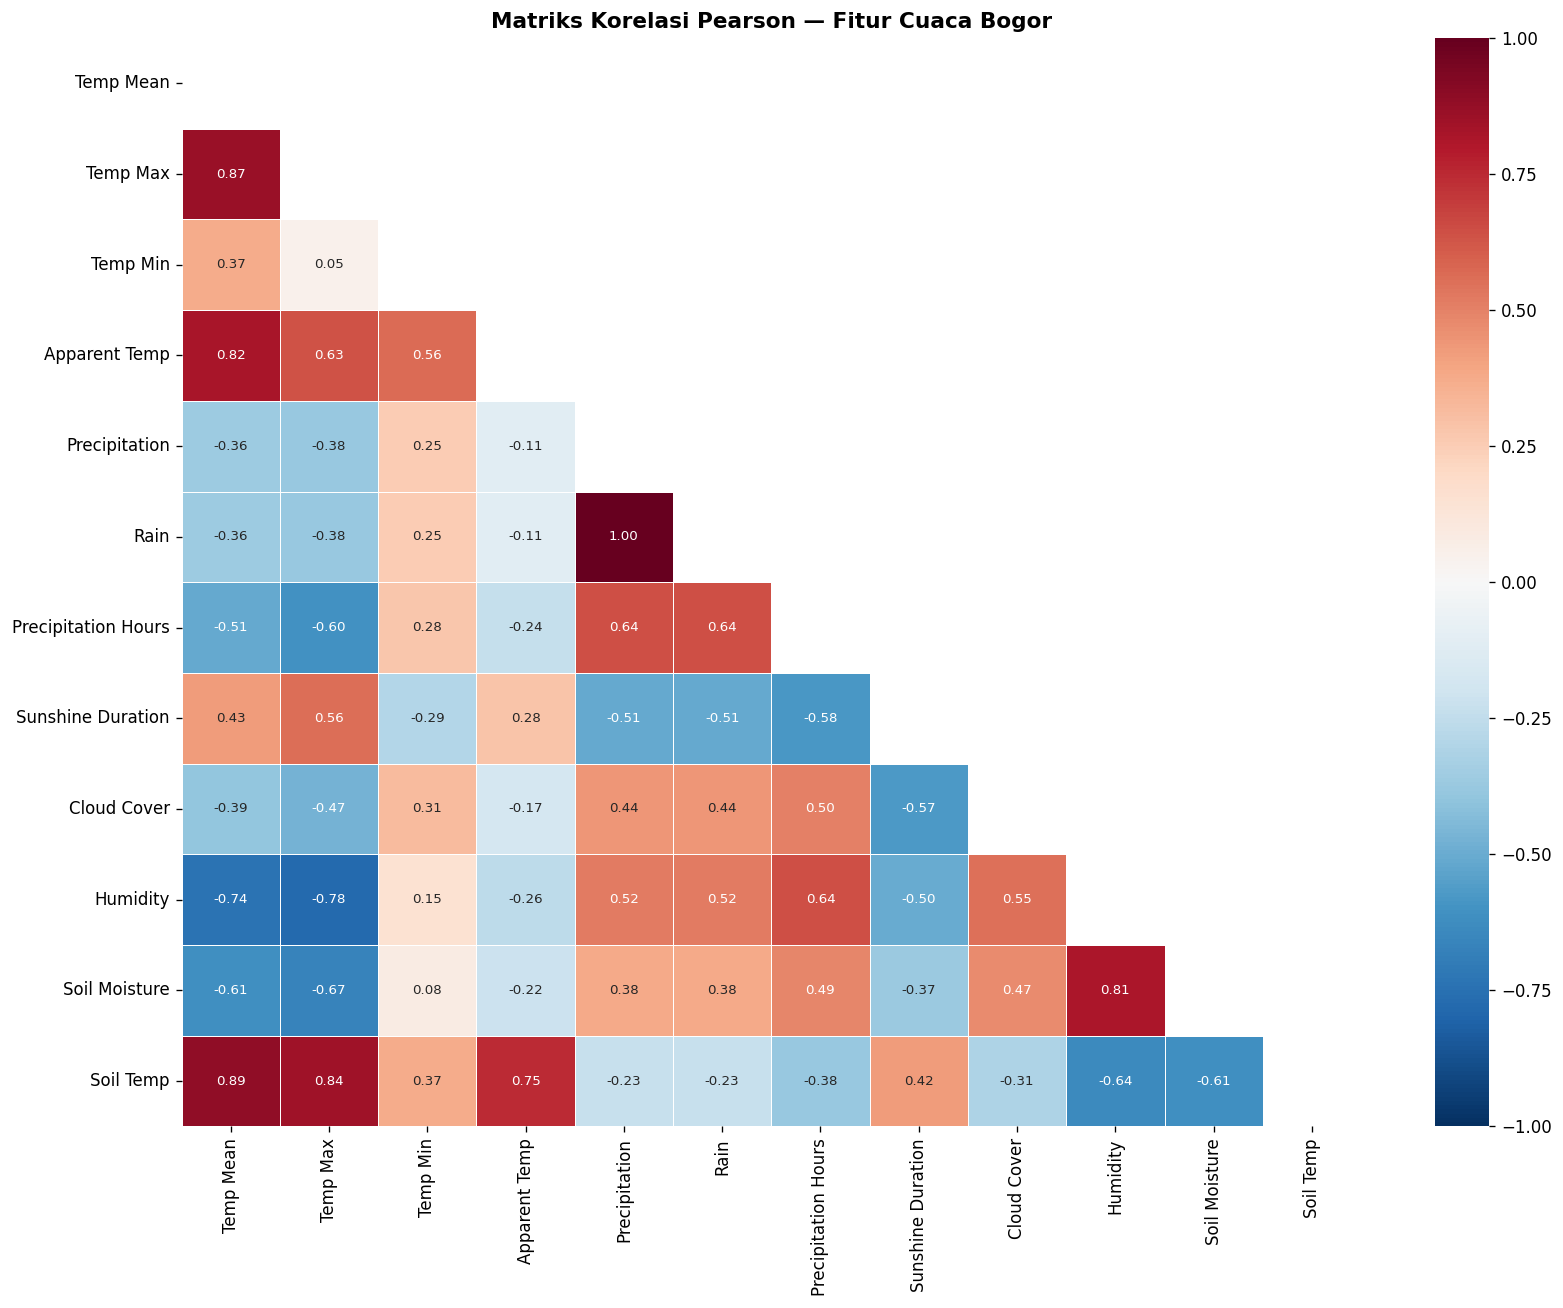

In [12]:
NUMERIC_FEATURES = [
    COL_TEMP_2M_MEAN,
    COL_TEMP_2M_MAX,
    COL_TEMP_2M_MIN,
    COL_APPARENT_TEMP_MEAN,
    COL_PRECIPITATION_SUM,
    COL_RAIN_SUM,
    COL_PRECIPITATION_HOURS_SUM,
    COL_SUNSHINE_DURATION,
    COL_CLOUD_COVER_MEAN,
    COL_RELATIVE_HUMIDITY_2M_MEAN,
    COL_SOIL_MOIST_0_7CM_MEAN,
    COL_SOIL_TEMP_0_7CM_MEAN,]

corr_matrix = df[NUMERIC_FEATURES].corr()

# Rename untuk label lebih pendek
short_names = [
    'Temp Mean', 'Temp Max', 'Temp Min', 'Apparent Temp',
    'Precipitation', 'Rain', 'Precipitation Hours',
    'Sunshine Duration', 'Cloud Cover', 'Humidity',
    'Soil Moisture', 'Soil Temp'
]
corr_matrix.index   = short_names
corr_matrix.columns = short_names

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriks Korelasi Pearson — Fitur Cuaca Bogor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

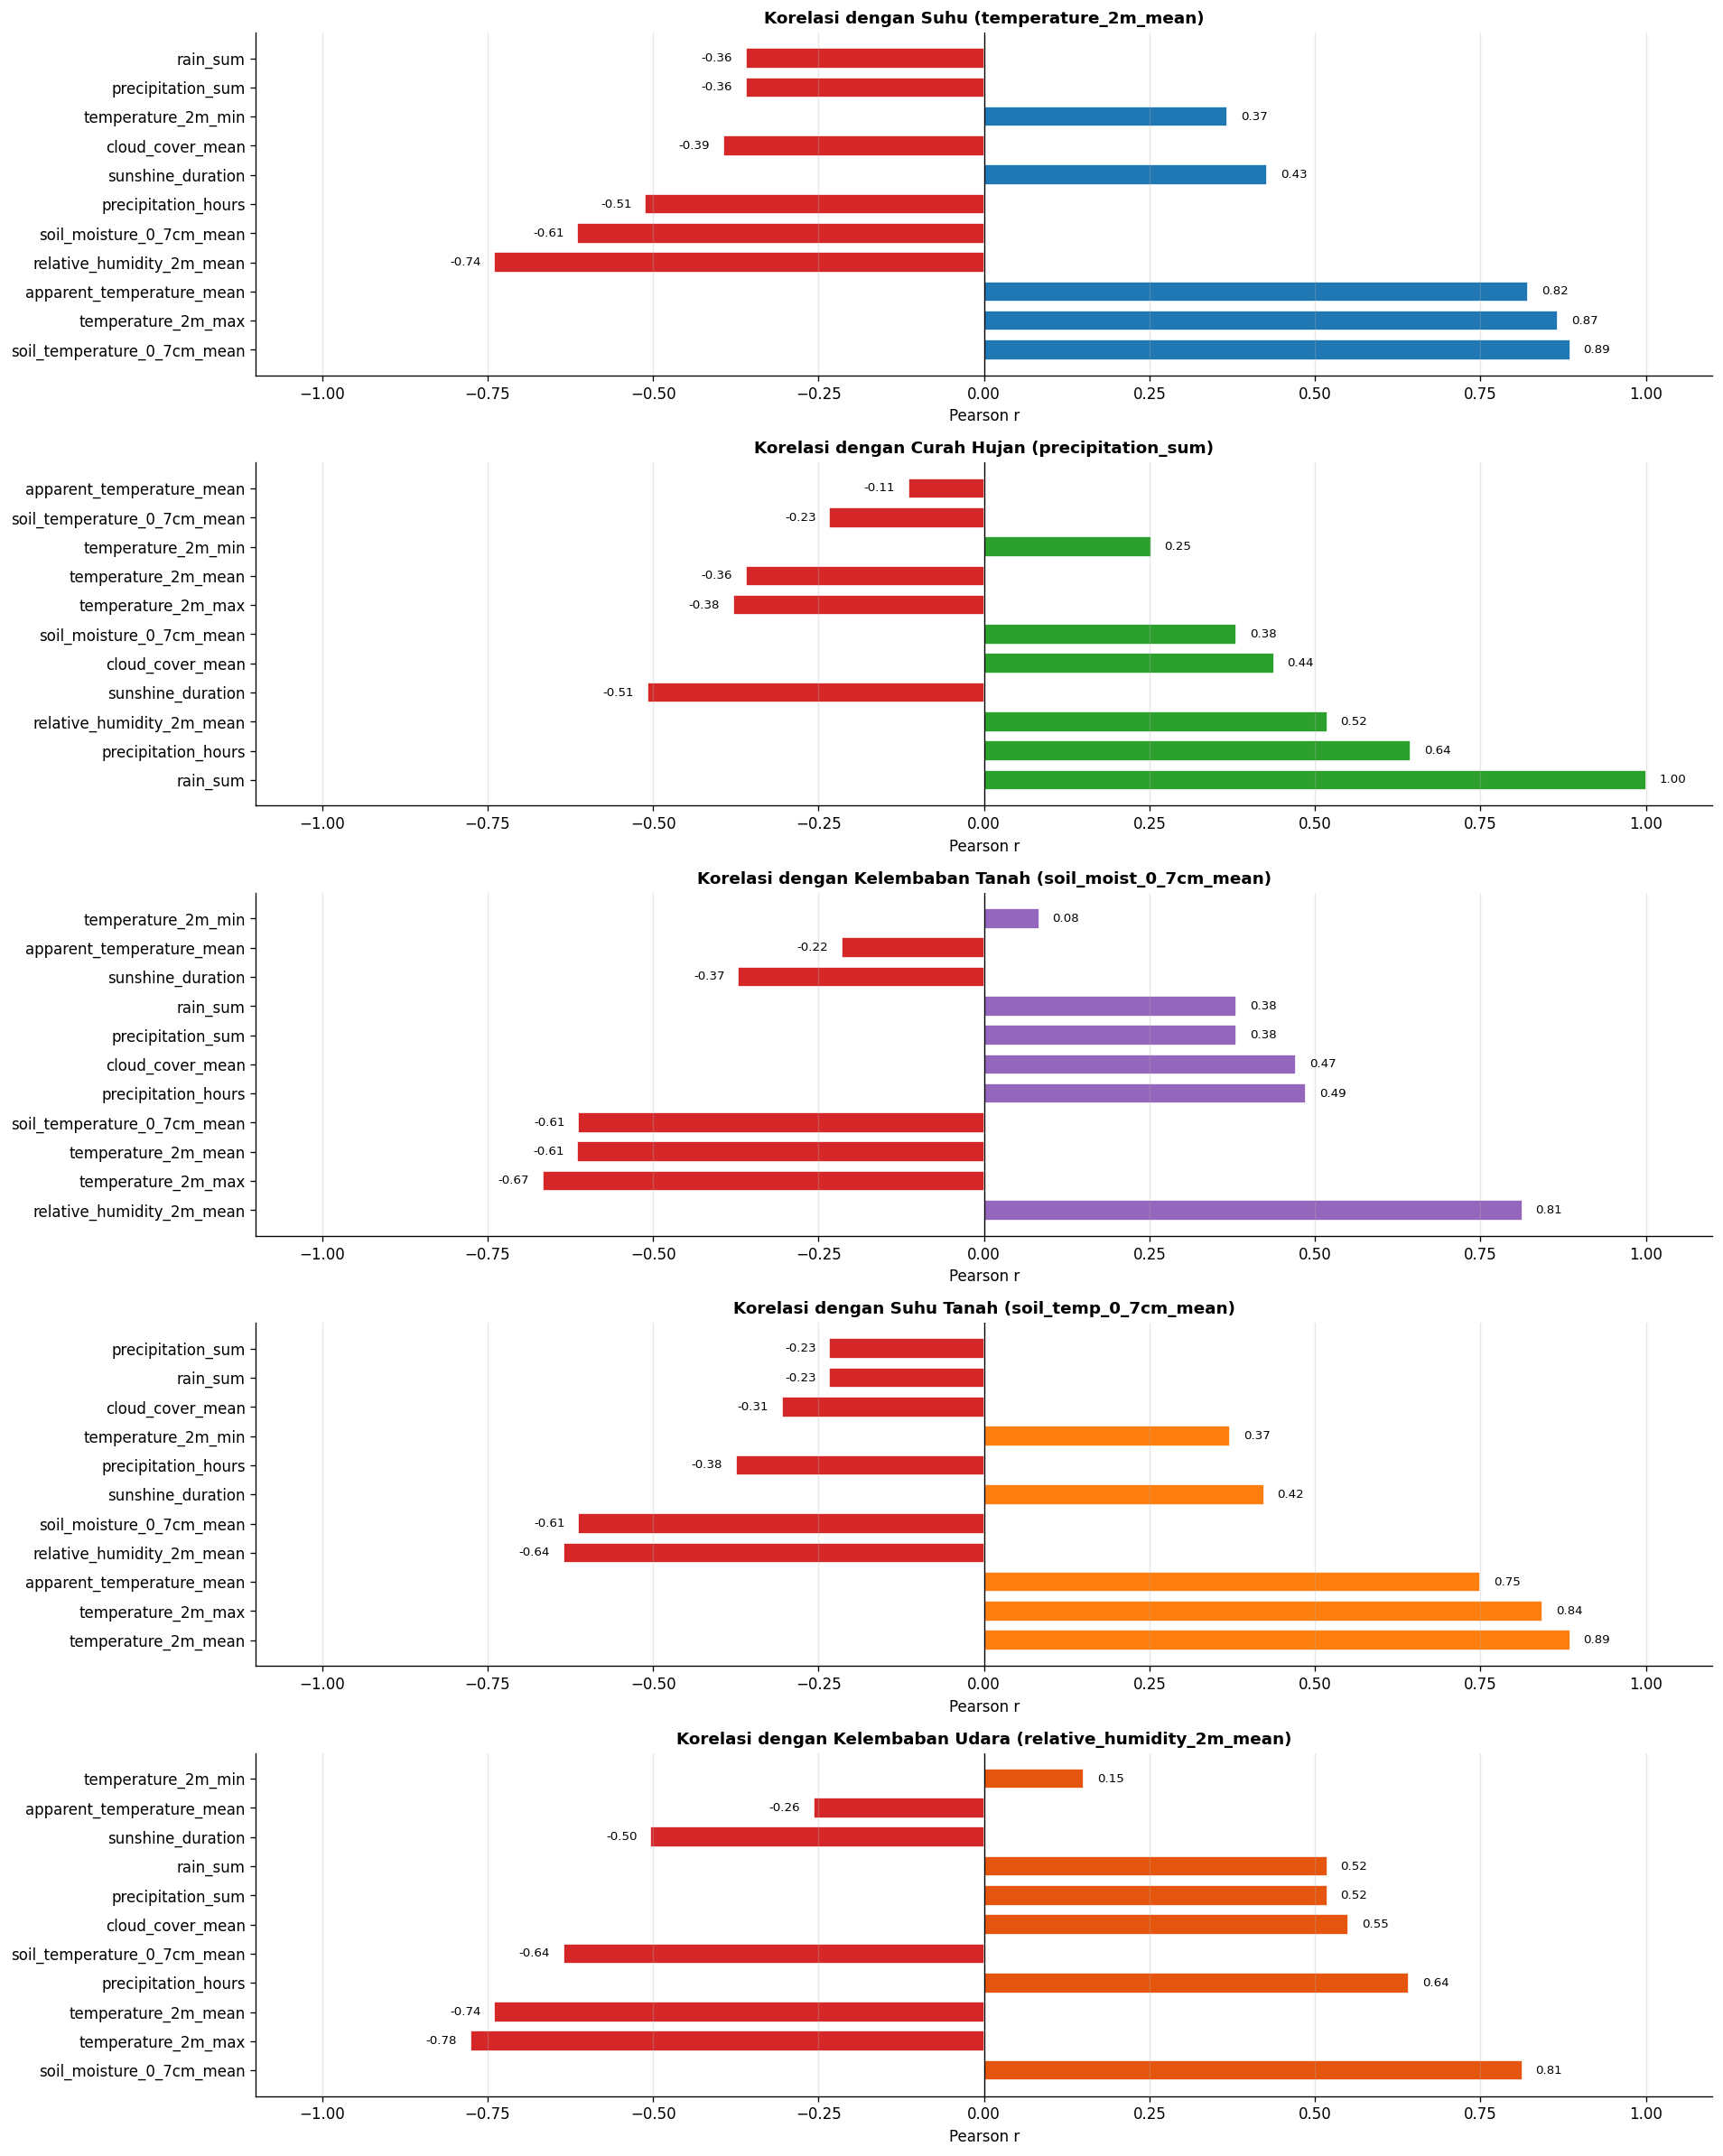

In [13]:
corr_with_temp = df[NUMERIC_FEATURES].corr()[COL_TEMP_2M_MEAN].drop(COL_TEMP_2M_MEAN).sort_values(key=abs, ascending=False)
corr_with_rain = df[NUMERIC_FEATURES].corr()[COL_PRECIPITATION_SUM].drop(COL_PRECIPITATION_SUM).sort_values(key=abs, ascending=False)
corr_with_soil_moist = df[NUMERIC_FEATURES].corr()[COL_SOIL_MOIST_0_7CM_MEAN].drop(COL_SOIL_MOIST_0_7CM_MEAN).sort_values(key=abs, ascending=False)
corr_with_soil_temp = df[NUMERIC_FEATURES].corr()[COL_SOIL_TEMP_0_7CM_MEAN].drop(COL_SOIL_TEMP_0_7CM_MEAN).sort_values(key=abs, ascending=False)
corr_with_humidity = df[NUMERIC_FEATURES].corr()[COL_RELATIVE_HUMIDITY_2M_MEAN].drop(COL_RELATIVE_HUMIDITY_2M_MEAN).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(5, 1, figsize=(16, 20))

for ax, corr, title, color_pos, color_neg in [
    (axes[0], corr_with_temp, 'Korelasi dengan Suhu (temperature_2m_mean)', '#1f77b4', '#d62728'),
    (axes[1], corr_with_rain, 'Korelasi dengan Curah Hujan (precipitation_sum)', '#2ca02c', '#d62728'),
    (axes[2], corr_with_soil_moist, 'Korelasi dengan Kelembaban Tanah (soil_moist_0_7cm_mean)', '#9467bd', '#d62728'),
    (axes[3], corr_with_soil_temp, 'Korelasi dengan Suhu Tanah (soil_temp_0_7cm_mean)', '#ff7f0e', '#d62728'),
    (axes[4], corr_with_humidity, 'Korelasi dengan Kelembaban Udara (relative_humidity_2m_mean)', '#e6550d', '#d62728'),
]:
    colors = [color_pos if v > 0 else color_neg for v in corr.values]
    bars = ax.barh(corr.index, corr.values, color=colors, edgecolor='white', height=0.7)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlim(-1.1, 1.1)
    ax.set_xlabel('Pearson r', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')
    for bar, val in zip(bars, corr.values):
        xpos = bar.get_width() + (0.02 if val > 0 else -0.02)
        ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
                va='center', ha='left' if val > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()


---
## Outlier

,Kolom,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persen (%)
0,temperature_2m_mean,24.20,25.30,1.10,22.55,26.95,833,2.65%
1,precipitation_sum,1.30,10.60,9.30,-12.65,24.55,1056,3.36%
2,relative_humidity_2m_mean,82.00,90.00,8.00,70.00,102.00,1118,3.56%
3,cloud_cover_mean,64.00,96.00,32.00,16.00,144.00,114,0.36%
4,sunshine_duration,31927.00,41431.82,9504.83,17669.75,55689.07,1815,5.78%
5,soil_temperature_0_7cm_mean,25.50,26.60,1.10,23.85,28.25,1435,4.57%


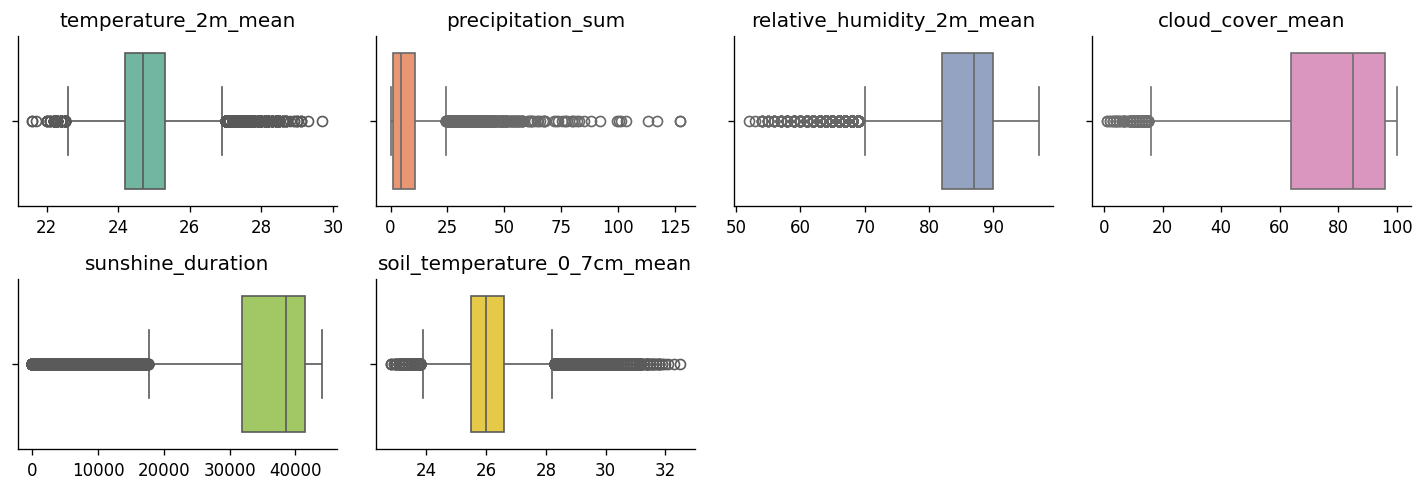

In [14]:
def detect_outliers_iqr(series, name):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    outliers = series[(series < lo) | (series > hi)]
    pct = len(outliers) / len(series) * 100
    return {'Kolom': name, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'Batas Bawah': lo, 'Batas Atas': hi,
            'Jumlah Outlier': len(outliers), 'Persen (%)': round(pct, 2)}

outlier_cols = [
    COL_TEMP_2M_MEAN, COL_PRECIPITATION_SUM,
    COL_RELATIVE_HUMIDITY_2M_MEAN, COL_CLOUD_COVER_MEAN,
    COL_SUNSHINE_DURATION, COL_SOIL_TEMP_0_7CM_MEAN
]

outlier_report = pd.DataFrame([detect_outliers_iqr(df[c].dropna(), c) for c in outlier_cols])
display(outlier_report.style
        .background_gradient(subset=['Persen (%)'], cmap='Reds')
        .format({'Q1': '{:.2f}', 'Q3': '{:.2f}', 'IQR': '{:.2f}',
                 'Batas Bawah': '{:.2f}', 'Batas Atas': '{:.2f}', 'Persen (%)': '{:.2f}%'}))

# show the outliers in boxplot
plt.figure(figsize=(12, 8))
for i, col in enumerate(outlier_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col], color=PALETTE[i % len(PALETTE)])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()


---
## Trend Iklim Jangka Panjang

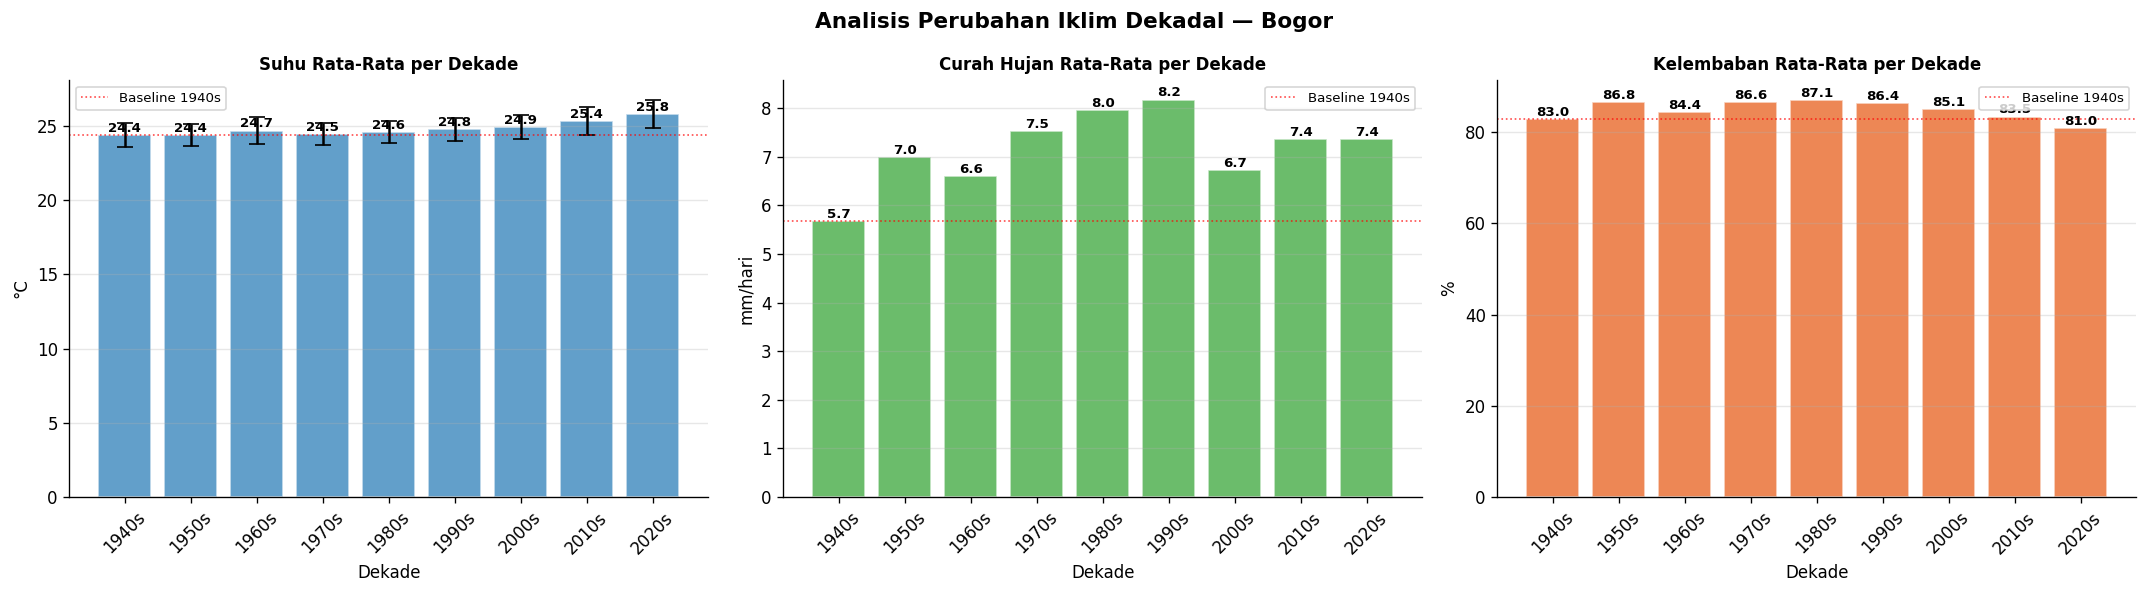

In [15]:
df_decade = df.groupby('decade').agg(
    suhu_mean=(COL_TEMP_2M_MEAN, 'mean'),
    suhu_std=(COL_TEMP_2M_MEAN, 'std'),
    hujan_mean=(COL_PRECIPITATION_SUM, 'mean'),
    rh_mean=(COL_RELATIVE_HUMIDITY_2M_MEAN, 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, std_col, title, ylabel, color in [
    (axes[0], 'suhu_mean', 'suhu_std', 'Suhu Rata-Rata per Dekade', '°C', '#1f77b4'),
    (axes[1], 'hujan_mean', None, 'Curah Hujan Rata-Rata per Dekade', 'mm/hari', '#2ca02c'),
    (axes[2], 'rh_mean', None, 'Kelembaban Rata-Rata per Dekade', '%', '#e6550d'),
]:
    bars = ax.bar(df_decade['decade'], df_decade[col], color=color, alpha=0.7, edgecolor='white')
    if std_col:
        ax.errorbar(df_decade['decade'], df_decade[col], yerr=df_decade[std_col],
                    fmt='none', color='black', capsize=5)

    # Tambah nilai
    for bar, val in zip(bars, df_decade[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Dekade'); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3, axis='y')

    # Highlight baseline decade
    base_val = df_decade[col].iloc[0]
    ax.axhline(base_val, color='red', lw=1, linestyle=':', alpha=0.7, label='Baseline 1940s')
    ax.legend(fontsize=8)

plt.suptitle('Analisis Perubahan Iklim Dekadal — Bogor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Coba cek klasifikasi oldeman

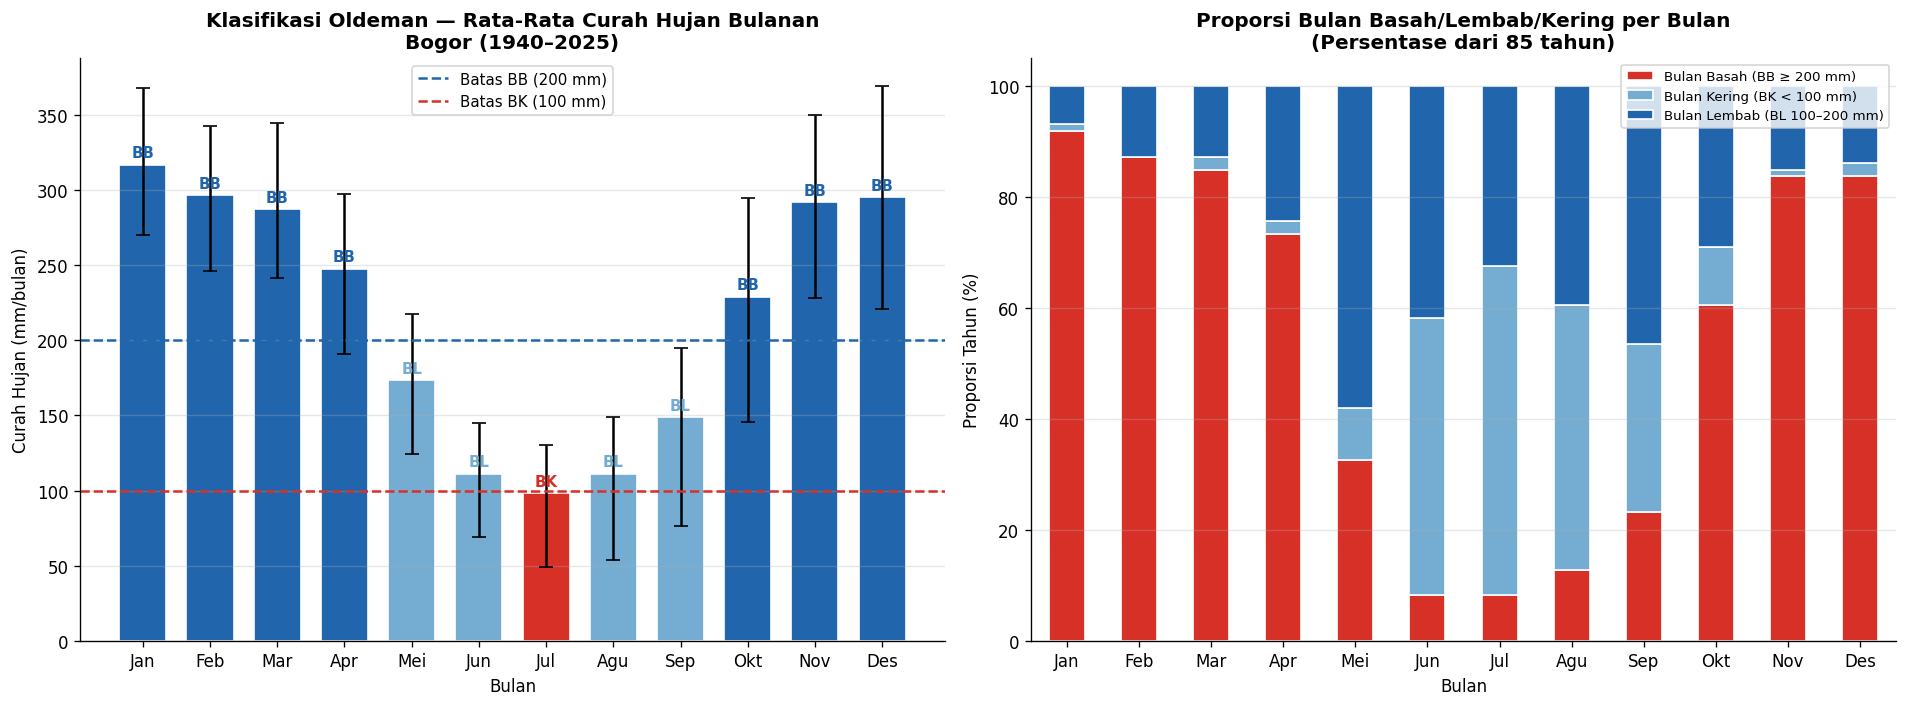


Klasifikasi Oldeman rata-rata per bulan:


,Bulan,Rata-Rata (mm),Kategori
0,Jan,316.984884,Bulan Basah (BB ≥ 200 mm)
1,Feb,296.506977,Bulan Basah (BB ≥ 200 mm)
2,Mar,287.416279,Bulan Basah (BB ≥ 200 mm)
3,Apr,247.844186,Bulan Basah (BB ≥ 200 mm)
4,Mei,173.584884,Bulan Lembab (BL 100–200 mm)
5,Jun,111.029070,Bulan Lembab (BL 100–200 mm)
6,Jul,98.106977,Bulan Kering (BK < 100 mm)
7,Agu,111.319767,Bulan Lembab (BL 100–200 mm)
8,Sep,148.798837,Bulan Lembab (BL 100–200 mm)
9,Okt,229.131395,Bulan Basah (BB ≥ 200 mm)


In [16]:
# oldeman
monthly_rain = df['precipitation_sum'].resample('ME').sum().reset_index()
monthly_rain.columns = ['date', 'rain_monthly_mm']
monthly_rain['month'] = monthly_rain['date'].dt.month
monthly_rain['year']  = monthly_rain['date'].dt.year

# Klasifikasi Oldeman
# Types of Oldeman ClimateThe system uses letters (A-E) for the total number of consecutive wet months and numbers (1-4) for consecutive dry months:Type A: Very wet, >9 wet months consecutively.Type B: Wet, 7-9 wet months consecutively.Type C: Moderate, 5-6 wet months consecutively.Type D: Dry, 3-4 wet months consecutively.Type E: Very dry, <3 wet months consecutively.
def classify_oldeman(mm):
    if mm >= 200: return 'Bulan Basah (BB ≥ 200 mm)'
    elif mm >= 100: return 'Bulan Lembab (BL 100–200 mm)'
    else: return 'Bulan Kering (BK < 100 mm)'

monthly_rain['kategori'] = monthly_rain['rain_monthly_mm'].apply(classify_oldeman)

# Rata-rata per bulan
mean_by_month = monthly_rain.groupby('month').agg(
    rain_mean=('rain_monthly_mm', 'mean'),
    rain_q25=('rain_monthly_mm', lambda x: x.quantile(0.25)),
    rain_q75=('rain_monthly_mm', lambda x: x.quantile(0.75)),
).reset_index()

mean_by_month['kategori_mean'] = mean_by_month['rain_mean'].apply(classify_oldeman)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart rata-rata bulanan
ax = axes[0]
color_map = {
    'Bulan Basah (BB ≥ 200 mm)': '#2166ac',
    'Bulan Lembab (BL 100–200 mm)': '#74add1',
    'Bulan Kering (BK < 100 mm)': '#d73027'
}
colors = [color_map[k] for k in mean_by_month['kategori_mean']]
bars = ax.bar(mean_by_month['month'], mean_by_month['rain_mean'],
              color=colors, edgecolor='white', width=0.7)
ax.errorbar(mean_by_month['month'], mean_by_month['rain_mean'],
            yerr=[mean_by_month['rain_mean'] - mean_by_month['rain_q25'],
                  mean_by_month['rain_q75'] - mean_by_month['rain_mean']],
            fmt='none', color='black', capsize=4)
ax.axhline(200, color='#2166ac', linestyle='--', lw=1.5, label='Batas BB (200 mm)')
ax.axhline(100, color='#d73027', linestyle='--', lw=1.5, label='Batas BK (100 mm)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_xlabel('Bulan'); ax.set_ylabel('Curah Hujan (mm/bulan)')
ax.set_title('Klasifikasi Oldeman — Rata-Rata Curah Hujan Bulanan\nBogor (1940–2025)', fontweight='bold')
ax.legend(fontsize=9)

# Tambah label BB/BK/BL
for bar, kat in zip(bars, mean_by_month['kategori_mean']):
    label = 'BB' if 'Basah' in kat else ('BK' if 'Kering' in kat else 'BL')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            label, ha='center', fontsize=9, fontweight='bold',
            color=color_map[kat])

ax.grid(alpha=0.3, axis='y')

# Proporsi BB/BL/BK per bulan (historical)
ax = axes[1]
prop = monthly_rain.groupby(['month', 'kategori']).size().unstack(fill_value=0)
prop = prop.div(prop.sum(axis=1), axis=0) * 100
prop.plot(kind='bar', ax=ax, stacked=True,
          color=['#d73027', '#74add1', '#2166ac'], edgecolor='white')
ax.set_xticklabels(MONTH_LABELS, rotation=0)
ax.set_xlabel('Bulan'); ax.set_ylabel('Proporsi Tahun (%)')
ax.set_title('Proporsi Bulan Basah/Lembab/Kering per Bulan\n(Persentase dari 85 tahun)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nKlasifikasi Oldeman rata-rata per bulan:')
display(mean_by_month[['month', 'rain_mean', 'kategori_mean']].assign(month=MONTH_LABELS).rename(columns={'month': 'Bulan', 'rain_mean': 'Rata-Rata (mm)', 'kategori_mean': 'Kategori'}))

**Interpretasi Klasifikasi Oldeman:**
- Bogor tergolong **tipe iklim A** (Oldeman) — > 9 Bulan Basah berturut-turut.
- **Okt–Apr**: Dominan Bulan Basah (>200 mm) → kondisi sangat mendukung tanam padi; risiko excess-water/banjir di puncak hujan.
- **Jun–Agu**: Cenderung Bulan Lembab–Kering → tergantung ketersediaan irigasi.
- **Rekomendasi MT padi**: MT1 = Oktober–Maret | MT2 = April–September (dengan irigasi dan pengairan yang baik).

# 02 Feature Engineering

## 2.1 Target & Exogenous — Resample Bulanan

**Target SARIMAX (4 series):**
- `temperature_2m_mean` → suhu udara rata-rata (mean bulanan)
- `precipitation_sum` → curah hujan (sum bulanan)
- `soil_moisture_0_7cm_mean` → kelembaban tanah (mean bulanan)
- `soil_temperature_0_7cm_mean` → suhu tanah (mean bulanan)

An exogenous variable in SARIMAX is an external, independent time series that influences the target variable but is not caused by it.
**Exogenous (X) candidates:** `relative_humidity_2m_mean`, `sunshine_duration`, `precipitation_hour_sum`,`cloud_cover_mean` 

**Split:**
- Train: 1940-01 → 2015-12  (76 tahun, 912 bulan)
- Test : 2016-01 → 2025-12  (10 tahun, 120 bulan)

Granularitasbulanan dipilih karena: (1) cocok dengan period musiman m=12 untuk SARIMAX, (2) ringan dibanding daily, (3) selaras dengan decomposisi STL pada EDA, (4) horizon bulanan lebih relevan untuk kalender tanam.

In [17]:
# Resample harian -> bulanan
# precipitation_sum pakai SUM (akumulasi); sisanya pakai MEAN

# COL_TIME = 'time' # waktu (tanggal) 0
# COL_WEATHER_CODE = 'weather_code' # kode cuaca (0-99)  1
# COL_TEMP_2M_MAX = 'temperature_2m_max' # suhu maksimum 2 meter (°C) 2
# COL_TEMP_2M_MEAN = 'temperature_2m_mean' # suhu rata-rata 2 meter (°C) 2
# COL_TEMP_2M_MIN = 'temperature_2m_min' # suhu minimum 2 meter (°C) 3
# COL_APPARENT_TEMP_MEAN = 'apparent_temperature_mean' # suhu terasa rata-rata (°C) 3
# COL_SUNSHINE_DURATION = 'sunshine_duration' # durasi sinar matahari (s) 4
# COL_CLOUD_COVER_MEAN = 'cloud_cover_mean' # tutupan awan rata-rata (%) 5
# COL_PRECIPITATION_SUM = 'precipitation_sum' # jumlah presipitasi (mm) 5
# COL_PRECIPITATION_HOURS_SUM = 'precipitation_hours' # jumlah jam presipitasi (jam) 6
# COL_RAIN_SUM = 'rain_sum' # jumlah hujan (mm) 7
# COL_SOIL_MOIST_0_7CM_MEAN = 'soil_moisture_0_7cm_mean' # kelembaban tanah 0-7 cm rata-rata (m³/m³) 8
# COL_SOIL_TEMP_0_7CM_MEAN = 'soil_temperature_0_7cm_mean' # suhu tanah 0-7 cm rata-rata (°C) 9 
# COL_RELATIVE_HUMIDITY_2M_MEAN = 'relative_humidity_2m_mean' # kelembaban relatif 2 meter rata-rata (%) 10

agg_map = {
    COL_TEMP_2M_MEAN: 'mean',
    COL_PRECIPITATION_SUM: 'mean',
    COL_SOIL_MOIST_0_7CM_MEAN: 'mean',
    COL_SOIL_TEMP_0_7CM_MEAN: 'mean',
    COL_RELATIVE_HUMIDITY_2M_MEAN: 'mean',
    COL_SUNSHINE_DURATION: 'mean',
    COL_CLOUD_COVER_MEAN: 'mean',
    COL_PRECIPITATION_HOURS_SUM: 'mean',
}
df_m = df[list(agg_map.keys())].resample('MS').agg(agg_map)
df_m.index.freq = 'MS'

# Definisi target & exogenous
TARGETS = [COL_TEMP_2M_MEAN, COL_PRECIPITATION_SUM,
           COL_SOIL_MOIST_0_7CM_MEAN, COL_SOIL_TEMP_0_7CM_MEAN]
EXOG    = [COL_RELATIVE_HUMIDITY_2M_MEAN, COL_SUNSHINE_DURATION, COL_PRECIPITATION_HOURS_SUM, COL_CLOUD_COVER_MEAN]

TARGET_LABELS = {
    COL_TEMP_2M_MEAN: 'Suhu Udara (°C)',
    COL_PRECIPITATION_SUM: 'Curah Hujan (mm)',
    COL_SOIL_MOIST_0_7CM_MEAN: 'Kelembaban Tanah (m³/m³)',
    COL_SOIL_TEMP_0_7CM_MEAN: 'Suhu Tanah (°C)',
}

# Split train / test
SPLIT_DATE = '2016-01-01'
train = df_m.loc[:'2015-12-31']
test  = df_m.loc[SPLIT_DATE:]

print(f'Periode penuh : {df_m.index.min().date()} → {df_m.index.max().date()}  ({len(df_m)} bulan)')
print(f'Train         : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} bulan)')
print(f'Test          : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} bulan)')
print(f'Targets   ({len(TARGETS)}) : {TARGETS}')
print(f'Exogenous ({len(EXOG)}) : {EXOG}')
df_m.head()

Periode penuh : 1940-01-01 → 2025-12-01  (1032 bulan)
Train         : 1940-01-01 → 2015-12-01  (912 bulan)
Test          : 2016-01-01  → 2025-12-01  (120 bulan)
Targets   (4) : ['temperature_2m_mean', 'precipitation_sum', 'soil_moisture_0_7cm_mean', 'soil_temperature_0_7cm_mean']
Exogenous (4) : ['relative_humidity_2m_mean', 'sunshine_duration', 'precipitation_hours', 'cloud_cover_mean']


,temperature_2m_mean,precipitation_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean,sunshine_duration,cloud_cover_mean,precipitation_hours
time,,,,,,,,
1940-01-01,23.080000,11.686667,0.492667,24.280000,89.166667,24444.787000,96.366667,14.633333
1940-02-01,23.496552,5.834483,0.487862,24.713793,87.344828,34958.672759,88.896552,10.103448
1940-03-01,24.332258,4.167742,0.451000,25.841935,85.290323,40973.355484,75.709677,6.612903
1940-04-01,24.460000,5.283333,0.443300,26.056667,86.033333,38914.885333,66.866667,9.000000
1940-05-01,23.961290,7.435484,0.485677,25.341935,88.967742,30871.090000,87.935484,10.935484


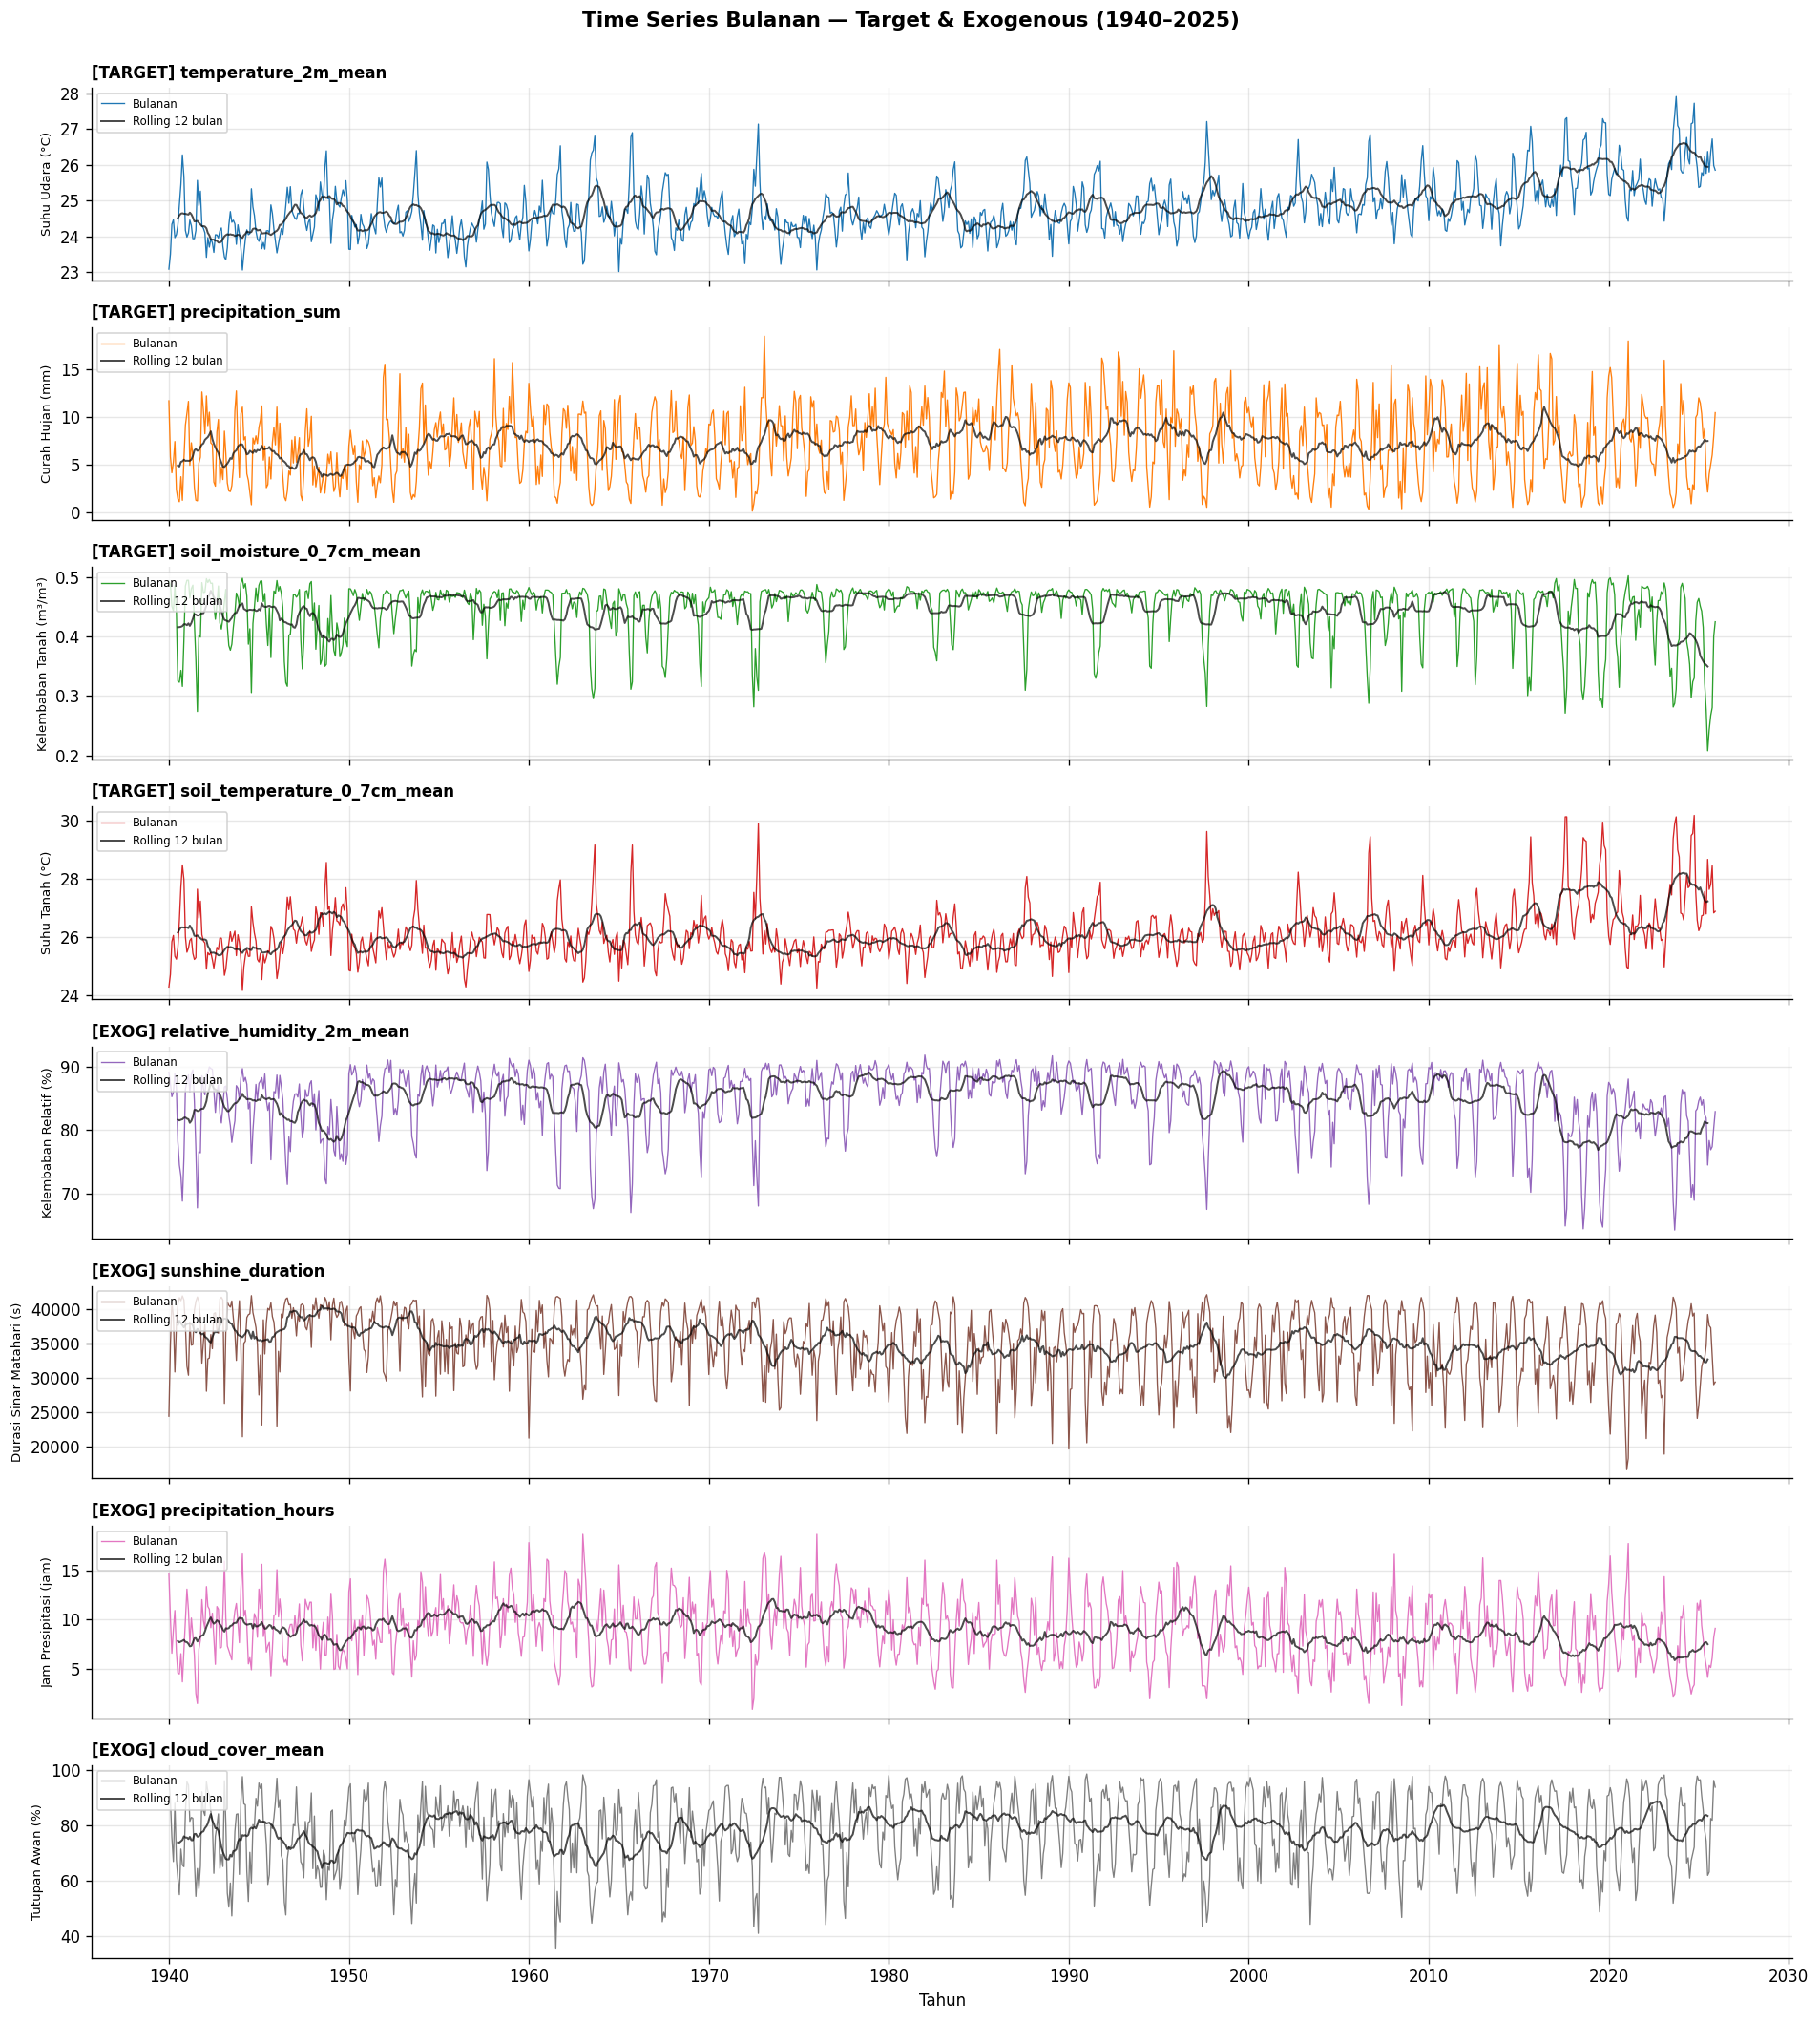

In [18]:
# Visualisasi time series setelah agregasi bulanan (target + exogenous)
VIS_COLS = TARGETS + EXOG
VIS_LABELS = {
    COL_TEMP_2M_MEAN: 'Suhu Udara (°C)',
    COL_PRECIPITATION_SUM: 'Curah Hujan (mm)',
    COL_SOIL_MOIST_0_7CM_MEAN: 'Kelembaban Tanah (m³/m³)',
    COL_SOIL_TEMP_0_7CM_MEAN: 'Suhu Tanah (°C)',
    COL_RELATIVE_HUMIDITY_2M_MEAN: 'Kelembaban Relatif (%)',
    COL_SUNSHINE_DURATION: 'Durasi Sinar Matahari (s)',
    COL_PRECIPITATION_HOURS_SUM: 'Jam Presipitasi (jam)',
    COL_CLOUD_COVER_MEAN: 'Tutupan Awan (%)',
}
vis_colors = sns.color_palette('tab10', n_colors=len(VIS_COLS))

fig, axes = plt.subplots(len(VIS_COLS), 1, figsize=(16, 2.2 * len(VIS_COLS)), sharex=True)
for ax, col, c in zip(axes, VIS_COLS, vis_colors):
    ax.plot(df_m.index, df_m[col], color=c, lw=0.8, label='Bulanan')
    ax.plot(df_m[col].rolling(12, center=True).mean(),
            color='black', lw=1.2, alpha=0.7, label='Rolling 12 bulan')
    tag = '[TARGET]' if col in TARGETS else '[EXOG]'
    ax.set_title(f'{tag} {col}', fontsize=10, fontweight='bold', loc='left')
    ax.set_ylabel(VIS_LABELS.get(col, col), fontsize=8)
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Tahun')
plt.suptitle('Time Series Bulanan — Target & Exogenous (1940–2025)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

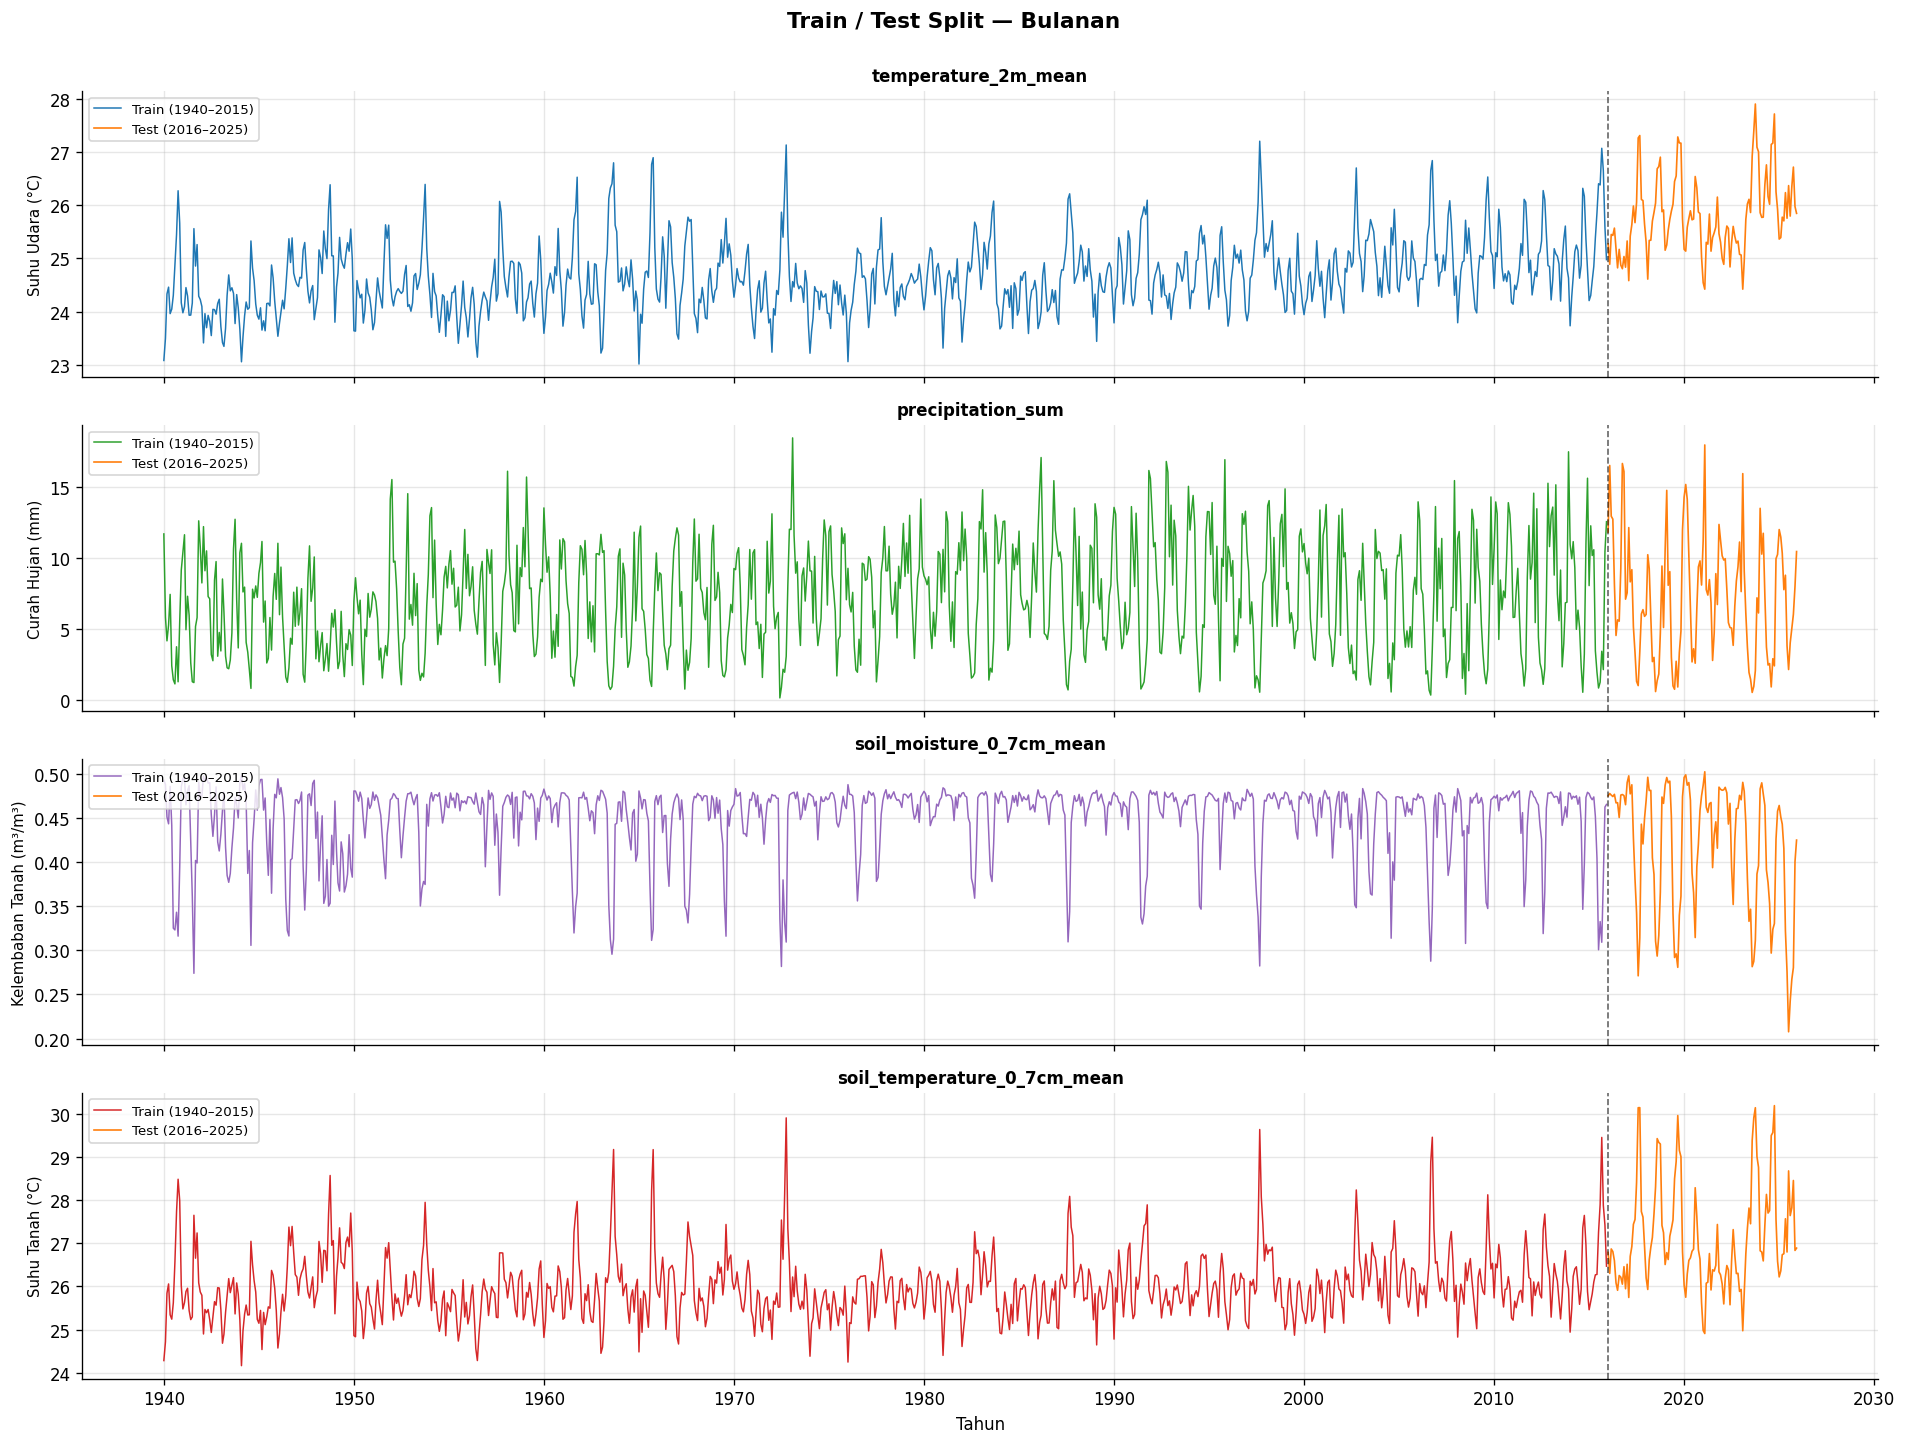

In [19]:
# Visualisasi split train vs test pada 4 target
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']

for ax, col, c in zip(axes, TARGETS, colors):
    ax.plot(train.index, train[col], color=c, lw=0.9, label='Train (1940–2015)')
    ax.plot(test.index,  test[col],  color='#ff7f0e', lw=1.0, label='Test (2016–2025)')
    ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', lw=1, linestyle='--', alpha=0.6)
    ax.set_ylabel(TARGET_LABELS[col], fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Tahun')
plt.suptitle('Train / Test Split — Bulanan', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 2.2 Uji Stasioneritas (ADF + KPSS)

| ADF (H0: non-stasioner) | KPSS (H0: stasioner) | Kesimpulan |
|---|---|---|
| reject (p<0.05) | tidak reject (p≥0.05) | **Stasioner** |
| tidak reject | reject | **Non-stasioner** → differencing |
| reject | reject | Stasioner-trend → seasonal/regular diff |
| tidak reject | tidak reject | Tidak konklusif (sampel kurang) |

Diuji pada **train** (1940–2015)

In [20]:
def stationarity_test(series, name=''):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')

    adf_stationary  = adf_p  < 0.05   # tolak H0 non-stasioner
    kpss_stationary = kpss_p >= 0.05  # tidak tolak H0 stasioner

    if adf_stationary and kpss_stationary:
        verdict = '✅ Stasioner'
    elif (not adf_stationary) and (not kpss_stationary):
        verdict = '❌ Non-stasioner (diff dibutuhkan)'
    elif adf_stationary and not kpss_stationary:
        verdict = '⚠️  Difference-stasioner (perlu diff)'
    else:
        verdict = '⚠️  Trend-stasioner'

    return {
        'Series'   : name,
        'ADF stat' : round(adf_stat, 3),
        'ADF p'    : round(adf_p, 4),
        'KPSS stat': round(kpss_stat, 3),
        'KPSS p'   : round(kpss_p, 4),
        'Verdict'  : verdict,
    }

# Tes pada level (raw) untuk 4 target
rows_raw = [stationarity_test(train[c], name=c) for c in TARGETS]
stat_raw = pd.DataFrame(rows_raw)
print('=== Stasioneritas — LEVEL (raw) ===')
display(stat_raw.style.set_properties(**{'text-align': 'left'}))

=== Stasioneritas — LEVEL (raw) ===


/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


,Series,ADF stat,ADF p,KPSS stat,KPSS p,Verdict
0,temperature_2m_mean,-3.963000,0.001600,2.080000,0.010000,⚠️ Difference-stasioner (perlu diff)
1,precipitation_sum,-4.757000,0.000100,1.111000,0.010000,⚠️ Difference-stasioner (perlu diff)
2,soil_moisture_0_7cm_mean,-5.719000,0.000000,0.452000,0.054900,✅ Stasioner
3,soil_temperature_0_7cm_mean,-5.384000,0.000000,0.669000,0.016400,⚠️ Difference-stasioner (perlu diff)


In [21]:
# Seasonal differencing (lag 12) + 1st-order differencing
diff_results = {}
for col in TARGETS:
    s = train[col]
    s_d1  = s.diff().dropna()                 # regular diff d=1
    s_D1  = s.diff(12).dropna()               # seasonal diff D=1, m=12
    s_d1D1 = s.diff(12).diff().dropna()       # gabungan d=1, D=1
    diff_results[col] = {
        'd=1'      : s_d1,
        'D=1 (m12)': s_D1,
        'd=1,D=1'  : s_d1D1,
    }

rows_diff = []
for col, variants in diff_results.items():
    for label, series in variants.items():
        rec = stationarity_test(series, name=f'{col}  [{label}]')
        rows_diff.append(rec)

stat_diff = pd.DataFrame(rows_diff)
print('=== Stasioneritas — Setelah Differencing ===')
display(stat_diff.style.set_properties(**{'text-align': 'left'}))

=== Stasioneritas — Setelah Differencing ===


/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value

,Series,ADF stat,ADF p,KPSS stat,KPSS p,Verdict
0,temperature_2m_mean [d=1],-12.618000,0.000000,0.115000,0.100000,✅ Stasioner
1,temperature_2m_mean [D=1 (m12)],-10.352000,0.000000,0.021000,0.100000,✅ Stasioner
2,"temperature_2m_mean [d=1,D=1]",-9.580000,0.000000,0.015000,0.100000,✅ Stasioner
3,precipitation_sum [d=1],-13.242000,0.000000,0.019000,0.100000,✅ Stasioner
4,precipitation_sum [D=1 (m12)],-11.611000,0.000000,0.024000,0.100000,✅ Stasioner
5,"precipitation_sum [d=1,D=1]",-12.417000,0.000000,0.045000,0.100000,✅ Stasioner
6,soil_moisture_0_7cm_mean [d=1],-12.753000,0.000000,0.027000,0.100000,✅ Stasioner
7,soil_moisture_0_7cm_mean [D=1 (m12)],-8.764000,0.000000,0.038000,0.100000,✅ Stasioner
8,"soil_moisture_0_7cm_mean [d=1,D=1]",-9.636000,0.000000,0.032000,0.100000,✅ Stasioner
9,soil_temperature_0_7cm_mean [d=1],-12.616000,0.000000,0.064000,0.100000,✅ Stasioner


## 2.3 ACF & PACF — Identifikasi Order (p, q, P, Q)

- **PACF cut-off di lag k** → kandidat order **AR(p=k)**.
- **ACF cut-off di lag k** → kandidat order **MA(q=k)**.
- **Spike di lag musiman (12, 24, …)** → komponen seasonal **P/Q**.

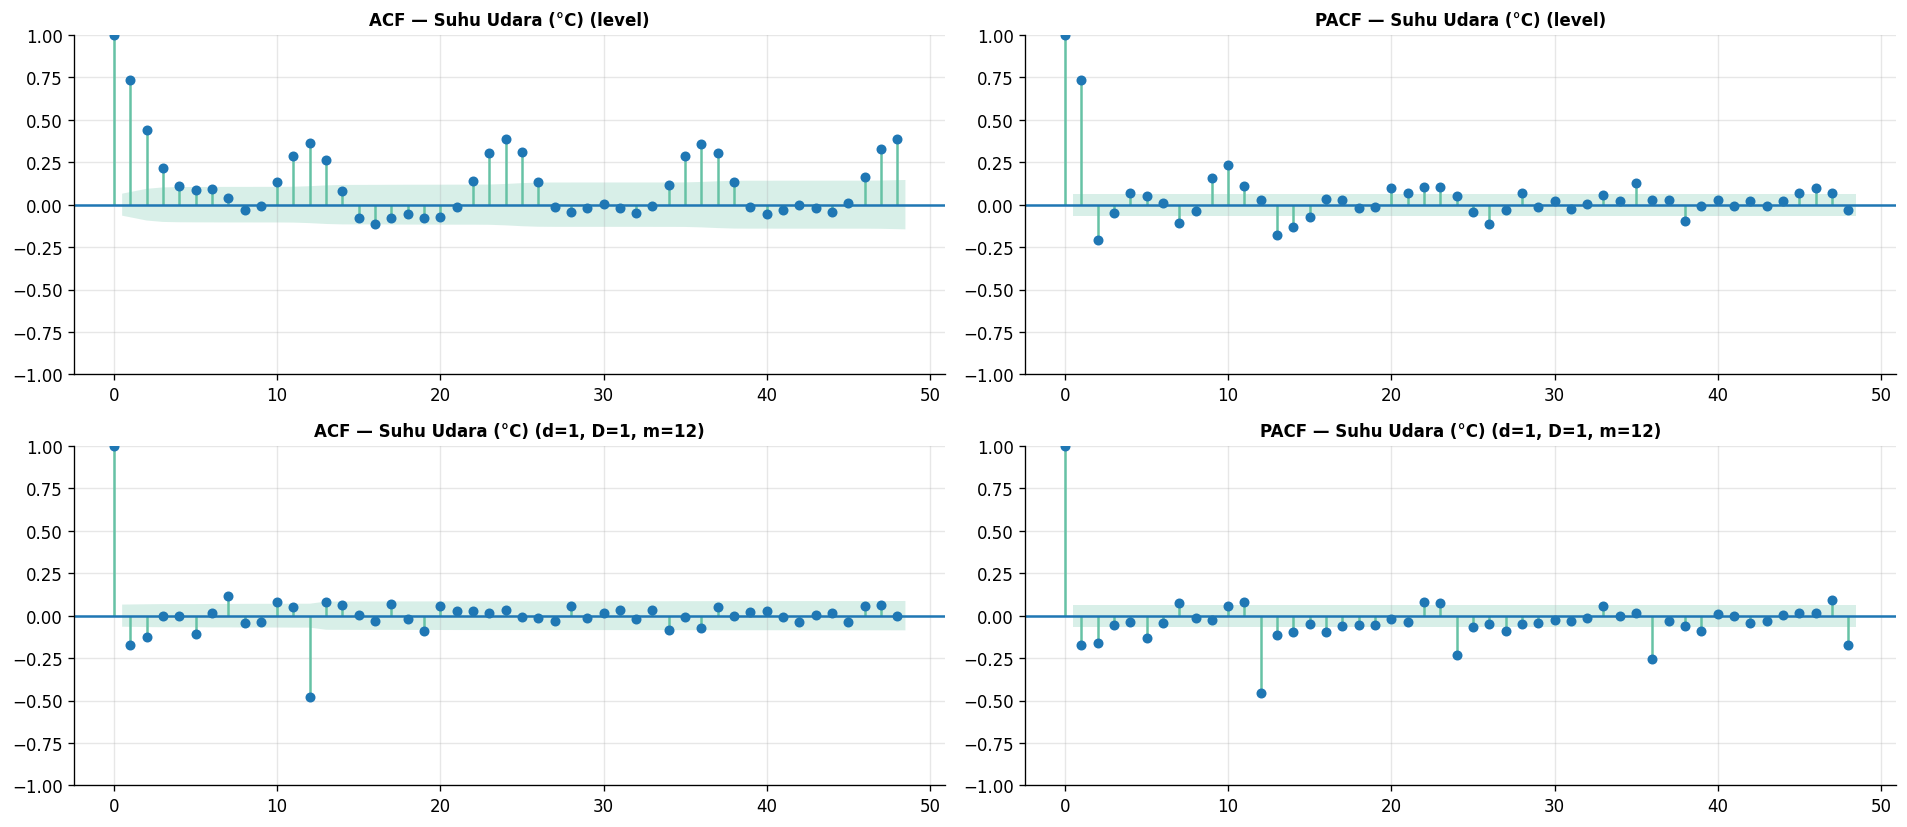

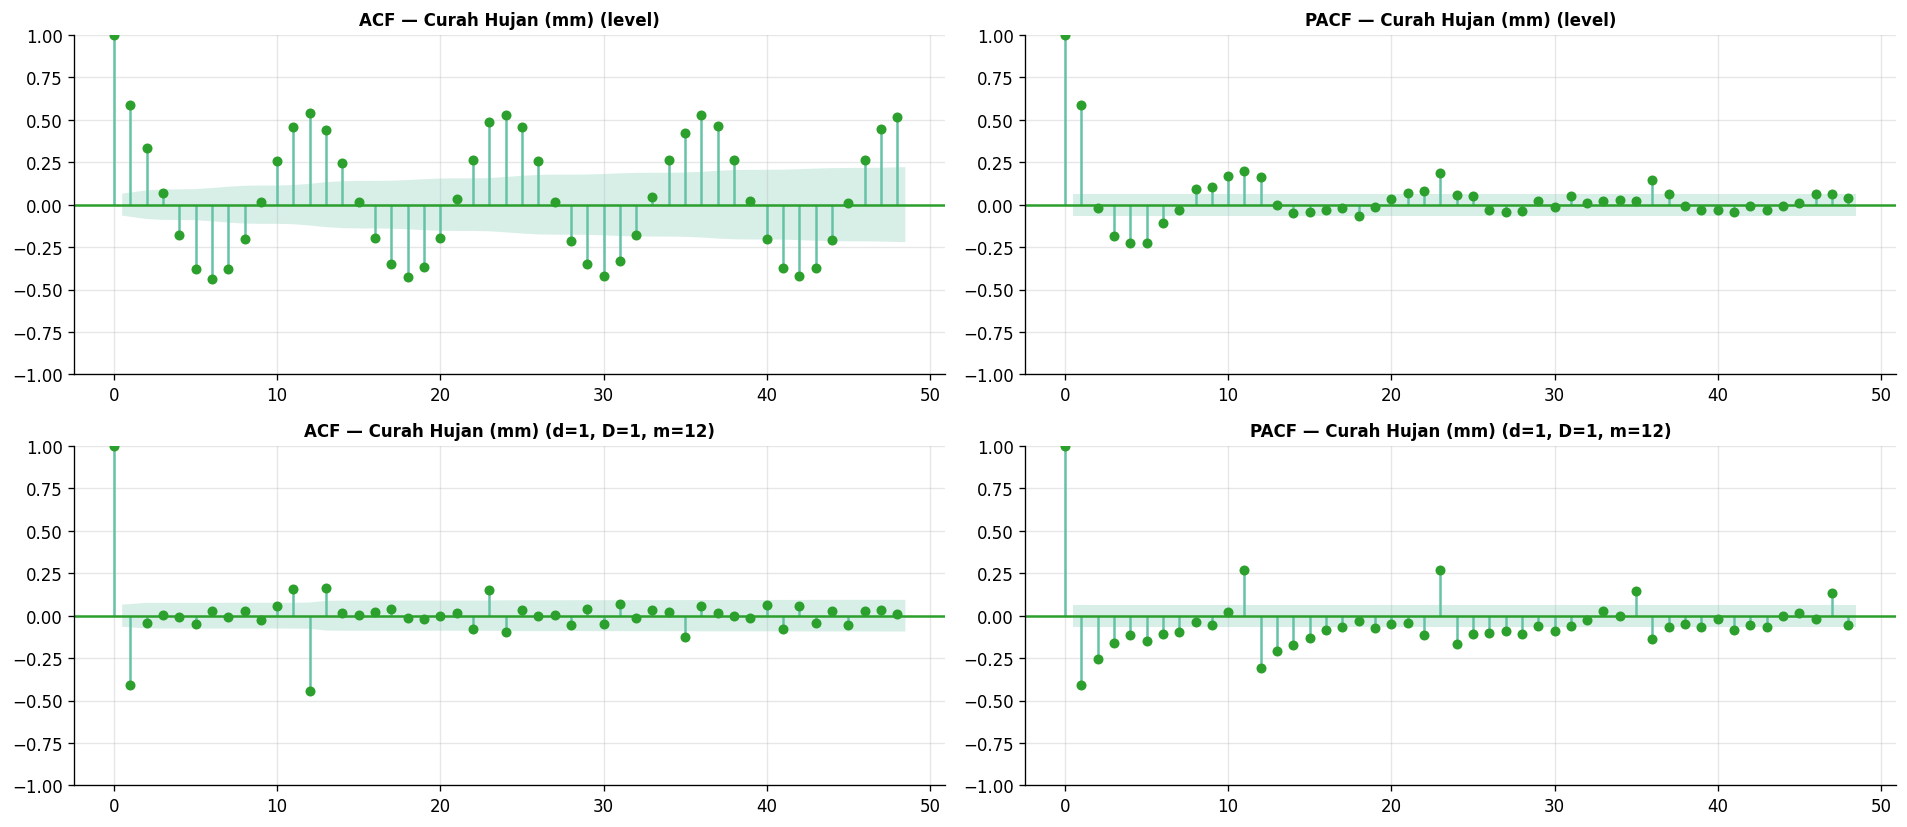

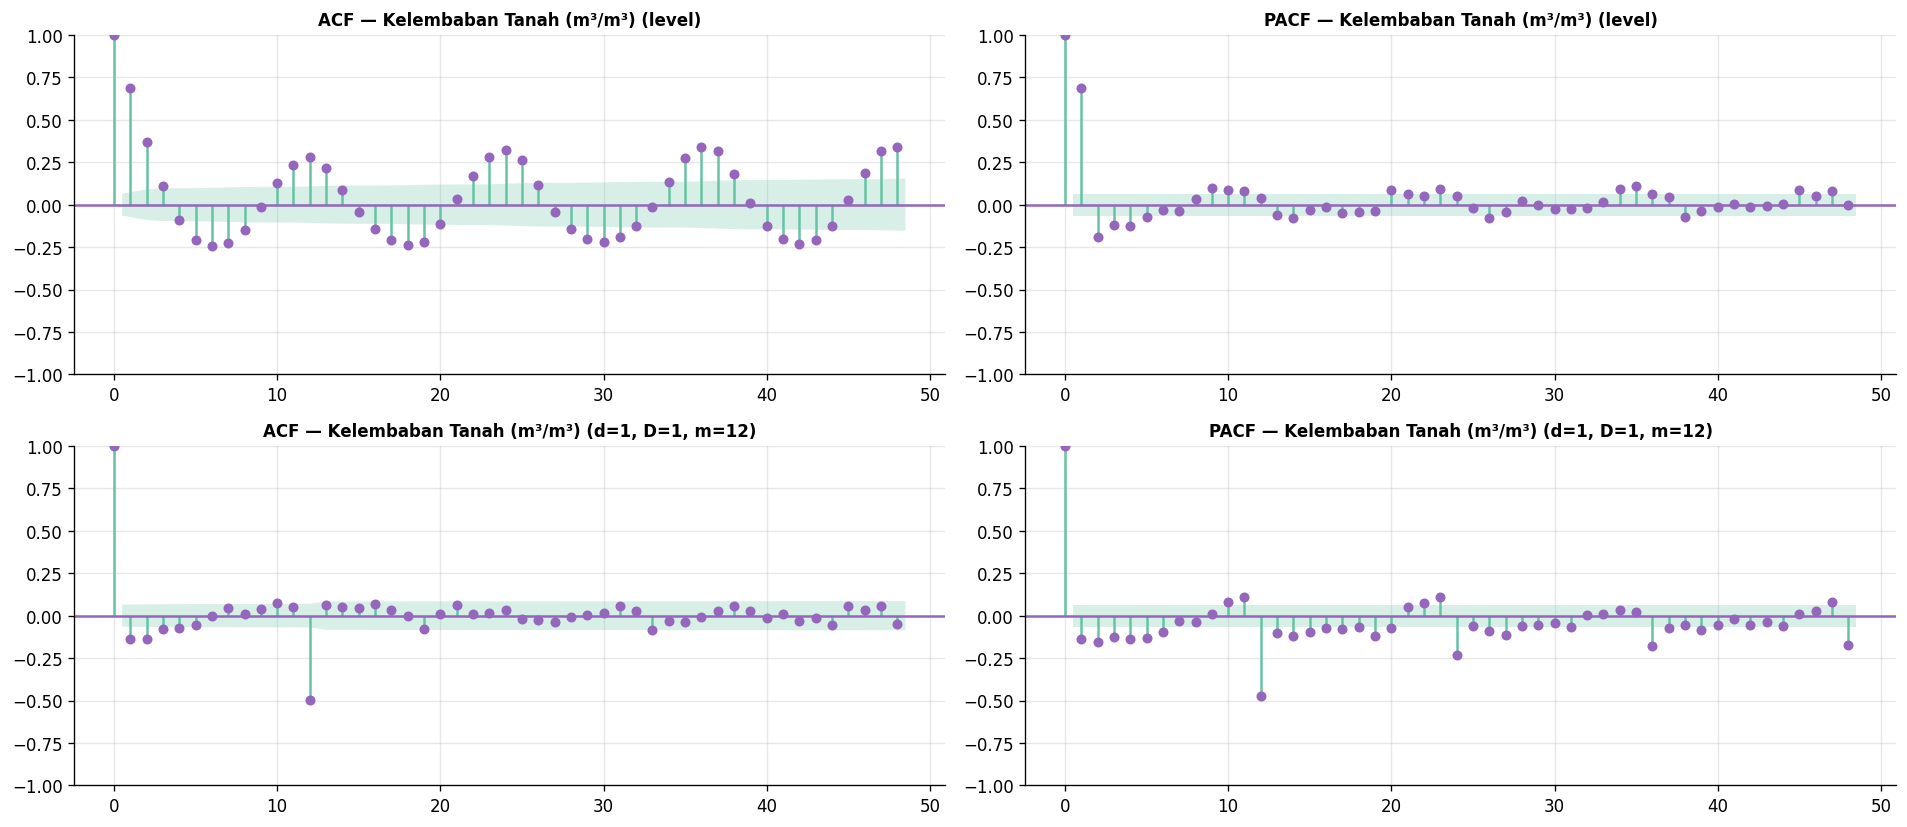

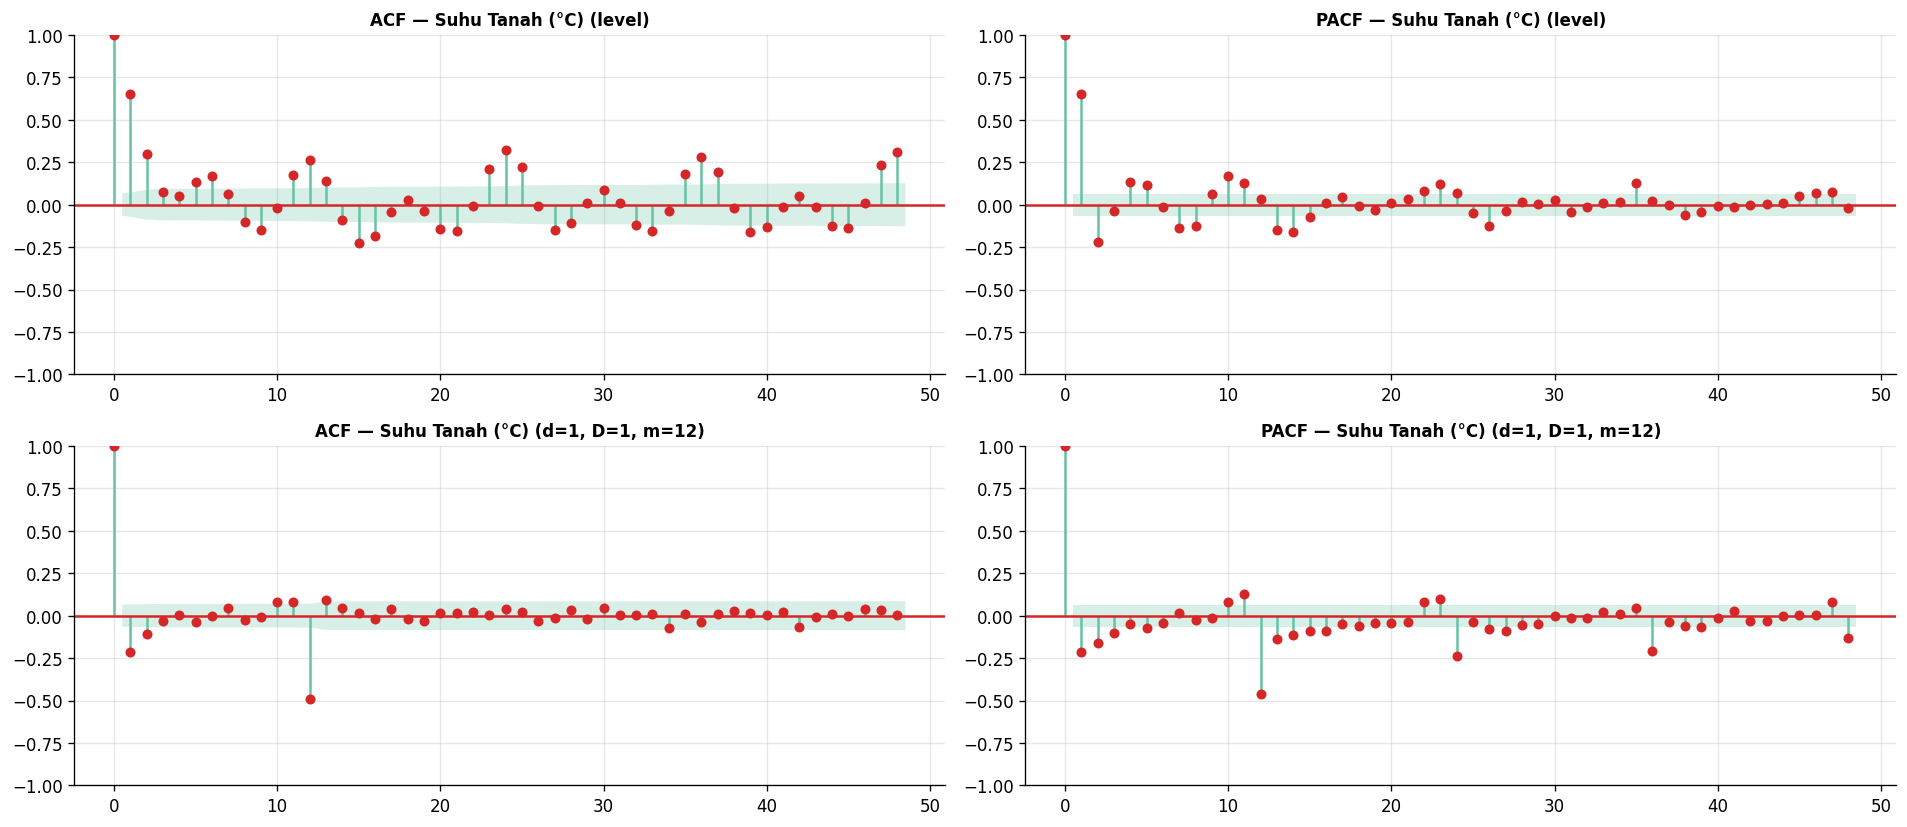

In [22]:
# Plot ACF / PACF: level vs differenced (d=1,D=1) — pakai m=12, lags=48 (4 tahun)
LAGS = 48

def plot_acf_pacf(series_level, series_diff, title, color):
    fig, axes = plt.subplots(2, 2, figsize=(16, 7))

    # Level
    plot_acf(series_level.dropna(),  lags=LAGS, ax=axes[0, 0], color=color)
    axes[0, 0].set_title(f'ACF — {title} (level)',  fontsize=10, fontweight='bold')
    plot_pacf(series_level.dropna(), lags=LAGS, ax=axes[0, 1], color=color, method='ywm')
    axes[0, 1].set_title(f'PACF — {title} (level)', fontsize=10, fontweight='bold')

    # Differenced
    plot_acf(series_diff.dropna(),   lags=LAGS, ax=axes[1, 0], color=color)
    axes[1, 0].set_title(f'ACF — {title} (d=1, D=1, m=12)',  fontsize=10, fontweight='bold')
    plot_pacf(series_diff.dropna(),  lags=LAGS, ax=axes[1, 1], color=color, method='ywm')
    axes[1, 1].set_title(f'PACF — {title} (d=1, D=1, m=12)', fontsize=10, fontweight='bold')

    for ax in axes.flat:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

target_colors = dict(zip(TARGETS, ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']))

for col in TARGETS:
    s_level = train[col]
    s_diff  = diff_results[col]['d=1,D=1']
    plot_acf_pacf(s_level, s_diff, title=TARGET_LABELS[col], color=target_colors[col])

## 2.4 Visualisasi Series Setelah Differencing


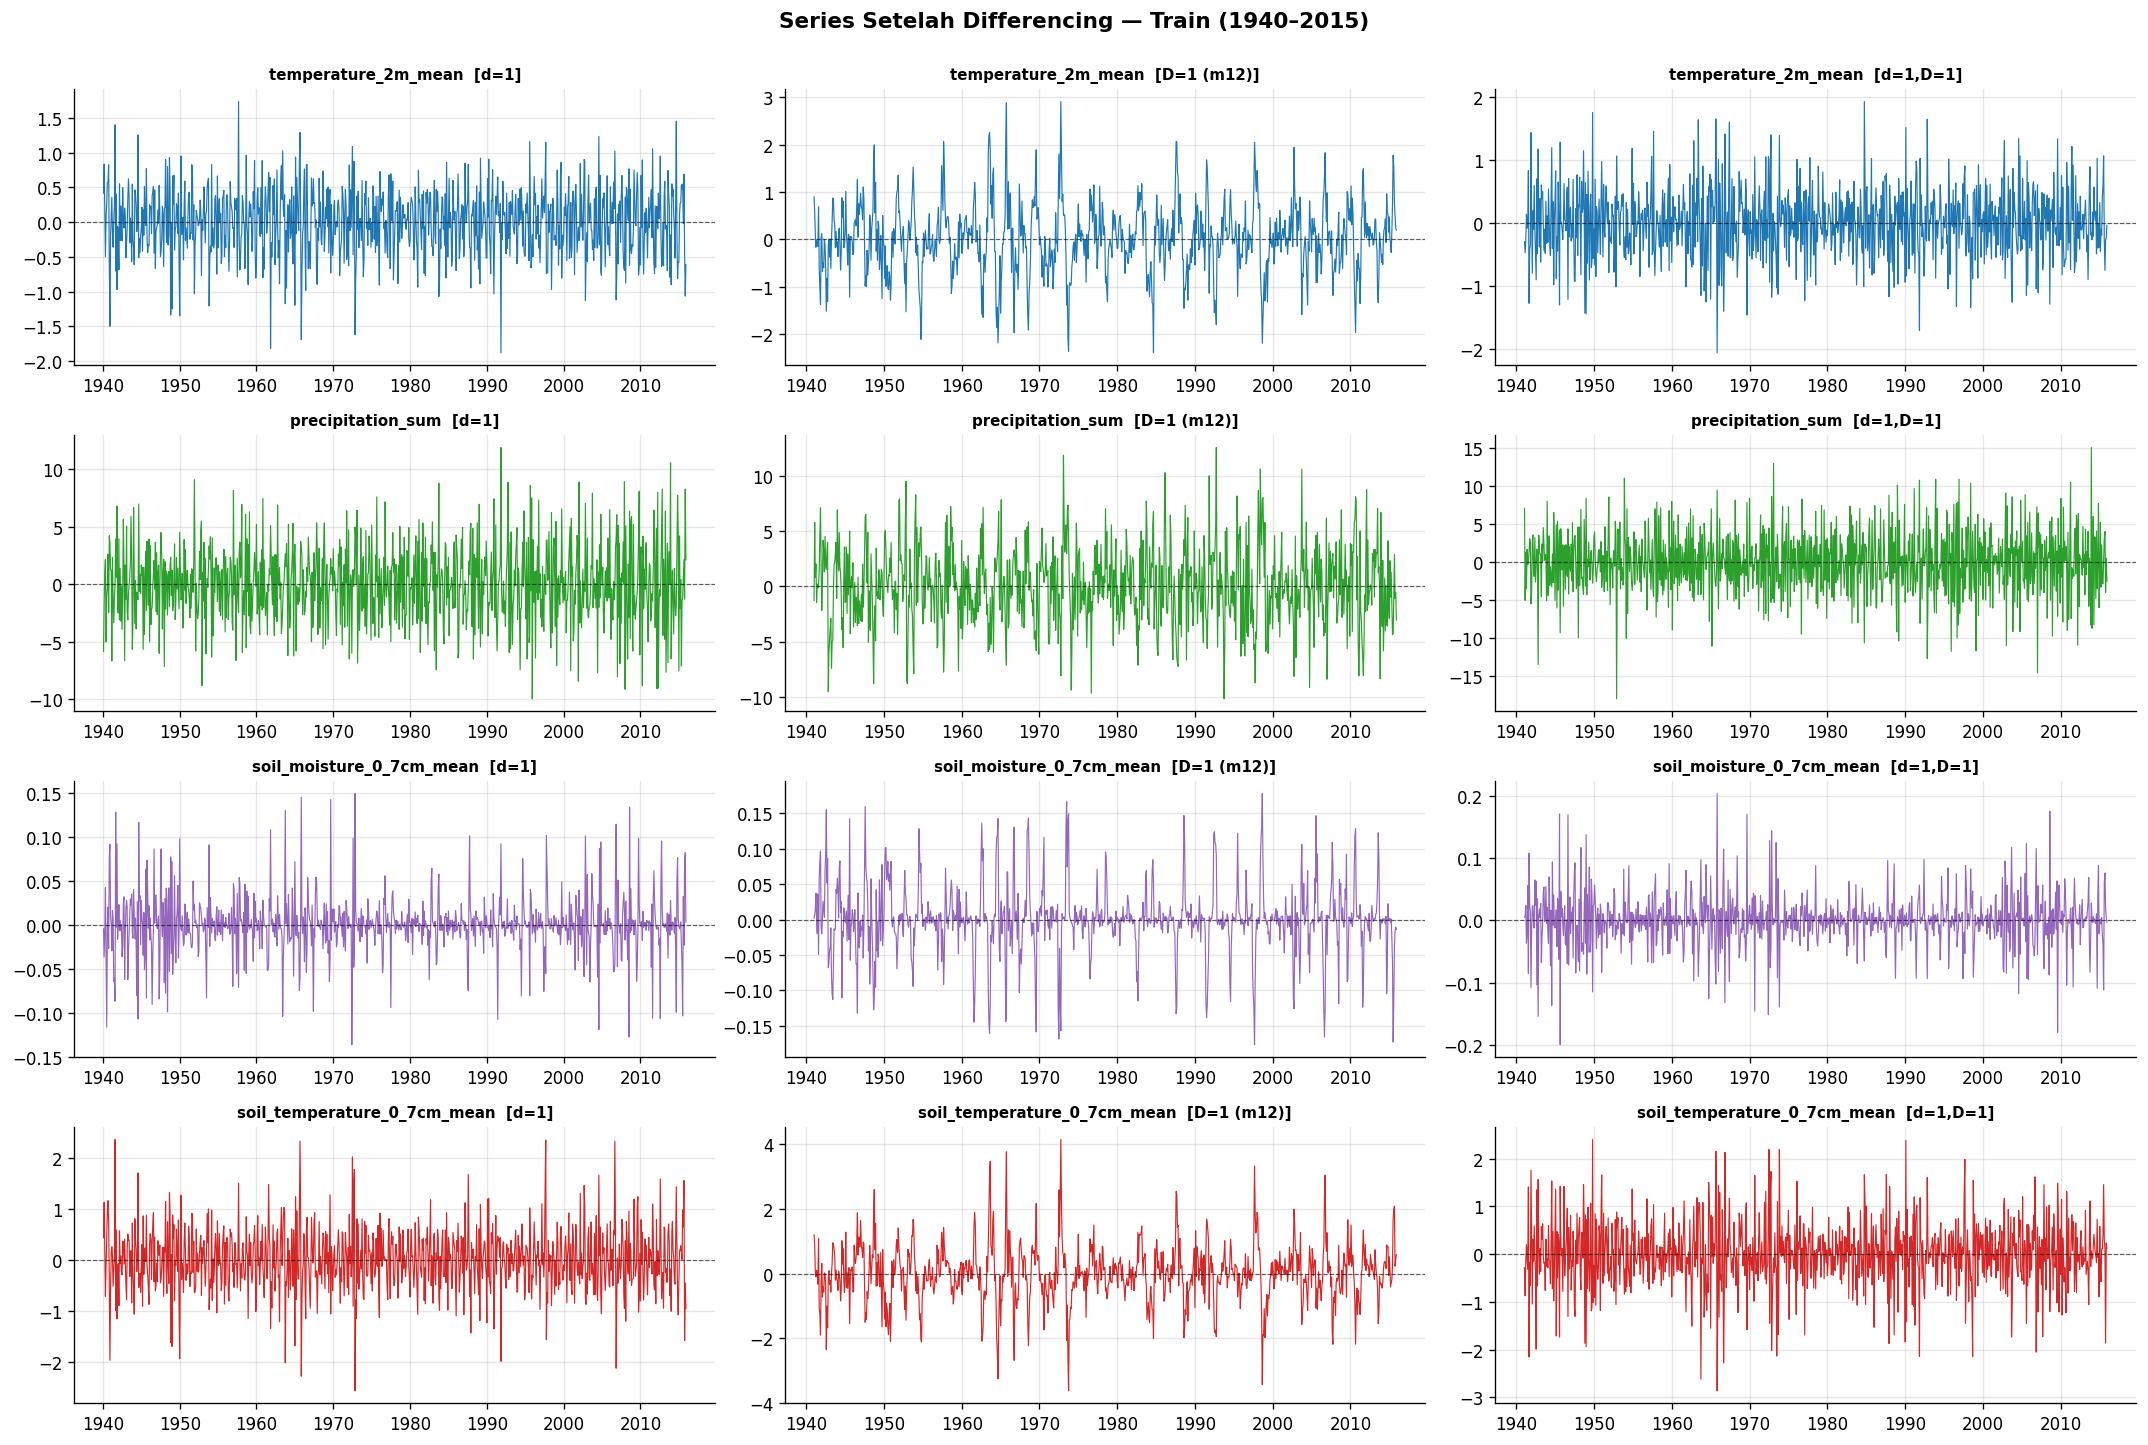

In [23]:
# Plot 3 varian differencing per target
fig, axes = plt.subplots(len(TARGETS), 3, figsize=(18, 12), sharex=False)

for i, col in enumerate(TARGETS):
    c = target_colors[col]
    for j, (label, s) in enumerate(diff_results[col].items()):
        ax = axes[i, j]
        ax.plot(s.index, s.values, color=c, lw=0.7)
        ax.axhline(0, color='black', lw=0.7, linestyle='--', alpha=0.6)
        ax.set_title(f'{col}  [{label}]', fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)

plt.suptitle('Series Setelah Differencing — Train (1940–2015)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 2.5 Exogenous (X) untuk SARIMAX

In [24]:
# Uji stasioneritas exogenous (di train)
rows_exog = [stationarity_test(train[c], name=c) for c in EXOG]
display(pd.DataFrame(rows_exog).style.set_properties(**{'text-align': 'left'}))

exog_mean = train[EXOG].mean()
exog_std  = train[EXOG].std()

exog_train = (train[EXOG] - exog_mean) / exog_std
exog_test  = (test[EXOG]  - exog_mean) / exog_std

# Korelasi exog vs target (level) pada train
print('\nKorelasi Pearson exog vs target (train):')
display(train[TARGETS + EXOG].corr().loc[EXOG, TARGETS].round(3)
        .style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.2f}'))

print(f'\nexog_train shape: {exog_train.shape}   exog_test shape: {exog_test.shape}')
exog_train.head()

/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_46100/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


,Series,ADF stat,ADF p,KPSS stat,KPSS p,Verdict
0,relative_humidity_2m_mean,-4.925000,0.000000,0.640000,0.019000,⚠️ Difference-stasioner (perlu diff)
1,sunshine_duration,-4.306000,0.000400,2.724000,0.010000,⚠️ Difference-stasioner (perlu diff)
2,precipitation_hours,-4.566000,0.000100,1.436000,0.010000,⚠️ Difference-stasioner (perlu diff)
3,cloud_cover_mean,-5.012000,0.000000,0.657000,0.017500,⚠️ Difference-stasioner (perlu diff)



Korelasi Pearson exog vs target (train):


,temperature_2m_mean,precipitation_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean
relative_humidity_2m_mean,-0.73,0.73,0.94,-0.65
sunshine_duration,0.56,-0.79,-0.62,0.49
precipitation_hours,-0.64,0.84,0.69,-0.45
cloud_cover_mean,-0.58,0.83,0.74,-0.42



exog_train shape: (912, 4)   exog_test shape: (120, 4)


,relative_humidity_2m_mean,sunshine_duration,precipitation_hours,cloud_cover_mean
time,,,,
1940-01-01,0.719151,-2.256416,1.733082,1.381509
1940-02-01,0.348440,-0.089340,0.309689,0.825406
1940-03-01,-0.069614,1.150380,-0.787120,-0.156274
1940-04-01,0.081575,0.726097,-0.037039,-0.814581
1940-05-01,0.678673,-0.931855,0.571134,0.753861


# 03 Modeling SARIMAX — Forecast Test (2016–2025)

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Order kandidat: (p,d,q)(P,D,Q,m)
ORDERS = {
    COL_TEMP_2M_MEAN:          ((1, 1, 4), (1, 1, 1, 12)),
    COL_PRECIPITATION_SUM:     ((0, 0, 1), (0, 1, 1, 12)),
    COL_SOIL_MOIST_0_7CM_MEAN: ((1, 1, 2), (1, 1, 1, 12)),
    COL_SOIL_TEMP_0_7CM_MEAN:  ((2, 1, 4), (1, 1, 1, 12)),
}

fits, forecasts, conf_ints = {}, {}, {}
metrics = []

for col, (order, sorder) in ORDERS.items():
    # Align endog ke index exog (jaga jika exog di-diff -> kehilangan baris awal)
    y_train = train[col].loc[exog_train.index]
    y_test  = test[col].loc[exog_test.index]

    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        seasonal_order=sorder,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)
    fits[col] = res

    fc   = res.get_forecast(steps=len(y_test), exog=exog_test)
    yhat = fc.predicted_mean
    ci   = fc.conf_int(alpha=0.05)
    forecasts[col] = yhat
    conf_ints[col] = ci

    rmse = np.sqrt(((y_test - yhat) ** 2).mean())
    mae  = (y_test - yhat).abs().mean()
    metrics.append({'Target': col, 'order': order, 'seasonal_order': sorder,
                    'AIC': round(res.aic, 1), 'RMSE': round(rmse, 3),
                    'MAE': round(mae, 3), 'MAPE': round((y_test - yhat).abs().div(y_test.abs()).mean() * 100, 2)})

display(pd.DataFrame(metrics).style.set_properties(**{'text-align': 'left'}))

/mnt/data/_Kuliah/Departemen/Semester 6/Data Mining/Project Akhir/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/data/_Kuliah/Departemen/Semester 6/Data Mining/Project Akhir/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/data/_Kuliah/Departemen/Semester 6/Data Mining/Project Akhir/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Target,order,seasonal_order,AIC,RMSE,MAE,MAPE
0,temperature_2m_mean,"(1, 1, 4)","(1, 1, 1, 12)",-258.900000,0.336000,0.266000,1.030000
1,precipitation_sum,"(0, 0, 1)","(0, 1, 1, 12)",3270.100000,1.670000,1.235000,24.700000
2,soil_moisture_0_7cm_mean,"(1, 1, 2)","(1, 1, 1, 12)",-5323.800000,0.047000,0.036000,9.220000
3,soil_temperature_0_7cm_mean,"(2, 1, 4)","(1, 1, 1, 12)",506.200000,0.730000,0.582000,2.110000


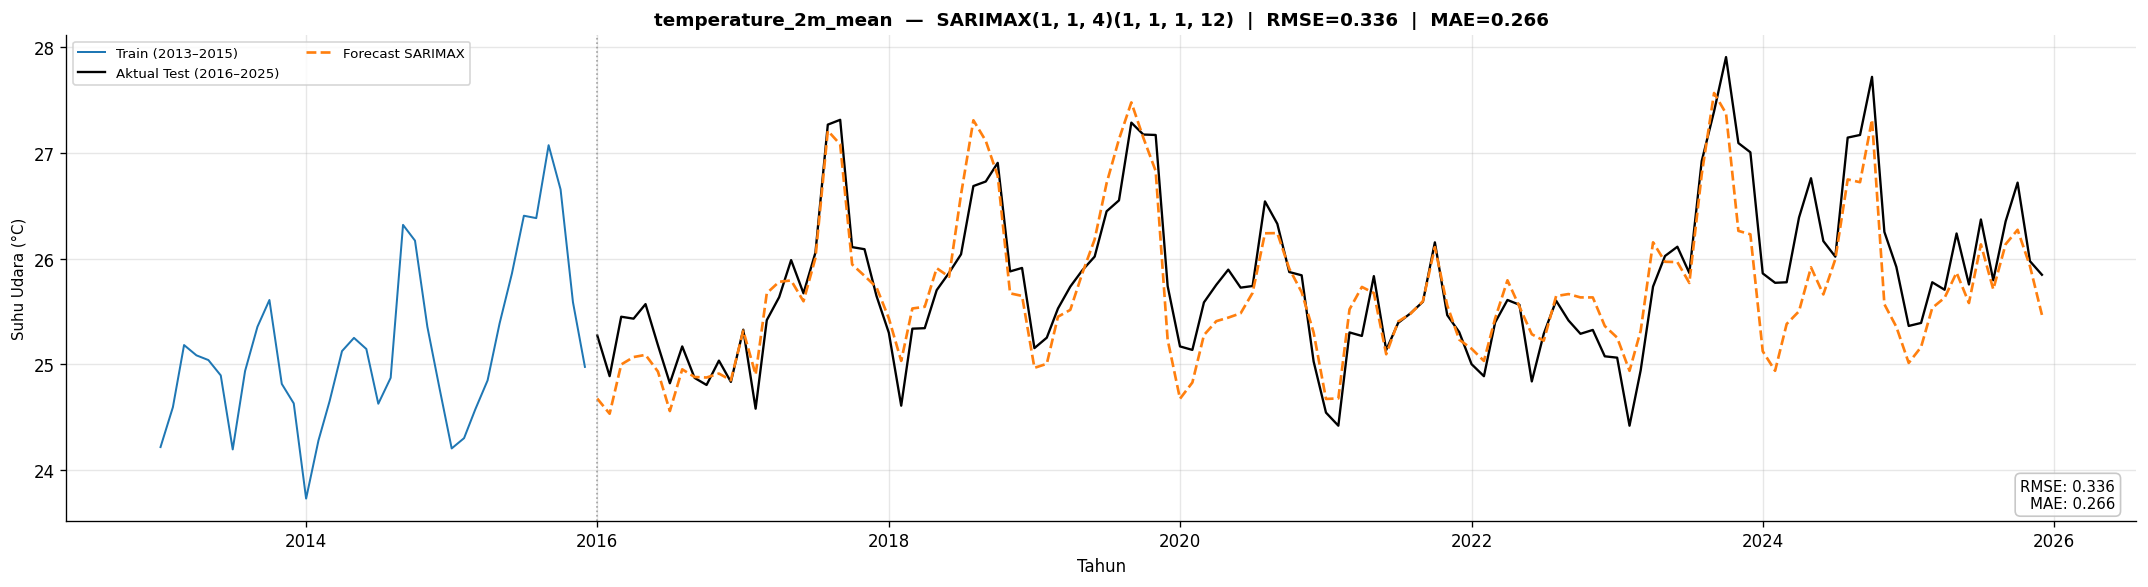

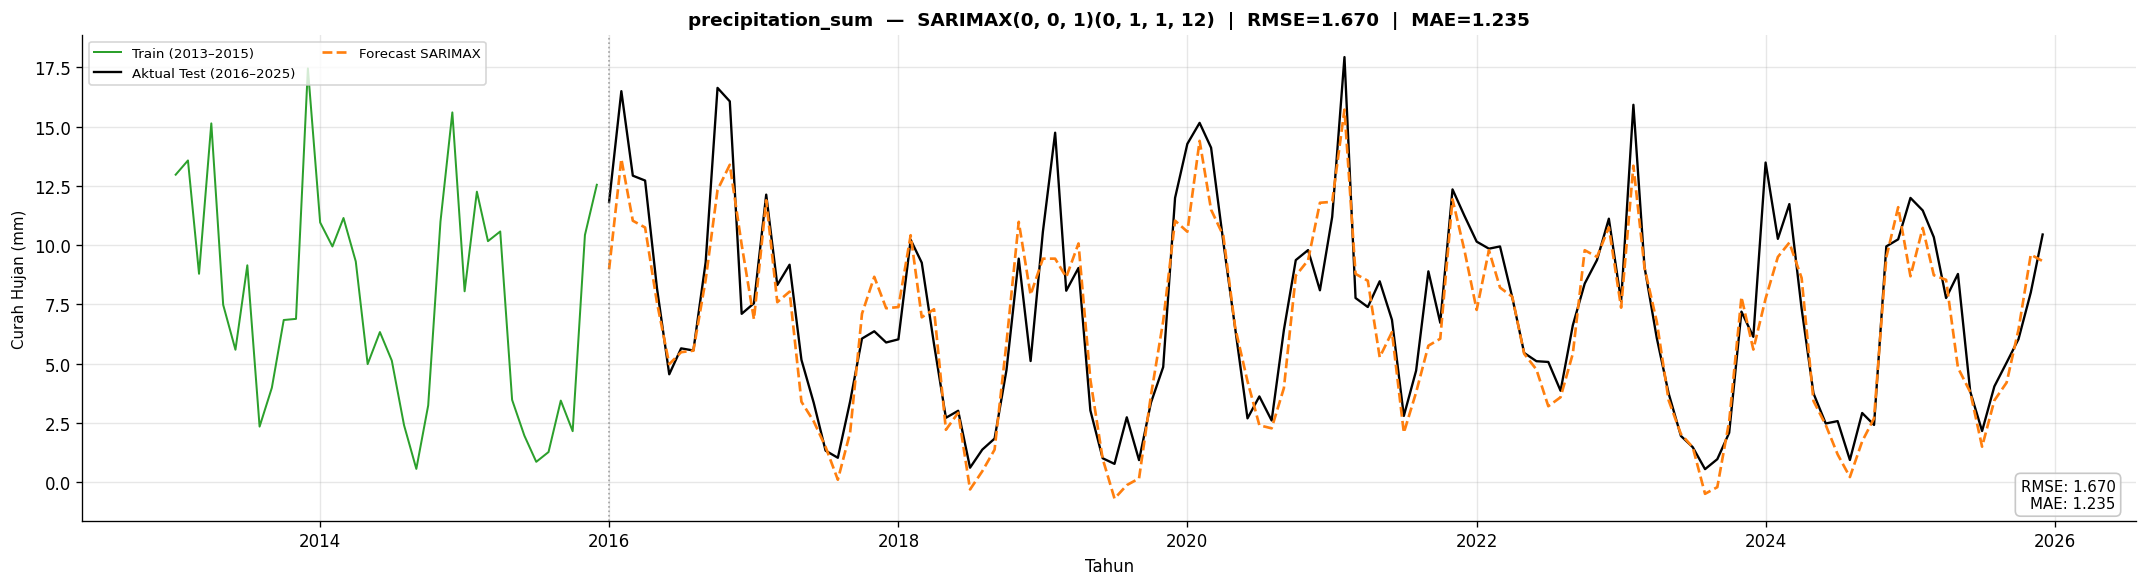

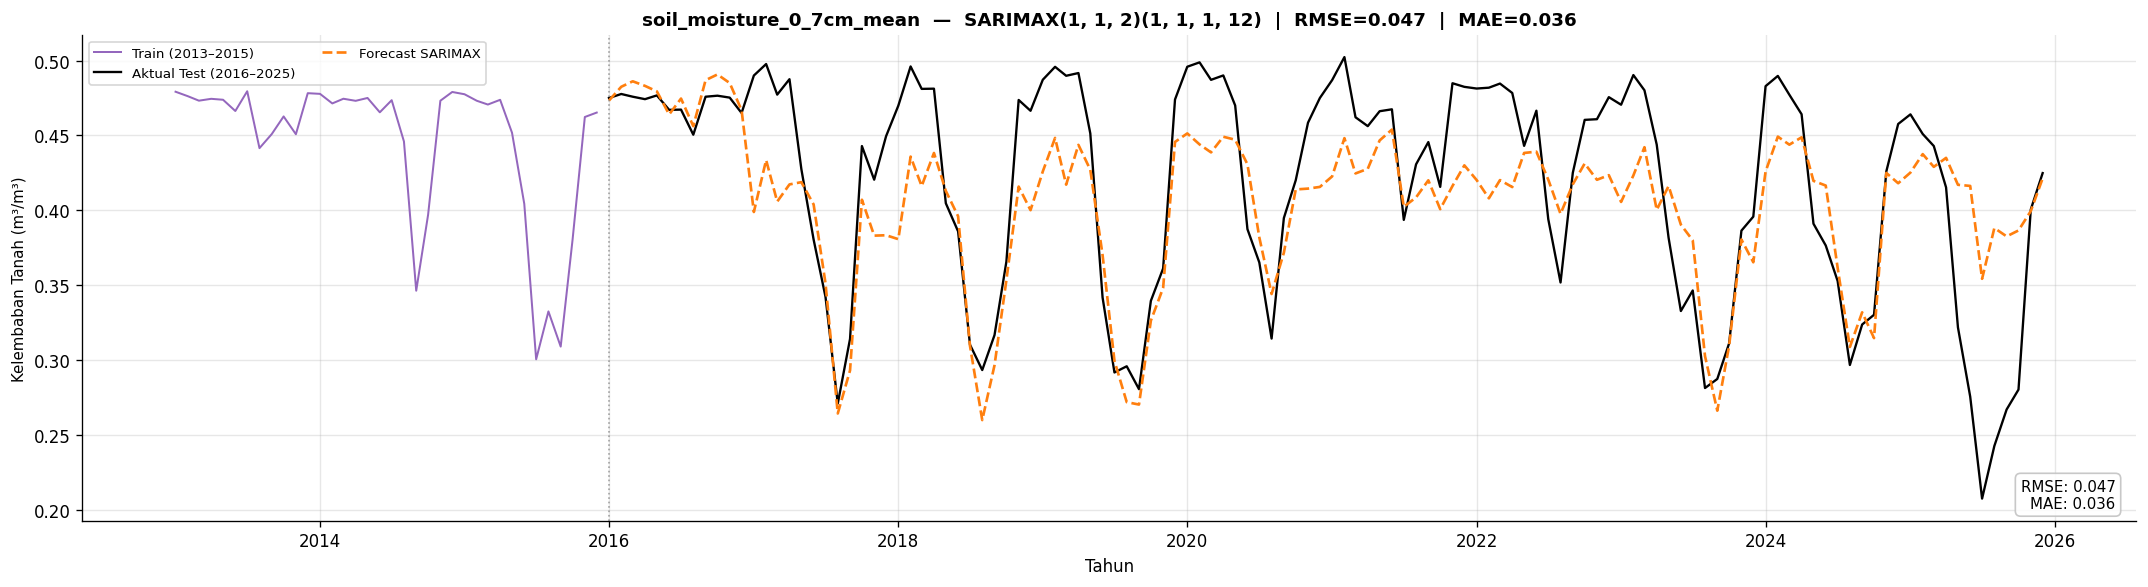

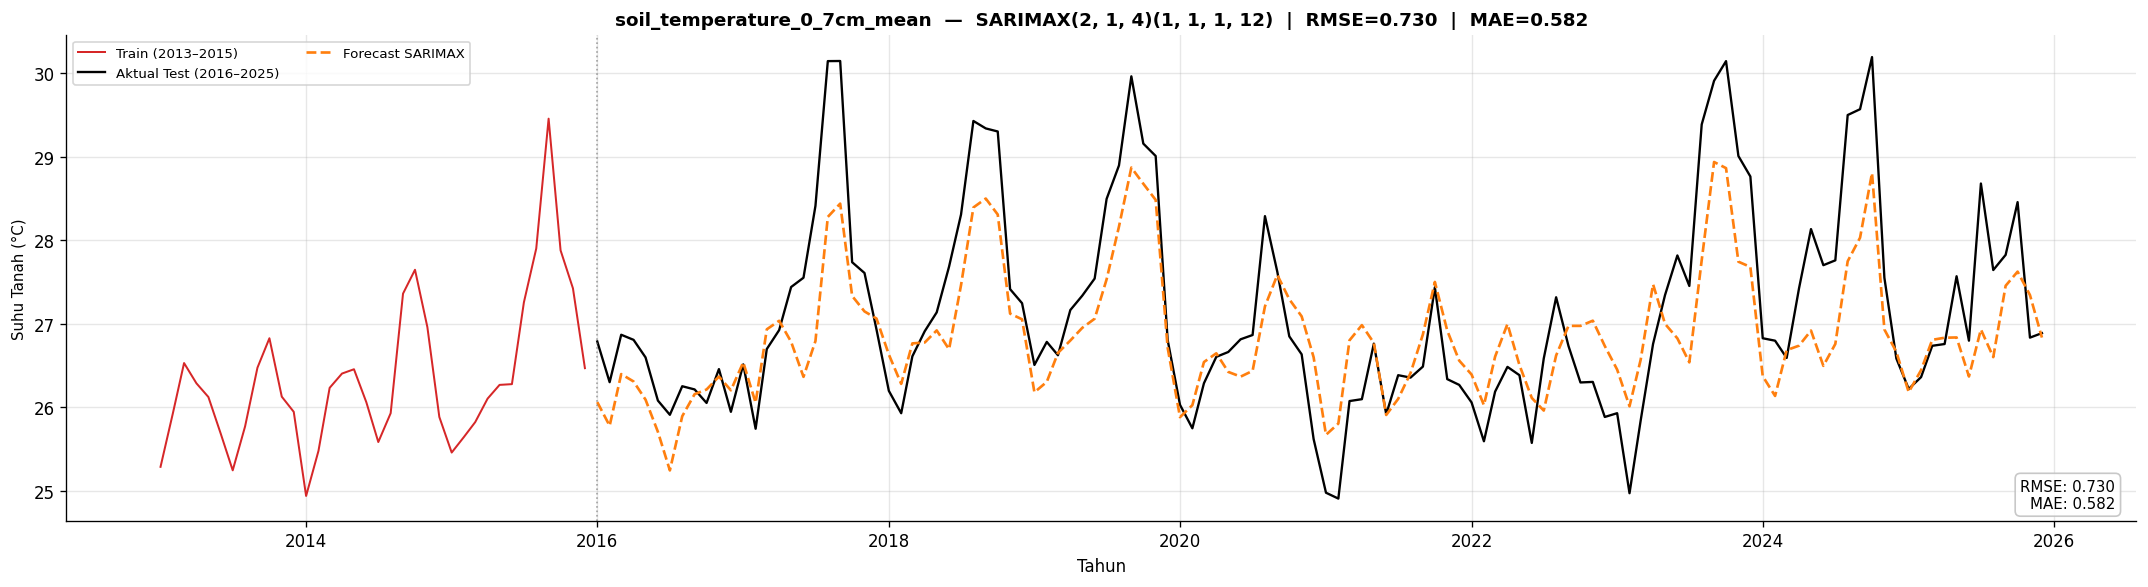

In [26]:
# Plot forecast window 2013-2025: one figure per target
PLOT_START = '2013-01-01'
plot_colors = dict(zip(TARGETS, ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']))
metrics_by_target = {m['Target']: m for m in metrics}

for col in TARGETS:
    c = plot_colors[col]
    train_win = train[col].loc[PLOT_START:]
    test_win = test[col]
    yhat = forecasts[col]
    ci = conf_ints[col]
    lower = ci.iloc[:, 0]
    upper = ci.iloc[:, 1]

    metric_row = metrics_by_target[col]
    rmse = float(metric_row['RMSE'])
    mae = float(metric_row['MAE'])

    fig, ax = plt.subplots(figsize=(18, 5))
    ax.plot(train_win.index, train_win.values, color=c, lw=1.2, label='Train (2013–2015)')
    ax.plot(test_win.index, test_win.values, color='black', lw=1.4, label='Aktual Test (2016–2025)')
    ax.plot(yhat.index, yhat.values, color='#ff7f0e', lw=1.6, linestyle='--', label='Forecast SARIMAX')
    # ax.fill_between(yhat.index, lower.values, upper.values, color='#ff7f0e', alpha=0.15, label='95% CI')
    ax.axvline(pd.Timestamp(SPLIT_DATE), color='gray', lw=1, linestyle=':', alpha=0.7)

    order, sorder = ORDERS[col]
    ax.set_title(f'{col}  —  SARIMAX{order}{sorder}  |  RMSE={rmse:.3f}  |  MAE={mae:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel(TARGET_LABELS[col], fontsize=9)
    ax.set_xlabel('Tahun')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    metrics_box = f'RMSE: {rmse:.3f}\nMAE: {mae:.3f}'
    ax.text(
        0.99,
        0.02,
        metrics_box,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        bbox={
            'boxstyle': 'round,pad=0.35',
            'facecolor': 'white',
            'alpha': 0.85,
            'edgecolor': '0.75',
        },
    )

    plt.tight_layout()
    plt.show()